<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <p style=" text-align: center; font-size: 32px;">   
   <strong> Optimal Trading Practical Assignment 4: Fillrates and Market Making </strong></p>
    <p style=" text-align: center; font-size: 25px;"><strong> Master Probabilities & Finance - Ecole Polytechnique and Sorbonne University <strong></p>
  <p style=" text-align: center; font-size: 20px;"> Joseph LECLERC, Carl-Emil JENSEN, Constantin GLEYZE - based from an original LateX of S. Laruelle </p>
</header>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Import librairies and data</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

In [1]:
# Import of all the requiered librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor
from datetime import datetime
import sys
import time
from tqdm import tqdm
from functools import reduce
from math import gcd
import bisect
from scipy.optimize import minimize 
from scipy.optimize import dual_annealing
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import numpy as np
from collections import deque
from itertools import cycle
import matplotlib.ticker as mtick
import re
pd.set_option('display.max_rows', None)

In [2]:
path = ""
canon = pd.read_hdf(path + "CANON.h5", "df")
amazon = pd.read_hdf(path + "AMAZON.h5", "df")
apple = pd.read_hdf(path + "APPLE.h5", 'df')
bouygues = pd.read_hdf(path + "BOUYGUES.h5", 'df')
lvmh = pd.read_hdf(path + "LVMH.h5", 'df')
sanofi = pd.read_hdf(path + "SANOFI.h5", 'df')
sony = pd.read_hdf(path + "SONY.h5", 'df')
total = pd.read_hdf(path + "TOTAL.h5", 'df')
google = pd.read_hdf(path + "GOOGLE.h5", 'df')
panasonic = pd.read_hdf(path + "PANASONIC.h5", 'df')

# We create geographical list for each stock, as well as a list with their names
list_US = [google, amazon, apple]
list_US_name = ['Google', 'Amazon', 'Apple']
list_FR = [total, lvmh, bouygues, sanofi]
list_FR_name = ['Total', 'LVMH', 'Bouygues', 'Sanofi']
list_JP = [sony, canon, panasonic]
list_JP_name = ['Sony', 'Canon', 'Panasonic']

list_covar_US = [[[google, amazon], [amazon, apple], [google, apple]]]
list_covar_US_name = [[['Google', 'Amazon'], ['Amazon', 'Apple'], ['Google', 'Apple']]]

list_covar_FR = [[[total, lvmh], [total, bouygues], [total, sanofi],[lvmh, bouygues], [lvmh, sanofi], [bouygues, sanofi]]]
list_covar_FR_name = [[['Total', 'LVMH'], ['Total', 'Bouygues'], ['Total', 'Sanofi'],['LVMH', 'Bouygues'], ['LVMH', 'Sanofi'], ['Bouygues', 'Sanofi']]]
list_covar_JP = [[[sony, canon], [sony, panasonic], [canon, panasonic]]]
list_covar_JP_name = [[['Sony', 'Canon'], ['Sony', 'Panasonic'], ['Canon', 'Panasonic']]]

total_list_covar = [list_covar_US[0], list_covar_FR[0], list_covar_JP[0]]
total_list_covar_name = [list_covar_US_name[0], list_covar_FR_name[0], list_covar_JP_name[0]]
total_list = list_US+list_FR+list_JP
total_list_name = list_US_name+ list_FR_name+ list_JP_name
titles = ["US market", "FR market", "JP market"]
title_US = ["US market"]
title_JP = ["FR market"]
title_FR = ["JP market"]

list_FR_US = list_FR + list_US
list_FR_US_name = list_FR_name+list_US_name

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">1.1 Passive Orders and Probability of Execution</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### 1. Probability of Execution

* Empirically determined with the data
* Compute for different limits (in ticks) and different durations (in minutes : 1, 5, 15, 30) on both side (bid and ask)
* Study the dependence of the execution probability on limit and duration

### 2. Implementation

* Use the dataset of trades on one day you choose and consider that the other limits of the LOB are for each possible prices (on the tick grid)
* Compare the posting price with the trade price to determine if the limit order is executed (bid and ask side, for 5 limits)
* Average on the whole day to estimate the execution probability depending on limit and resampling period. What happens when the duration goes to 0 ? Comment.

In [4]:
#subfunction
def get_tick (prices, decimal_precision=6) : 

    """
    Computes the minimum price increment (tick size) from a time series of prices,
    using the greatest common divisor of observed price changes.

    Parameters
    ----------
    prices: pd.Series
            Time-indexed series of traded prices.
    decimal_precision: int
                       Number of decimal digits used to scale price differences
                       into integers before applying GCD. Higher values capture finer granularity.

    Returns
    -------
    tick: float
          Estimated tick size, i.e., the smallest observed price increment.
    """
    
    deltas = prices.diff().abs().dropna() # Compute absolute price differences and drop nulls
    deltas = deltas[deltas > 0] # Remove zero differences (no price movement)

    # Scale price differences to integers
    scale = 10**decimal_precision
    scaled_deltas = (deltas * scale).round().astype(int)
    
    tick_int = reduce(gcd, scaled_deltas) # Compute GCD of scaled differences
    tick = tick_int / scale # Convert back to float tick size
    return tick

#subfunction
def get_LOB(data, number_tests, tick):

    """
    Constructs bid and ask price levels around the best available price using the tick size.

    Parameters
    ----------
    data: pd.DataFrame
          Single-period tick data containing BidPrice, AskPrice, and TradedPrice.
    number_tests: int
                  Number of levels above/below the best price to test.
    tick: float
          Minimum price increment (tick size).

    Returns
    -------
    bid_levels: np.ndarray
                Array of price levels below or equal to best bid.
    ask_levels: np.ndarray
                Array of price levels above or equal to best ask.
    """

    # Get initial bid/ask and trade price
    best_bid = data['BidPrice'].iloc[0]
    best_ask = data['AskPrice'].iloc[0]
    trade_price = data['TradedPrice'].iloc[0]

    # Adjust bid/ask relative to trade price
    best_bid = min(best_bid,trade_price)
    best_ask = max(best_ask,trade_price)
    
    # Generate tick-spaced price levels
    bid_levels = np.array([best_bid - i * tick for i in range(number_tests + 1)])
    ask_levels =  np.array([best_ask + i * tick for i in range(number_tests + 1)])
    
    return bid_levels,ask_levels

#subfunction
def check_consumption(data, prices, type):

    """
    Checks whether orders at given prices would have been executed based on trade history.

    Parameters
    ----------
    data: pd.DataFrame
          Tick-level trade data with column 'TradedPrice'.
    prices: np.ndarray
            List of price levels to test for execution.
    type: str
          'Bid' or 'Ask' side to determine execution condition.

    Returns
    -------
    results: np.ndarray
             Binary vector indicating whether each price level was consumed (executed).
    """
    
    results = []

    # For Bid side, check if any trades occurred at or below each test price
    if type == 'Bid': 
        for price in prices : 
            executed = int(np.any(data['TradedPrice'] <= price))
            results.append(executed)

    # For Ask side, check if any trades occurred at or above each test price
    elif type == 'Ask': 
        for price in prices : 
            executed = int(np.any(data['TradedPrice'] >= price))
            results.append(executed)
    return np.array(results)

#subfunction
def compute_exec_proba_LOB (name_list,data_list,start_date,end_date,period,number_tests):

    """
    Computes the average probability of execution at each LOB level across time intervals.

    Parameters
    ----------
    name_list: list
               List of asset identifiers.
    data_list: list
               List of DataFrames containing tick-level market data for each asset.
    start_date: datetime
                Start of time window for analysis.
    end_date: datetime
              End of time window for analysis.
    period: str
            Time interval used for grouping trades (e.g., '1Min').
    number_tests: int
                  Number of levels to test around the best bid/ask.

    Returns
    -------
    final_results: pd.DataFrame
                   Table of execution probabilities at each tick level, for each asset.
    """
    
    tick_dict = {}
    data_dict =  {}
    final_results =[]

    # Preprocess and store tick size and filtered data per asset
    for name, data in zip(name_list, data_list): 
        tick_dict[name] = get_tick(data['TradedPrice'])
        data.index = pd.to_datetime(data.index) # Ensure datetime index
        data = data[(data.index >= start_date) & (data.index < end_date)]
        data_dict[name] = data        

    # For each asset, compute execution statistics per time group
    for name, data in data_dict.items():
        grouped_prices =  data.groupby(pd.Grouper(freq=period))
        count_bid_exec = np.zeros(number_tests+1)
        count_ask_exec =  np.zeros(number_tests+1)
        total_period = 0
        
        for interval, group in grouped_prices: 
            if group.empty:
                total_period+=1
                continue
                
            # Construct LOB and evaluate executions
            bid_levels,ask_levels = get_LOB(group, number_tests, tick_dict[name])
            bid_exec = check_consumption(group, bid_levels, 'Bid')
            ask_exec = check_consumption(group, ask_levels, 'Ask')

            # Accumulate counts
            count_bid_exec+=bid_exec
            count_ask_exec+=ask_exec
            total_period+=1

        # Normalize counts to get execution probabilities
        count_bid_exec/=total_period
        count_ask_exec/=total_period

        # Format result row
        row = {'Security': name, 'Tick value':tick_dict[name]}
        for i, prob in zip(range(number_tests, -1, -1), reversed(count_bid_exec)):
            row[f'Best Bid -{i} ticks'] = f"{prob*100:.3f}%"
        for i, prob in enumerate(count_ask_exec):
            row[f'Best Ask +{i} ticks'] = f"{prob*100:.3f}%"

        final_results.append(row)
    final_results = pd.DataFrame(final_results)
    final_results.name = f"Execution probability per tick every {period}"
    print(f"\n--- {final_results.name} ---\n")
    return final_results

def plot_results(results,time, title):
    
    """
    Plot the tick-level metric (e.g., fillrate or inventory) per asset.

    Parameters
    ----------
    results : pd.DataFrame
              Table with metrics per tick distance and asset.
    time : str
           Label for the temporal resolution used in simulation (e.g. '30Min').
    title : str
            Title to apply on each subplot.
    """
    
    num_plots = len(results) # One subplot per asset
    max_cols = 4 # Layout: max 4 plots per row
    n_rows = int(np.ceil(num_plots / max_cols)) # Ensure enough rows to display all plots with max 4 per row

    fig, axes = plt.subplots(n_rows, max_cols, figsize=(5 * max_cols, 5 * n_rows))
    axes = axes.flatten() # Flatten the 2D array of axes for easier indexing

    for i in range(num_plots):
        v = (results.iloc[i, 2:].apply(lambda x: float(x[:-1]) / 100)).values # Convert percent strings to floats

        axes[i].plot(range(6), v[:6], color='blue', marker='o', label="First 6 values")
        axes[i].plot(range(6, 12), v[6:], color='red', marker='o', label="Next 6 values (reversed)")
        axes[i].set_title(f"{title} for {results.iloc[i, 0]} (Tick: {results.iloc[i, 1]}) every {time}")
        axes[i].set_xlabel("Ticks")
        axes[i].set_ylabel(f"{title}")
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # Format Y axis as percent
        axes[i].legend()

    # Remove unused subplots in the last row
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def build_and_display_asset_tables(dataframes, list_FR_US, results, title):

    """
    Builds and displays one table per asset, showing execution stats across temporal resolutions,
    arranged 4 tables per row.

    Parameters
    ----------
    dataframes: list
                List of tuples (DataFrame, label) for each time resolution.
    list_FR_US: list
                Columns in 'results' that identify asset names.
    results: pd.DataFrame
             Source table containing all tick-level data summaries.
    title : str
            Title to apply on DataFrame.
    """
    
    time_values = {} # Stores per-asset, per-tick-level temporal data
    temporalities = [label for _, label in dataframes] # Column headers for time buckets

    all_asset_dfs = [] # Container for each asset's formatted DataFrame
    seen_assets = set() # Avoid duplicates and invalid asset labels

    for p in range(len(list_FR_US)):
        for i in range(len(results)):
            asset_name = results.iloc[i, p]
            if not isinstance(asset_name, str) or not asset_name.isalpha():
                continue   # Avoid rows with non-asset labels like percentages
            if asset_name in seen_assets:
                continue # Skip already processed assets

            ticks_data = {} # Temporarily store tick execution data for one asset
            for j in range(2, len(results.columns)):
                tick_name = results.columns[j]
                tick_series = [df.iloc[i, j] for df, _ in dataframes] # Collect values for each temporal resolution
                ticks_data[tick_name] = tick_series

            if ticks_data:
                df_asset = pd.DataFrame.from_dict(ticks_data, orient="index", columns=temporalities)
                df_asset.index.name = "Tick Level"
                df_asset.columns.name = title + " " + asset_name # Use asset name as table title
                all_asset_dfs.append(df_asset)
                seen_assets.add(asset_name)

    # Render asset tables grouped by 3 for horizontal display
    n = 3
    for i in range(0, len(all_asset_dfs), n):
        html_row = "".join(df.style.set_table_attributes("style='display:inline-block; margin-right:20px; vertical-align:top'").to_html() for df in all_asset_dfs[i:i + n])
        display(HTML(f"<div style='display:flex; gap:20px; justify-content:flex-start'>{html_row}</div>"))
    return time_values  
    
def plot_all_assets_execution_curves(time_values, dataframes, title):
    """
    Plots all tick levels (12 curves) per asset in one plot per asset, 3 plots per row.

    Parameters
    ----------
    time_values : dict
        Dict with structure: asset -> tick level -> pd.Series (across temporalities).
    dataframes : list
        List of tuples (DataFrame, label) used to extract time axis from the labels.
    title : str
            Title to apply on each subplot.
    """

    # Converts time labels like '30 Minutes', '5 Seconds' to numeric values in minutes
    def parse_label(label):
        label = label.lower()
        if 'hour' in label:
            return float(re.search(r"\d+", label).group()) * 60
        elif 'min' in label:
            return float(re.search(r"\d+", label).group())
        elif 'sec' in label or 's' in label:
            return float(re.search(r"\d+", label).group()) / 60
        return 0

    # Extract time axis labels from dataframe metadata
    temporal_labels = [label for _, label in dataframes]  # E.g., '30 Minutes', '5 Seconds', etc.
    temporal_axis = np.array([parse_label(label) for label in temporal_labels])  # Convert to float minutes

    # Filter out keys that are not valid asset names (e.g., numeric strings or those containing '%')
    assets = [a for a in time_values.keys() if isinstance(a, str) and '%' not in a and not re.match(r"^\d+(\.\d+)?$", a)]
    n_assets = len(assets)

    # Layout config: 3 plots per row
    ncols = 3
    nrows = (n_assets + ncols - 1) // ncols

    # Subplot grid (do NOT share x to allow full control)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    # Plot each asset
    for idx, asset in enumerate(assets):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        color_cycle = cycle(plt.colormaps['tab20'].colors)

        for tick, series in time_values[asset].items():
            y_val = pd.Series(series).apply(lambda x: float(x[:-1]) / 100).values
            ax.plot(
                temporal_axis, y_val,
                marker='o', label=tick,
                color=next(color_cycle)
            )

        ax.set_title(asset)
        ax.set_xlabel("Time (minutes)")
        ax.set_ylabel(f"{title}")
        ax.set_xticks(temporal_axis)  # Place ticks correctly
        ax.set_xticklabels(temporal_labels, rotation=45, ha='right')  # Use original time labels
        ax.tick_params(axis='x', labelsize=8)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # Format Y axis as percent
        ax.grid(True)
        ax.legend(fontsize='small')

    # Remove unused subplots
    total_axes = nrows * ncols
    for idx in range(n_assets, total_axes):
        fig.delaxes(axes.flatten()[idx])

    plt.tight_layout()
    plt.show()

# Exemple d'appel:
# plot_all_assets_execution_curves(time_values, dataframes)


In [5]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8+24*4, minutes=30)

list_FR_US = list_FR + list_US
list_FR_US_name = list_FR_name+list_US_name
period = "60s"
number_tests = 5

### Exploring for each time horizon the distribution of execution probability of limit orders for a full week:

### 30 Minutes to fill:

In [224]:
results_30 = compute_exec_proba_LOB (list_FR_US_name,list_FR_US,start_date,end_date,"30min",5)
results_30


--- Execution probability per tick every 30min ---



,Security,Tick value,Best Bid -5 ticks,Best Bid -4 ticks,Best Bid -3 ticks,Best Bid -2 ticks,Best Bid -1 ticks,Best Bid -0 ticks,Best Ask +0 ticks,Best Ask +1 ticks,Best Ask +2 ticks,Best Ask +3 ticks,Best Ask +4 ticks,Best Ask +5 ticks
0,Total,0.005,29.665%,30.622%,33.971%,35.407%,36.364%,39.713%,38.756%,37.799%,36.364%,35.407%,32.057%,30.622%
1,LVMH,0.010,33.493%,33.493%,33.493%,33.493%,33.493%,39.234%,38.278%,30.144%,30.144%,30.144%,30.144%,30.144%
2,Bouygues,0.005,27.751%,28.230%,30.144%,33.014%,33.971%,37.799%,38.756%,35.885%,34.928%,32.057%,27.751%,26.794%
3,Sanofi,0.005,29.187%,30.144%,31.100%,33.493%,33.493%,37.799%,39.234%,38.278%,37.321%,35.407%,32.057%,32.057%
4,Google,0.005,25.854%,26.829%,26.829%,27.317%,27.317%,27.805%,29.268%,29.268%,29.268%,29.268%,29.268%,29.268%
5,Amazon,0.005,27.805%,28.293%,28.293%,29.268%,29.268%,29.756%,30.244%,29.268%,29.268%,29.268%,28.780%,28.780%
6,Apple,0.005,28.293%,28.780%,28.780%,29.268%,29.268%,30.244%,30.244%,28.780%,28.780%,28.780%,28.780%,28.780%


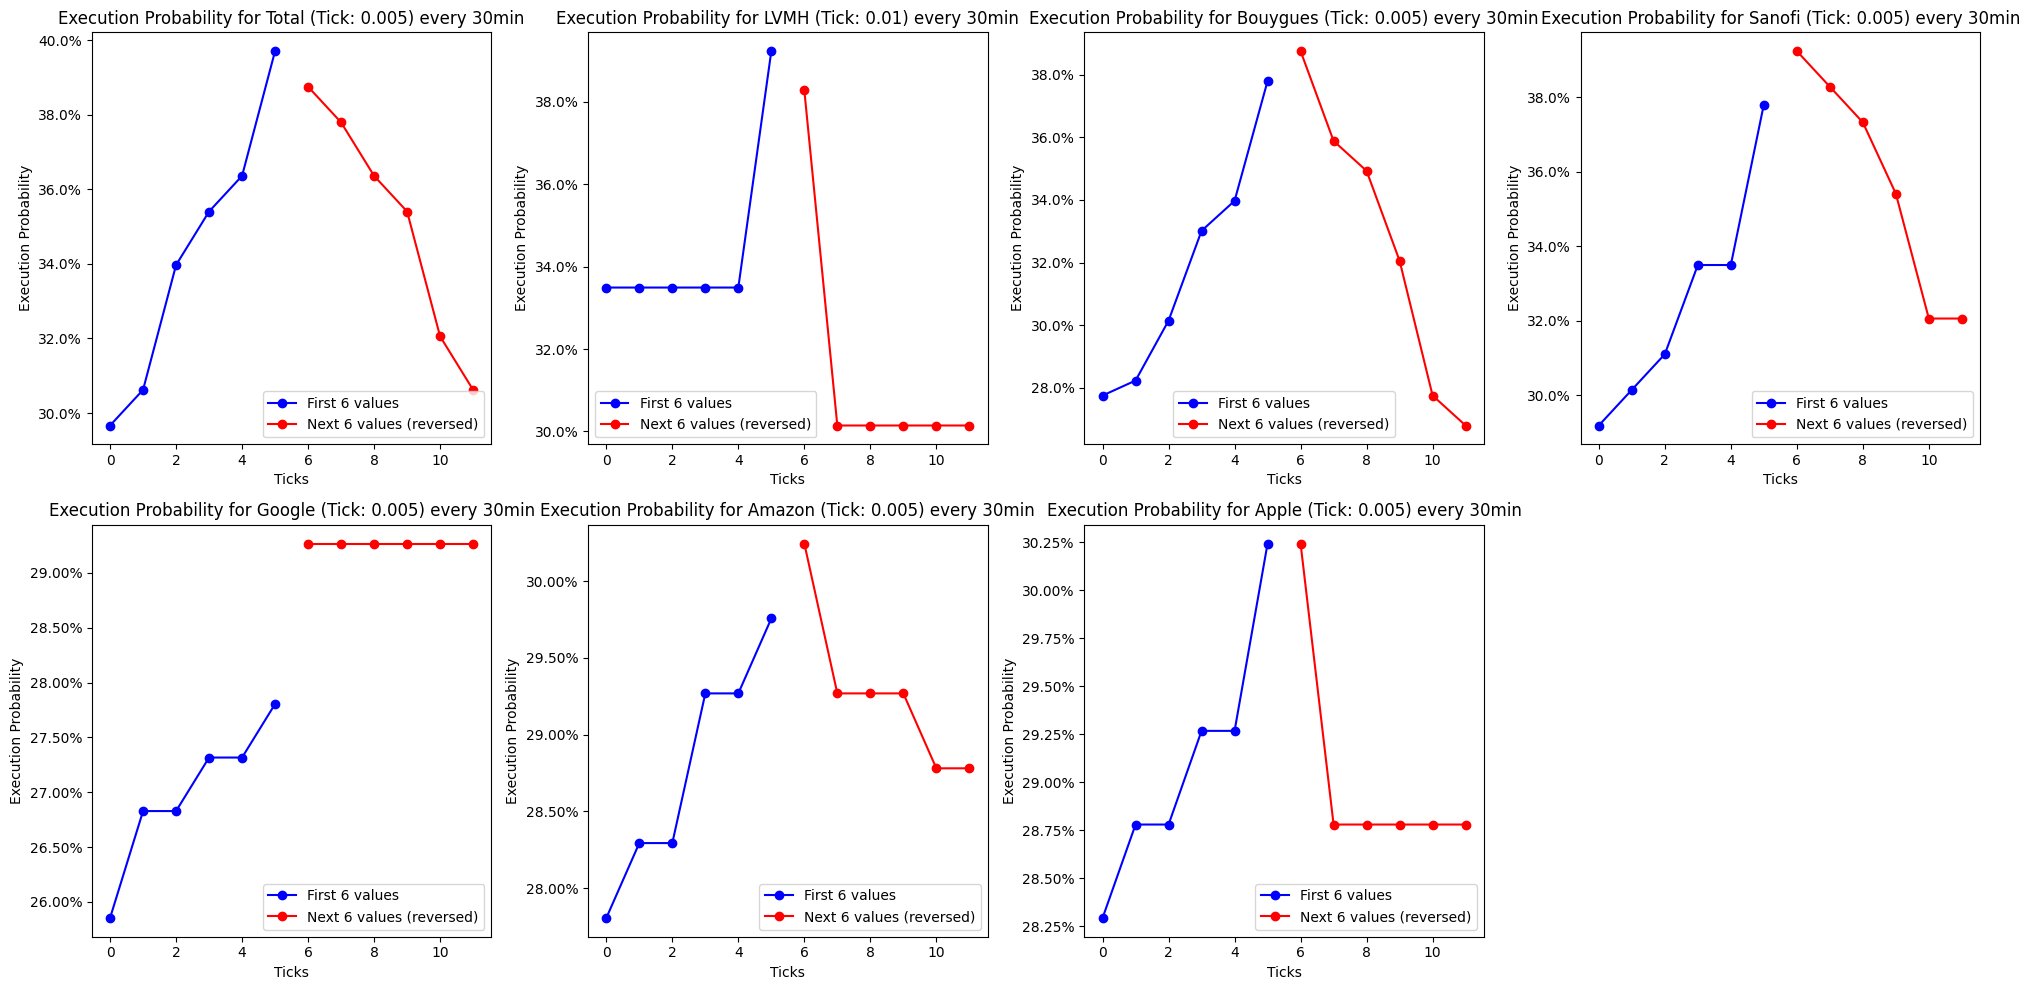

In [222]:
plot_results(results_30,"30min", "Execution Probability")

In [156]:
results_15 = compute_exec_proba_LOB (list_FR_US_name,list_FR_US,start_date,end_date,"15min",5)
results_15


--- Execution probability per tick every 15min ---



,Security,Tick value,Best Bid -5 ticks,Best Bid -4 ticks,Best Bid -3 ticks,Best Bid -2 ticks,Best Bid -1 ticks,Best Bid -0 ticks,Best Ask +0 ticks,Best Ask +1 ticks,Best Ask +2 ticks,Best Ask +3 ticks,Best Ask +4 ticks,Best Ask +5 ticks
0,Total,0.005,52.941%,52.941%,70.588%,76.471%,79.412%,91.176%,91.176%,82.353%,76.471%,73.529%,61.765%,58.824%
1,LVMH,0.010,76.471%,76.471%,76.471%,76.471%,76.471%,94.118%,94.118%,64.706%,64.706%,64.706%,64.706%,64.706%
2,Bouygues,0.005,38.235%,38.235%,47.059%,55.882%,64.706%,94.118%,88.235%,79.412%,76.471%,67.647%,58.824%,52.941%
3,Sanofi,0.005,50.000%,50.000%,58.824%,70.588%,73.529%,82.353%,94.118%,85.294%,82.353%,73.529%,70.588%,67.647%
4,Google,0.005,84.615%,84.615%,84.615%,84.615%,84.615%,84.615%,96.154%,96.154%,96.154%,96.154%,96.154%,96.154%
5,Amazon,0.005,80.769%,84.615%,84.615%,92.308%,92.308%,92.308%,88.462%,84.615%,84.615%,84.615%,84.615%,84.615%
6,Apple,0.005,88.462%,88.462%,88.462%,88.462%,88.462%,88.462%,100.000%,96.154%,96.154%,96.154%,96.154%,96.154%


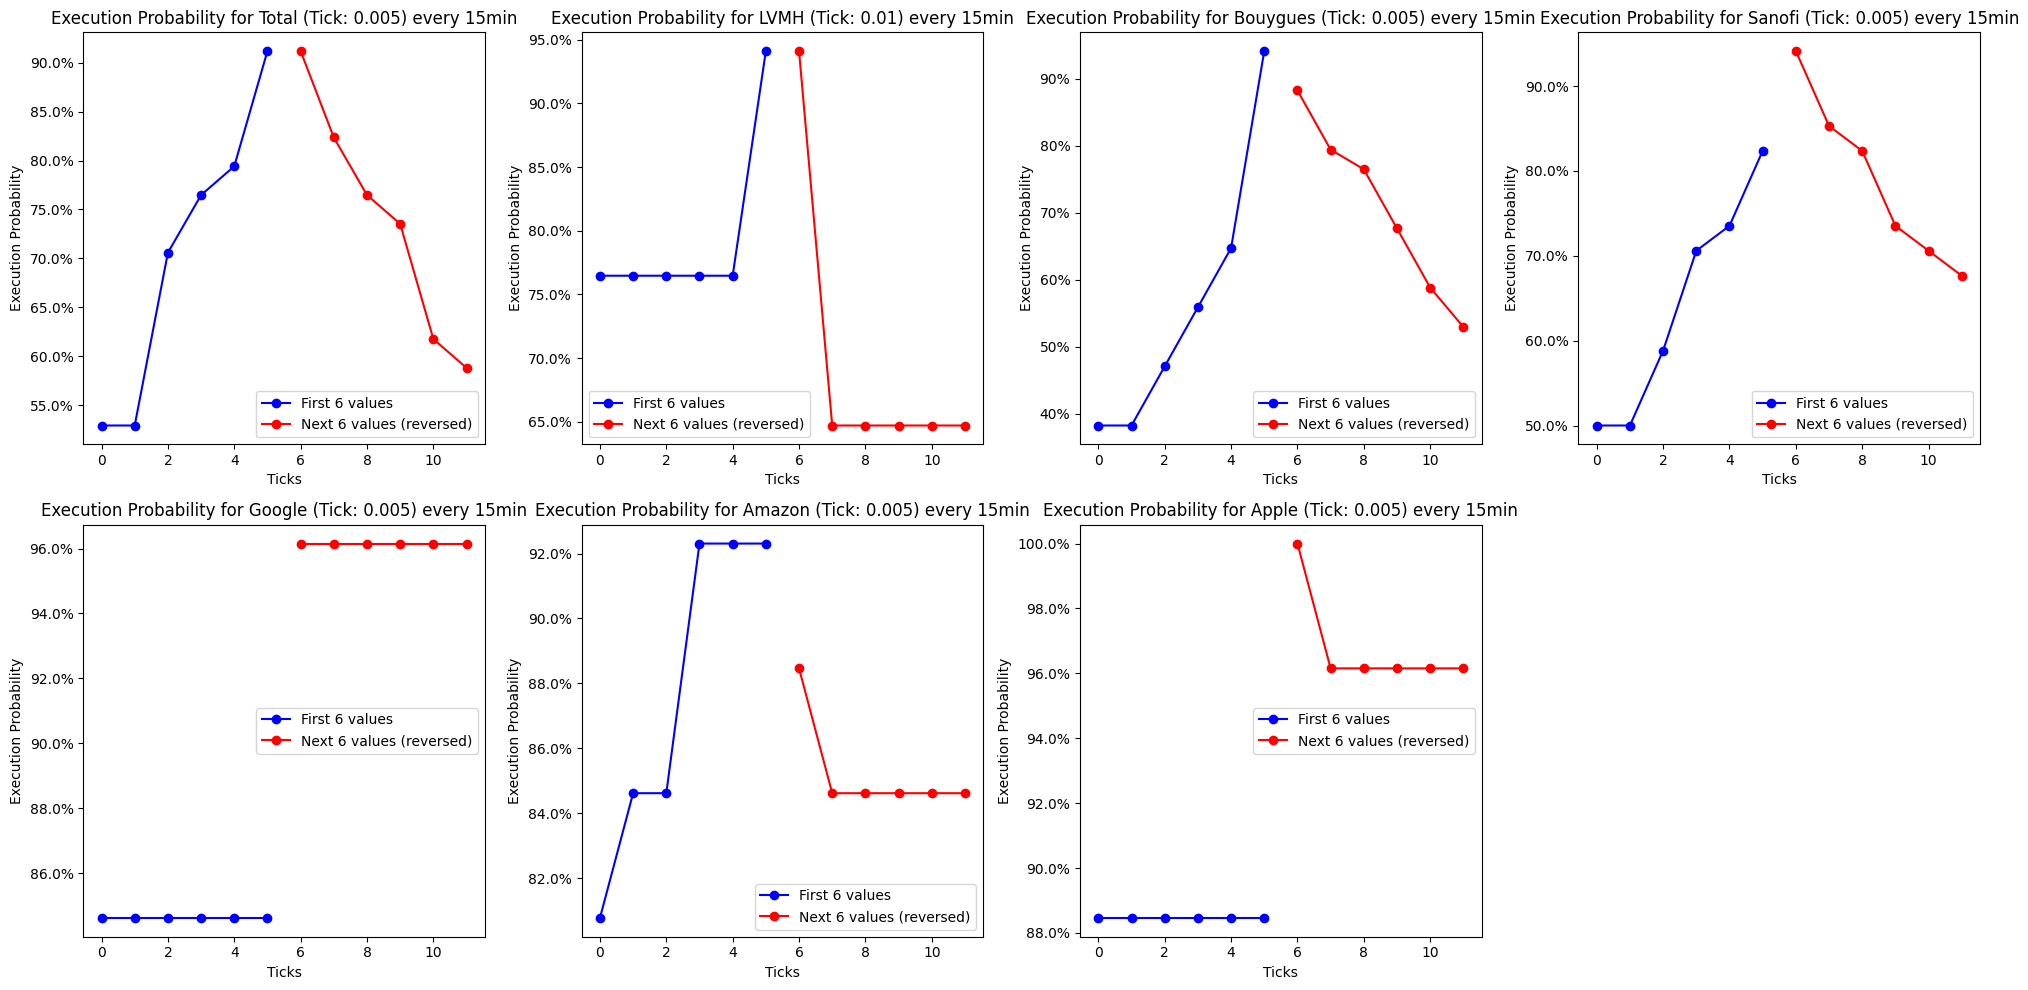

In [157]:
plot_results(results_15,"15min","Execution Probability")

### 5 Minutes to fill:

In [158]:
results_5m = compute_exec_proba_LOB (list_FR_US_name,list_FR_US,start_date,end_date,"5min",5)
results_5m


--- Execution probability per tick every 5min ---



,Security,Tick value,Best Bid -5 ticks,Best Bid -4 ticks,Best Bid -3 ticks,Best Bid -2 ticks,Best Bid -1 ticks,Best Bid -0 ticks,Best Ask +0 ticks,Best Ask +1 ticks,Best Ask +2 ticks,Best Ask +3 ticks,Best Ask +4 ticks,Best Ask +5 ticks
0,Total,0.005,39.216%,41.176%,54.902%,62.745%,69.608%,86.275%,91.176%,68.627%,62.745%,50.980%,41.176%,37.255%
1,LVMH,0.010,52.941%,52.941%,52.941%,52.941%,52.941%,86.275%,88.235%,50.000%,50.000%,50.000%,50.000%,50.000%
2,Bouygues,0.005,14.706%,19.608%,29.412%,37.255%,47.059%,84.314%,73.529%,54.902%,50.000%,37.255%,27.451%,25.490%
3,Sanofi,0.005,31.373%,32.353%,43.137%,53.922%,59.804%,76.471%,88.235%,68.627%,61.765%,54.902%,47.059%,43.137%
4,Google,0.005,61.538%,61.538%,61.538%,61.538%,61.538%,65.385%,83.333%,78.205%,78.205%,75.641%,75.641%,74.359%
5,Amazon,0.005,71.795%,75.641%,76.923%,82.051%,82.051%,84.615%,84.615%,76.923%,76.923%,73.077%,71.795%,70.513%
6,Apple,0.005,75.641%,79.487%,79.487%,82.051%,82.051%,85.897%,93.590%,87.179%,87.179%,76.923%,76.923%,74.359%


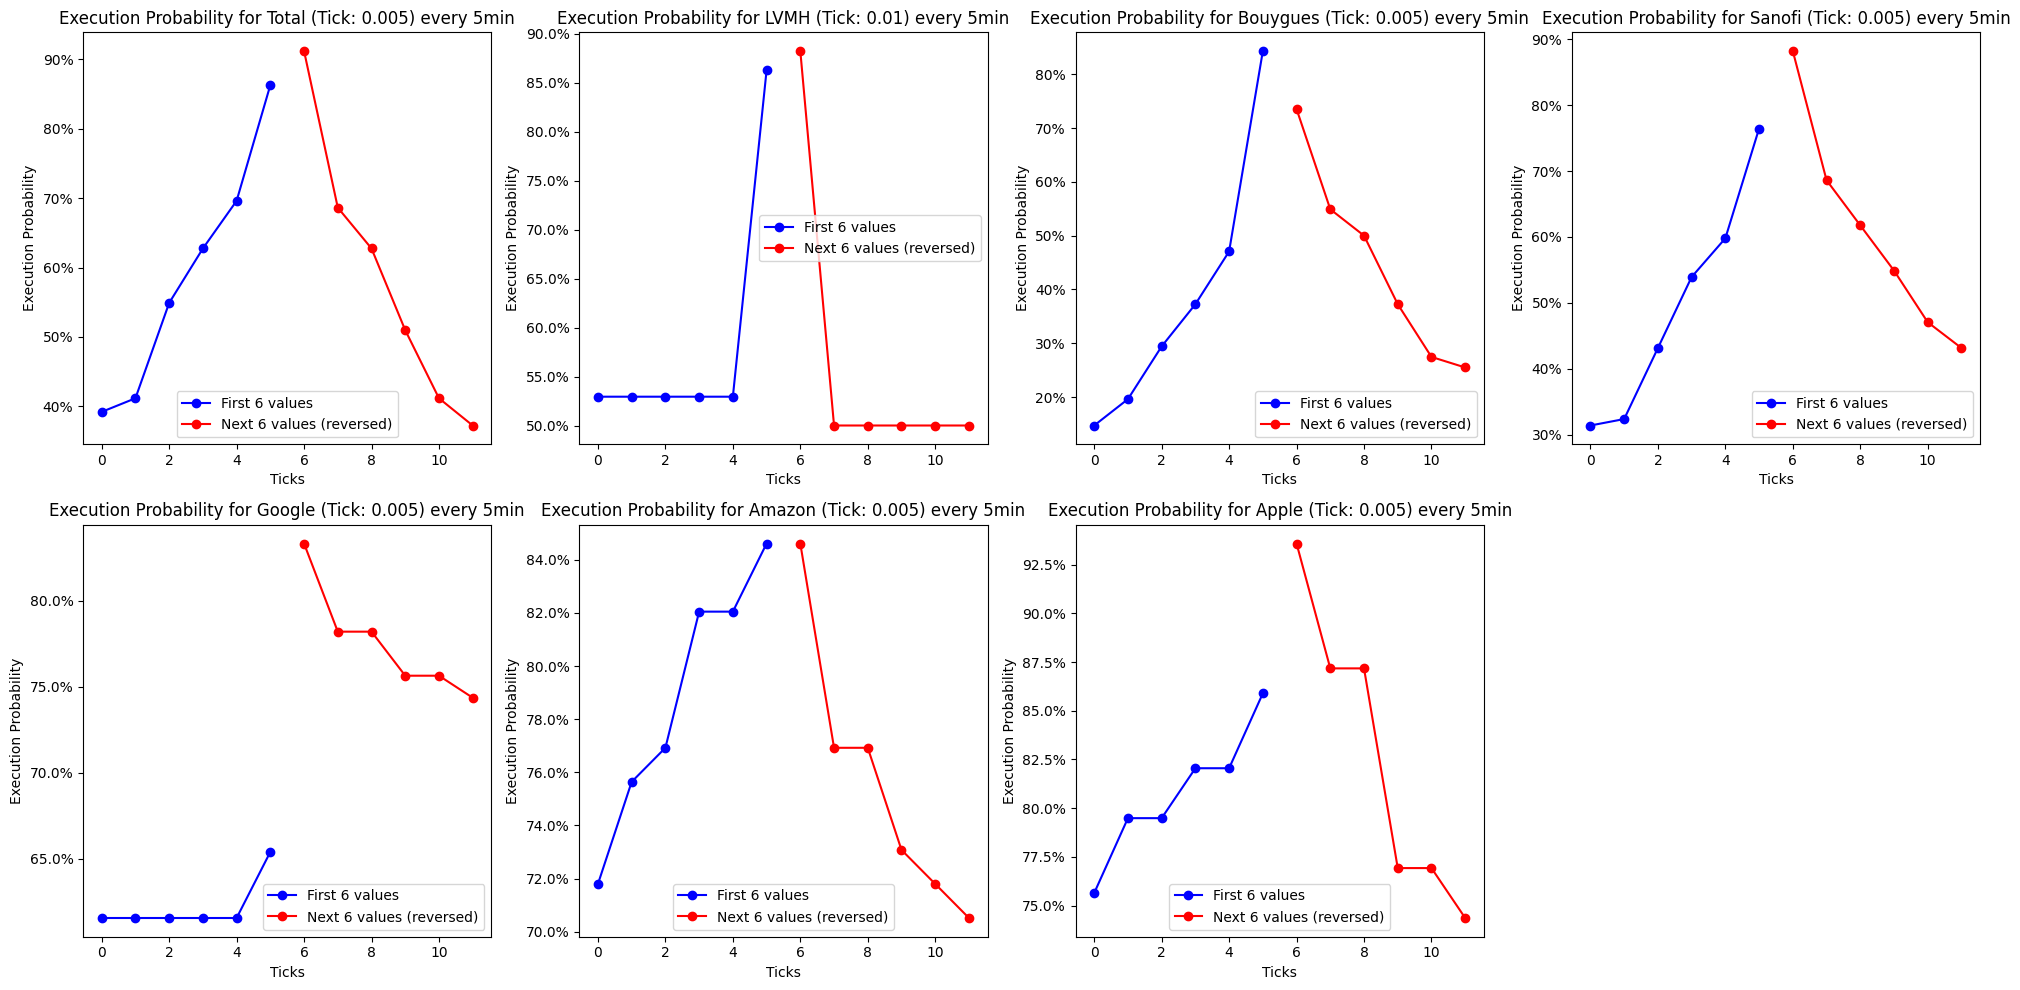

In [159]:
plot_results(results_5m,"5min","Execution Probability")

### 1 Minute to fill:

In [160]:
results_1m = compute_exec_proba_LOB (list_FR_US_name,list_FR_US,start_date,end_date,"1min",5)
results_1m


--- Execution probability per tick every 1min ---



,Security,Tick value,Best Bid -5 ticks,Best Bid -4 ticks,Best Bid -3 ticks,Best Bid -2 ticks,Best Bid -1 ticks,Best Bid -0 ticks,Best Ask +0 ticks,Best Ask +1 ticks,Best Ask +2 ticks,Best Ask +3 ticks,Best Ask +4 ticks,Best Ask +5 ticks
0,Total,0.005,10.000%,12.157%,18.431%,28.039%,36.275%,71.961%,76.275%,37.647%,28.824%,20.000%,11.569%,10.000%
1,LVMH,0.010,14.902%,14.902%,14.902%,14.902%,14.902%,50.000%,52.157%,13.529%,13.529%,13.529%,13.529%,13.529%
2,Bouygues,0.005,1.373%,3.529%,7.647%,10.980%,15.686%,57.059%,49.608%,19.216%,13.333%,7.451%,4.118%,3.725%
3,Sanofi,0.005,7.843%,9.216%,14.902%,22.745%,26.078%,60.588%,62.745%,31.176%,26.471%,18.039%,11.961%,10.000%
4,Google,0.005,30.256%,32.308%,32.308%,33.846%,33.846%,42.564%,49.744%,38.462%,38.462%,35.641%,35.641%,33.846%
5,Amazon,0.005,46.154%,48.718%,52.564%,57.179%,57.179%,67.692%,65.128%,55.128%,55.128%,47.949%,45.385%,41.538%
6,Apple,0.005,50.000%,58.205%,58.205%,62.308%,62.308%,74.872%,75.897%,65.897%,65.897%,59.744%,59.744%,53.846%


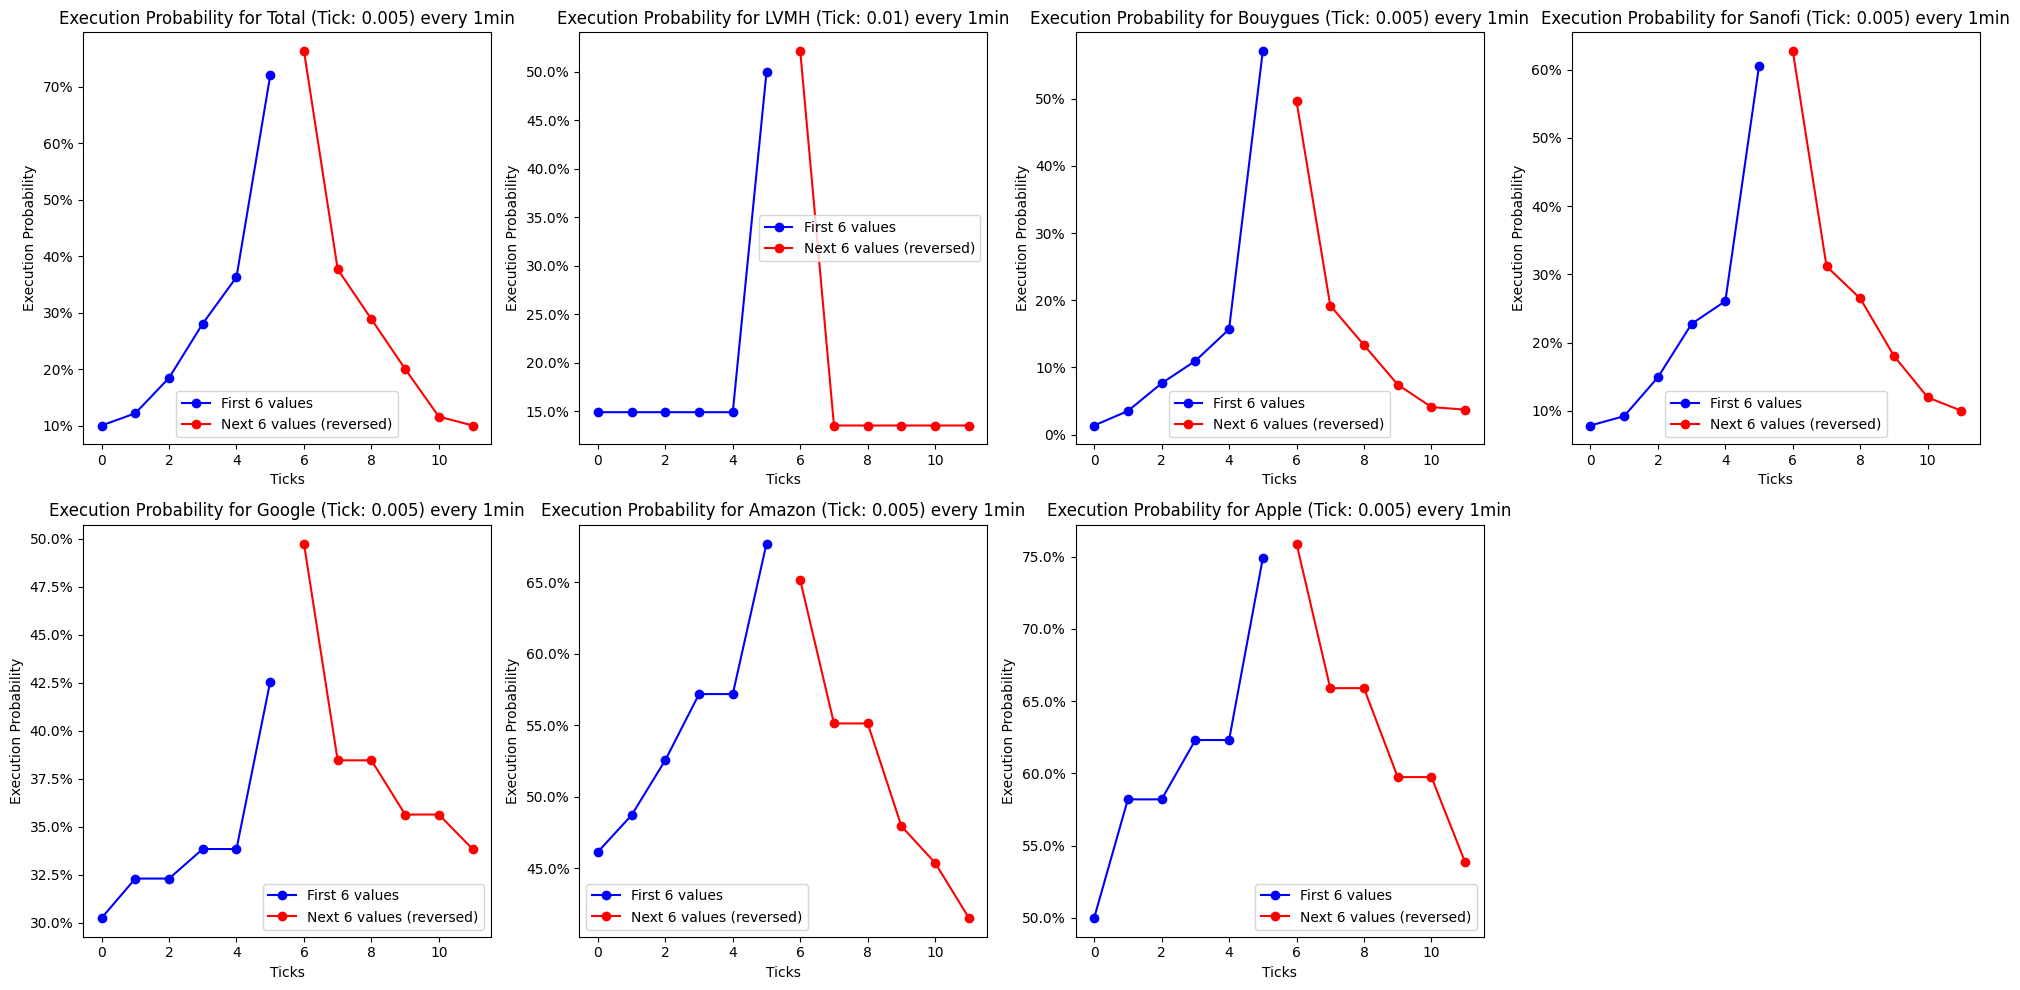

In [161]:
plot_results(results_1m,"1min","Execution Probability")

### 5 Seconds to fill:

In [162]:
results_5s = compute_exec_proba_LOB (list_FR_US_name,list_FR_US,start_date,end_date,"5s",5)
results_5s


--- Execution probability per tick every 5s ---



,Security,Tick value,Best Bid -5 ticks,Best Bid -4 ticks,Best Bid -3 ticks,Best Bid -2 ticks,Best Bid -1 ticks,Best Bid -0 ticks,Best Ask +0 ticks,Best Ask +1 ticks,Best Ask +2 ticks,Best Ask +3 ticks,Best Ask +4 ticks,Best Ask +5 ticks
0,Total,0.005,0.245%,0.425%,1.029%,2.467%,4.248%,21.585%,22.794%,4.216%,2.190%,1.062%,0.523%,0.408%
1,LVMH,0.010,0.948%,0.948%,0.948%,0.948%,0.948%,9.075%,8.584%,0.801%,0.801%,0.801%,0.801%,0.801%
2,Bouygues,0.005,0.016%,0.065%,0.196%,0.408%,0.964%,11.193%,8.873%,1.307%,0.572%,0.245%,0.098%,0.082%
3,Sanofi,0.005,0.180%,0.229%,0.589%,1.357%,2.322%,16.759%,16.138%,3.385%,1.962%,0.916%,0.458%,0.311%
4,Google,0.005,2.350%,2.714%,2.714%,3.120%,3.120%,6.880%,8.269%,3.504%,3.504%,2.714%,2.714%,2.415%
5,Amazon,0.005,3.932%,4.936%,5.598%,7.885%,7.885%,17.756%,17.500%,7.906%,7.906%,5.577%,4.915%,3.974%
6,Apple,0.005,7.885%,10.791%,10.791%,15.128%,15.128%,28.718%,31.816%,16.197%,16.197%,11.795%,11.795%,9.017%


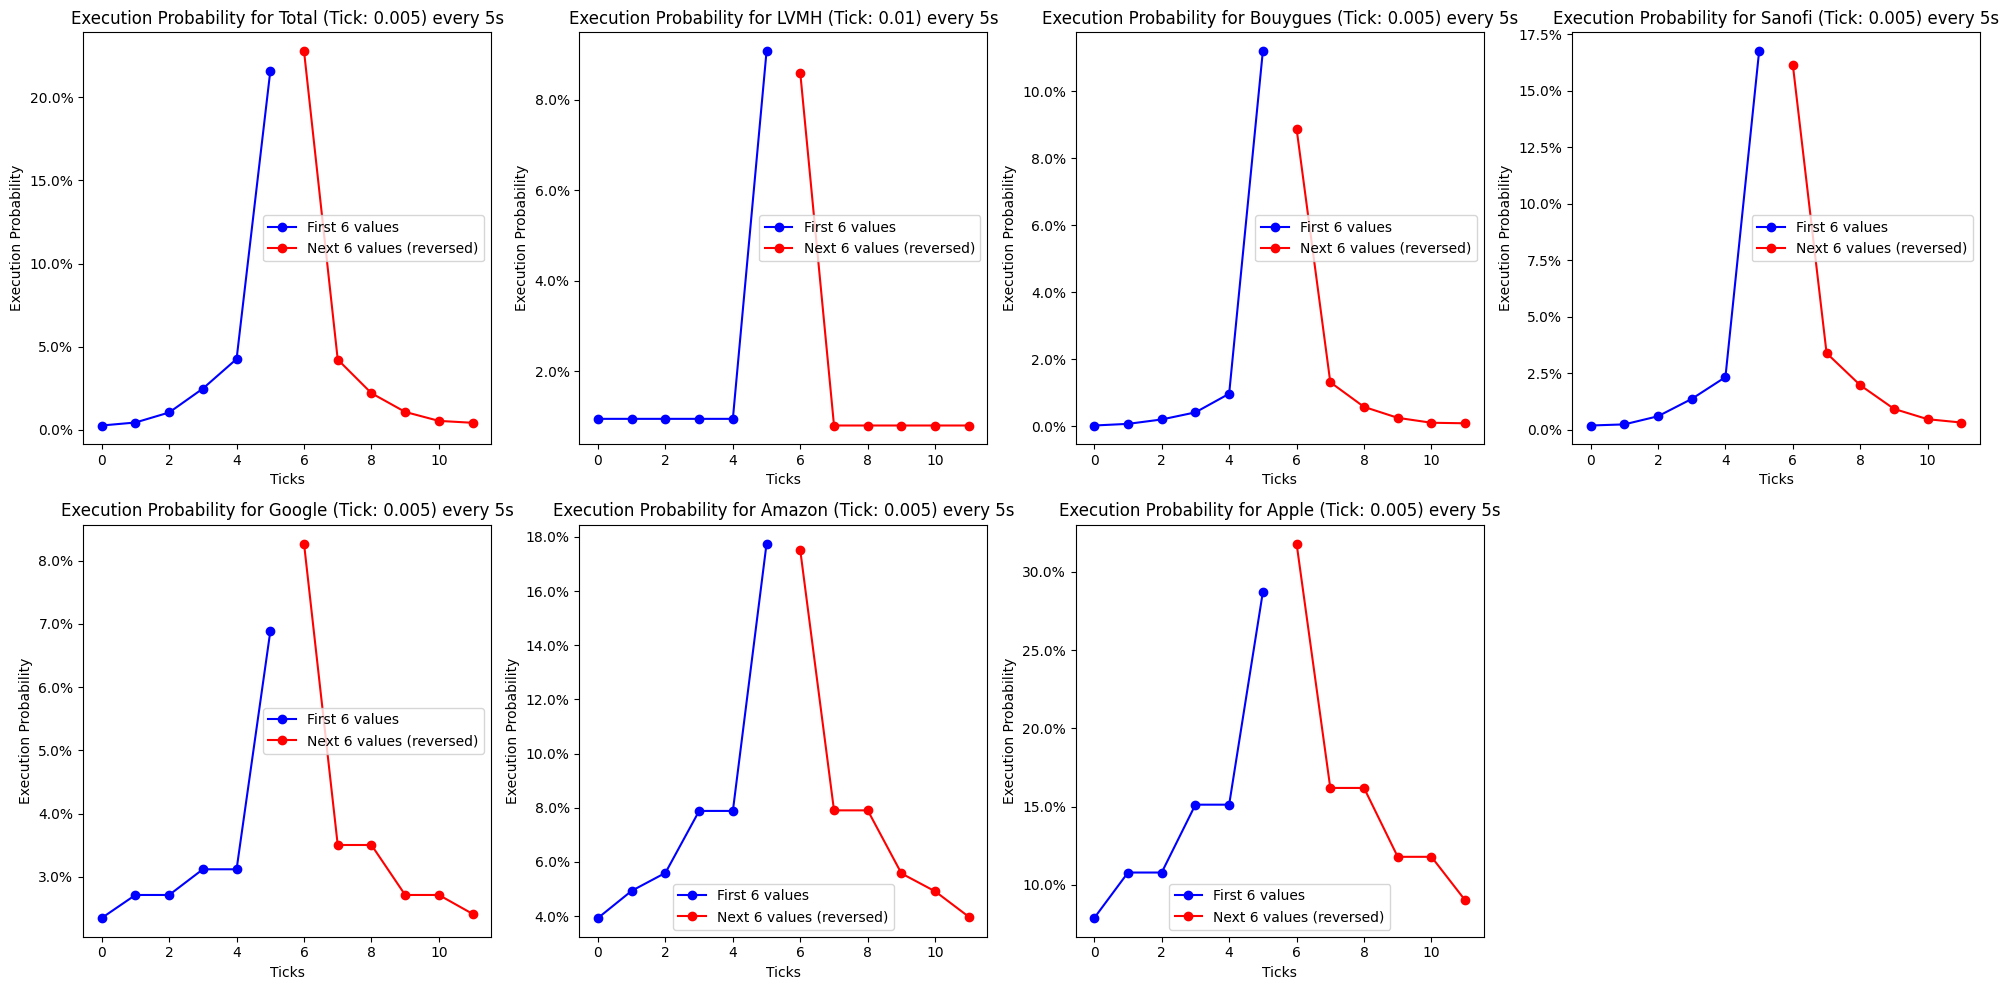

In [163]:
plot_results(results_5s,"5s","Execution Probability")

### Exploring the time dependancy:

In [164]:
# List of dataframes and their corresponding labels
dataframes = [
    (results_30, "30 Minutes"),
    (results_15, "15 Minutes"),
    (results_5m, "5 Minutes"),
    (results_1m, "1 Minute"),
    (results_5s, "5 Seconds")
]

times_values = build_and_display_asset_tables(dataframes, list_FR_US, results_30, "Proba exec")

Proba exec Total,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid -5 ticks,70.588%,52.941%,39.216%,10.000%,0.245%
Best Bid -4 ticks,70.588%,52.941%,41.176%,12.157%,0.425%
Best Bid -3 ticks,82.353%,70.588%,54.902%,18.431%,1.029%
Best Bid -2 ticks,88.235%,76.471%,62.745%,28.039%,2.467%
Best Bid -1 ticks,88.235%,79.412%,69.608%,36.275%,4.248%
Best Bid -0 ticks,94.118%,91.176%,86.275%,71.961%,21.585%
Best Ask +0 ticks,94.118%,91.176%,91.176%,76.275%,22.794%
Best Ask +1 ticks,88.235%,82.353%,68.627%,37.647%,4.216%
Best Ask +2 ticks,82.353%,76.471%,62.745%,28.824%,2.190%


Proba exec Sanofi,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid -5 ticks,58.824%,50.000%,31.373%,7.843%,0.180%
Best Bid -4 ticks,58.824%,50.000%,32.353%,9.216%,0.229%
Best Bid -3 ticks,64.706%,58.824%,43.137%,14.902%,0.589%
Best Bid -2 ticks,82.353%,70.588%,53.922%,22.745%,1.357%
Best Bid -1 ticks,82.353%,73.529%,59.804%,26.078%,2.322%
Best Bid -0 ticks,82.353%,82.353%,76.471%,60.588%,16.759%
Best Ask +0 ticks,94.118%,94.118%,88.235%,62.745%,16.138%
Best Ask +1 ticks,94.118%,85.294%,68.627%,31.176%,3.385%
Best Ask +2 ticks,94.118%,82.353%,61.765%,26.471%,1.962%


Proba exec Apple,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid -5 ticks,92.308%,88.462%,75.641%,50.000%,7.885%
Best Bid -4 ticks,92.308%,88.462%,79.487%,58.205%,10.791%
Best Bid -3 ticks,92.308%,88.462%,79.487%,58.205%,10.791%
Best Bid -2 ticks,92.308%,88.462%,82.051%,62.308%,15.128%
Best Bid -1 ticks,92.308%,88.462%,82.051%,62.308%,15.128%
Best Bid -0 ticks,92.308%,88.462%,85.897%,74.872%,28.718%
Best Ask +0 ticks,100.000%,100.000%,93.590%,75.897%,31.816%
Best Ask +1 ticks,92.308%,96.154%,87.179%,65.897%,16.197%
Best Ask +2 ticks,92.308%,96.154%,87.179%,65.897%,16.197%


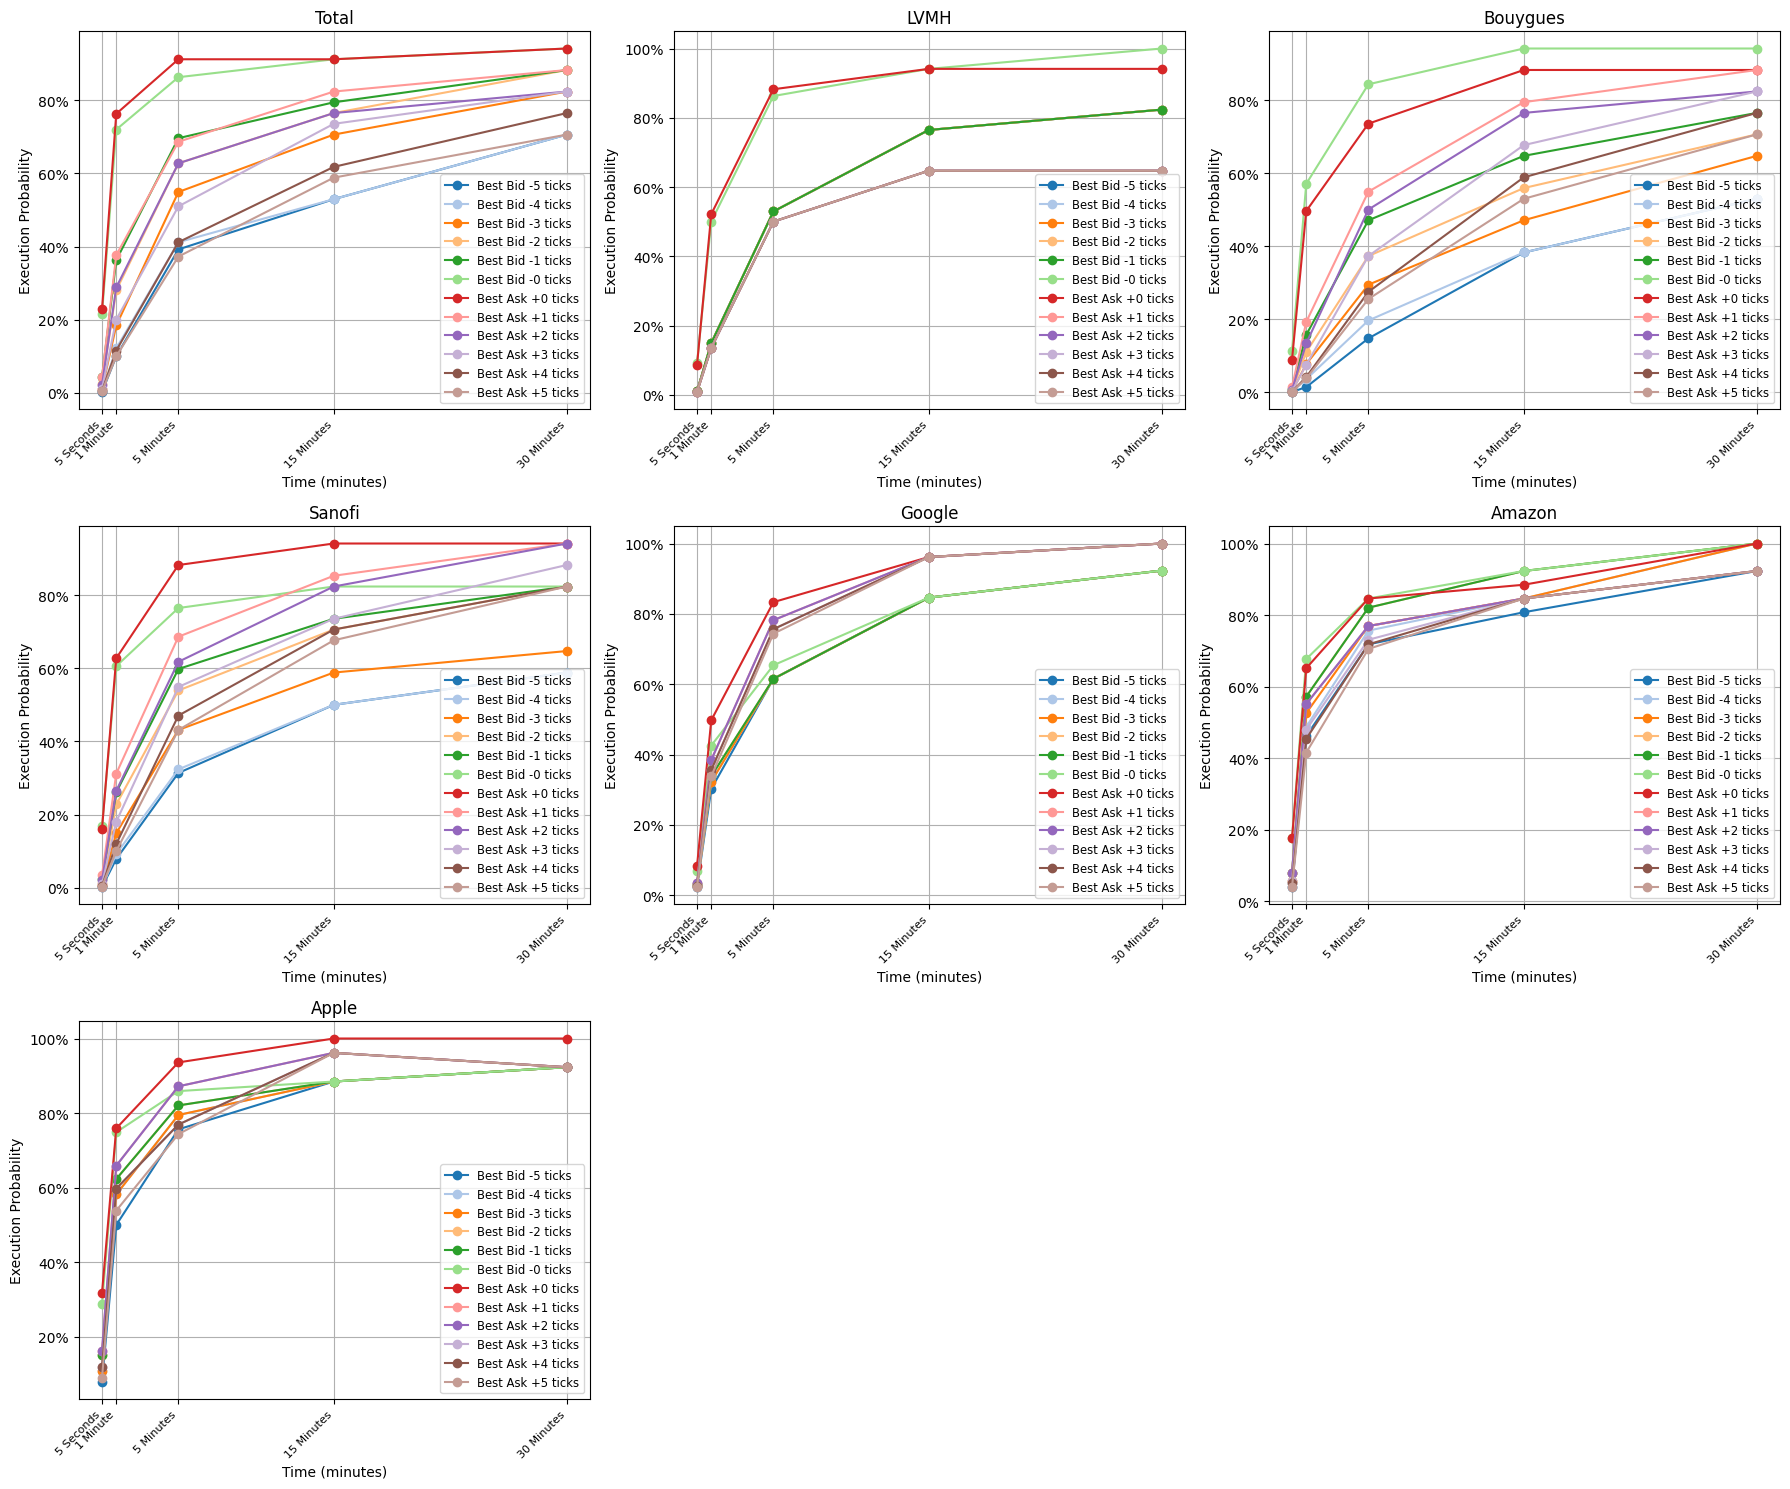

In [181]:
plot_all_assets_execution_curves(time_values,dataframes,"Execution Probability")

#### Comments:

We observe that for all assets, the further away from the best bid or ask, the lower the execution probability. It is also noted that the shorter the trading period, the lower the overall execution probability, especially for limit orders placed far from the best bid or ask. Indeed, over a short time period, the price tends to move less and therefore explores fewer levels around the last traded price. As the trading period increases, the execution probability converges towards 1, though at different speeds for U.S. versus European assets, and more subtly between individual assets within each geographic class.

However, execution probabilities are significantly higher for U.S. assets. Prices are much more volatile over the same periods compared to European assets. This is due to the significantly greater liquidity of these securities, which is partly related to their market capitalization but also to the higher trading activity in U.S. markets compared to European ones. This explains why we observe consistent execution probabilities across several ticks for certain assets, especially American ones: these securities are more often subject to meta-orders that cause substantial price movements, sweeping through multiple levels of the order book and resulting in price changes that are rarely just one tick but often more. This could also be an indicator that the tick size is too small for that particular asset.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">1.2. Fillrate</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

## II. Fillrate

### 1. Definition

* Instantaneous volume obtained when orders are posted inside the orderbook
* Dependent on order parameters (size, distance, duration, type)
* Also dependent on market factors (volatility, spread, volume, etc.)
* Can be estimated by modeling from empirical data.

### 2. Fillrate at Distance

We consider an agent who catches liquidity (at the bid or at the ask) on a market by only posting passive limit orders. Her placement strategy consists in
* posting a limit order of size 1 at a distance $d$ (in ticks) from the best price (bid or ask) ;
* waiting $t$ minutes ;
* if the order is executed before the end of the period, she instantenously posts the same order (side, price, volume, distance) ;
* counting at the end the number of executions of her type of orders on the period ;
* canceling the last unexecuted order and replacing the same quantity at the same distance $d$ and side for the same duration $t$.

### 3. Implementation

a. Plot the price dynamics and the associated fillrate of this posting strategy.

b. Compare with different durations $t$ (in minutes) : 1 minute, 5 minutes, 10 minutes, 15 minutes, 30 minutes.

c. Compare with different fixed distances ($0\leq d\leq 4$).

d. Comment.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">1.2.1 Fillrate results</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

In [219]:
def get_row_inventory_vol_spread(name, inventories, vols, spreads, ticks):

    """
    Aggregates inventory, volatility, and spread statistics by tick distance for one asset.

    Parameters
    ----------
    name: str
          Asset identifier.
    inventories: list
                 List of inventory arrays per tick distance.
    vols: list
          List of realized volatility arrays per tick distance.
    spreads: list
             List of average spread arrays per tick distance.
    ticks: list
           List of tick distances corresponding to each inventory/volatility/spread list.

    Returns
    -------
    summary_df: pd.DataFrame
                Summary statistics comparing executions vs non-executions.
    """
    
    summary_rows = []
    
    for p, (inv_list, vol_list, spr_list) in enumerate(zip(inventories, vols, spreads)):
        
        inv_array = np.array(inv_list)
        vol_array = np.array(vol_list)
        spr_array = np.array(spr_list)
        
       # Create boolean masks to separate executed vs non-executed orders
        executed_mask = inv_array != 0
        not_executed_mask = inv_array == 0

        # Compute average volatility for both executed and non-executed orders
        vol_exec = np.nanmean(vol_array[executed_mask])
        vol_non_exec = np.nanmean(vol_array[not_executed_mask])

        # Compute average spreads for executed and non-executed orders
        spr_exec = np.nanmean(spr_array[executed_mask])
        spr_non_exec = np.nanmean(spr_array[not_executed_mask])

        # Construct a summary row for this tick level
        row = {
            'Security': name,
            'Tick distance': ticks[p],
            'Avg Vol (exec)': f"{vol_exec*100:.6f}%",
            'Avg Vol (no exec)': f"{vol_non_exec*100:.6f}%",
            'Ratio Vol exec / non-exec': f"{vol_exec/vol_non_exec:.3f}",
            'Avg Spread (exec)': spr_exec,
            'Avg Spread (no exec)': spr_non_exec,
            'Ratio Spread exec / non-exec': f"{spr_exec/spr_non_exec:.3f}",
            'Inventory': np.sum(inv_array),
        }
        
        summary_rows.append(row) # Append the row to the result list
    summary_df = pd.DataFrame(summary_rows)
    
    return summary_df

def plot_fillrate_dynamics(price_dynamic, LOB_price_dynamics, period, direction, tick_level,name):

    """
    Plots the time series of traded price and synthetic order levels over time.

    Parameters
    ----------
    price_dynamic: array-like
                   Actual traded prices over time.
    LOB_price_dynamics: list
                        List of synthetic order level trajectories.
    period: str
            Time window string used in fillrate simulation.
    direction: str
               'Bid' or 'Ask' side being simulated.
    tick_level: list
                List of tick distances simulated.
    name: str
          Asset name for labeling.
    """
    
    plt.figure(figsize=(15, 5))

    # Plot the traded price series in black as the reference
    plt.plot(price_dynamic, label=f"Traded Price ({name})", color='black')
    for idx, LOB_price_dynamic in enumerate (LOB_price_dynamics):

        # Tick level 0 = best bid/ask → labeled simply "Best"
        if tick_level[idx] == 0 : 
            plt.plot(LOB_price_dynamic, label=f"Best {direction}", linestyle='--')
        else : 
            plt.plot(LOB_price_dynamic, label=f"Best {direction} with {tick_level[idx]} tick)", linestyle='--') # For tick offsets, display how far from best price

    plt.title(f"{name} Price Dynamics & Order Level ({direction}), Period = {period}")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def get_vol_spread(df, i, j):

    """
    Computes realized volatility and average spread between two indices.

    Parameters
    ----------
    df: pd.DataFrame
        Price and spread data with precomputed cumulative sums.
    i: int
       Start index.
    j: int
       End index.

    Returns
    -------
    realized_vol: float
                  Volatility over [i, j].
    avg_spread: float
                Average spread over [i, j].
    """

    # If the window is a single point, volatility and spread are undefined
    if j == i:
        return np.nan, np.nan
    
    n = j - i + 1 # Number of data points in the interval [i, j]
    
    # Precomputed cumulative series for squared log returns and spreads
    cum_logret = df['LogRetSqCumSum']
    cum_spread = df['SpreadCumSum']
        
    # Handle edge case i = 0
    logret_sum = cum_logret.iloc[j] - (cum_logret.iloc[i-1] if i > 0 else 0)
    spread_sum = cum_spread.iloc[j] - (cum_spread.iloc[i-1] if i > 0 else 0)

    realized_vol = np.sqrt(logret_sum) / n  # Realized volatility is the square root of return variance per unit time
    avg_spread = spread_sum / n # Average spread is simple mean over the window
    
    return realized_vol, avg_spread

def precompute_vol_spread_data(df):

    """
    Precomputes squared log returns and bid-ask spreads (and their cumulative sums)
    to allow fast computation of volatility and spread over any time window.

    Parameters
    ----------
    df: pd.DataFrame
        Tick-level price data with 'TradedPrice', 'BidPrice', and 'AskPrice'.

    Returns
    -------
    df: pd.DataFrame
        Same DataFrame with added columns:
        - 'LogRetSq': squared log return
        - 'LogRetSqCumSum': cumulative sum of squared log returns
        - 'Spread': instantaneous bid-ask spread
        - 'SpreadCumSum': cumulative sum of spreads
    """
    
    df = df.copy() # Defensive copy to avoid modifying the original DataFrame
    df['LogPrice'] = np.log(df['TradedPrice'])  # Compute log price for each timestamp
    df['LogRetSq'] = df['LogPrice'].diff() ** 2  # Compute squared log returns (price variation proxy)
    df['LogRetSq'] = df['LogRetSq'].fillna(0)
    df['LogRetSqCumSum'] = df['LogRetSq'].cumsum() # Cumulative sum for fast windowed volatility computation

    # Compute bid-ask spread
    df['Spread'] = df['AskPrice'] - df['BidPrice']
    df['Spread'] = df['Spread'].fillna(0)

    # Cumulative spread for fast windowed average spread
    df['SpreadCumSum'] = df['Spread'].cumsum()
    return df
    
def fillrate_at_distance (name_list,data_list,start_date,end_date,period,tick_distance, direction, plot=False,inventory_param =False, plot_vol_spread=False): 

    """
    Simulates limit order executions at varying tick distances and records
    fill rates or signed inventory, optionally tracking volatility/spread.

    Parameters
    ----------
    name_list: list
               List of asset names to process.
    data_list: list
               List of DataFrames (tick-level market data) for each asset.
    start_date: datetime
                Start of the simulation period.
    end_date: datetime
              End of the simulation period.
    period: str
            Lifetime of a simulated limit order (e.g. '5Min').
    tick_distance: int
                   Number of ticks above/below best bid/ask to simulate.
    direction: str
               'Bid' or 'Ask' side to simulate.
    plot: bool
          If True, plots price & order level evolution over time.
    inventory_param: bool
                     If True, compute inventory, volatility, and spread per order.
    plot_vol_spread: bool
                     If True, display volatility/spread diagnostics post-simulation.

    Returns
    -------
    None
        Displays DataFrames and plots; returns nothing.
    """
    
    tick_dict = {} # Store tick size per asset
    data_dict =  {} # Store filtered and cleaned data per asset
    final_results =[] # Final summary output for all assets

    # Loop through each asset
    for name, data in zip(name_list, data_list): 
        tick_dict[name] = get_tick(data['TradedPrice'])  # Compute tick size (smallest price increment)
        data.index = pd.to_datetime(data.index)  # Ensure datetime index for filtering
        data = data[(data.index >= start_date) & (data.index < end_date)] # Filter data within requested date range
        data_dict[name] = data  # Store cleaned data
    
    for name, data in data_dict.items():

        duration = pd.Timedelta(period)  # Convert the period string (e.g., "5Min") into a Timedelta object
        row = {'Security': name, 'Tick value':tick_dict[name]} # Row that will store final results for this asset
        price_dynamics = data['TradedPrice'].to_numpy() # Convert traded prices to NumPy array for plotting (if enabled)
        LOB_price_dynamics = [] 
        ticks_value=[]

         # If inventory tracking is enabled, initialize buffers
        if inventory_param :
            inventories = []
            vols = []
            spreads=[]
            data = precompute_vol_spread_data(data) # Precompute cumulative data for volatility/spread

        # Loop over tick distances (0 = best bid/ask, up to N ticks away)
        for p in range (tick_distance+1):

            LOB_price_dynamic = []
            number_of_orders = 0 
            executed_orders = 0
            inventory = np.zeros(len(data), dtype=int)
            vol = np.full(len(data), np.nan)
            spread = np.full(len(data), np.nan)
            i=0 # Index of current time step

            # Loop through the time series to simulate limit orders
            while i <len(data) : 
                t0 = data.index[i] # Timestamp of current order
                snapshot = data.iloc[i] # Tick snapshot at time t0
                bid_levels, ask_levels = get_LOB(snapshot.to_frame().T, tick_distance, tick_dict[name]) # Get all LOB levels (bid/ask ladders) at this moment 

                # Select target limit price based on direction and tick offset
                if direction == 'Bid': 
                    target_price = bid_levels[p]
                elif direction == 'Ask': 
                    target_price = ask_levels[p]
                else:
                    raise ValueError("direction must be 'Bid' or 'Ask'")
                    
                order_life_span = 0 # Time steps before expiration or fill
                j=i # Cursor for scanning into the future
                executed = False # Execution flag for current simulated order

                # Scan forward in time to simulate the life of the order
                while j < len(data) and data.index[j] - t0 <= duration:

                    # If inventory mode is active and we're not at the origin,
                    # compute volatility and spread between i and j
                    if inventory_param and i!=j :
                        averaged_realized_vol,current_spread =  get_vol_spread(data, i, j)
                        vol[j] = averaged_realized_vol
                        spread[j] = current_spread

                    # Check if the order gets executed
                    if direction == 'Bid': 
                        if p==0 : 
                            # For best bid, strict inequality to avoid mid-cross
                            if data['TradedPrice'].iloc[j] < target_price:
                                executed_orders += 1
                                executed = True
                                if inventory_param :
                                    inventory[j] += 1 # Buy
                                    
                                i=j  # Move pointer forward after fill
                                break
                        else: 
                            # Further from best: include equality
                            if data['TradedPrice'].iloc[j] <= target_price:
                                executed_orders += 1
                                executed = True
                                if inventory_param :
                                    inventory[j] += 1
                                    
                                i=j
                                break
                        
                    elif direction == 'Ask': 
                        if p ==0 : 
                            # For best ask, strict inequality
                            if data['TradedPrice'].iloc[j] > target_price:
                                executed_orders += 1
                                executed = True
                                if inventory_param :
                                    inventory[j] += -1 # Sell
                                   
                                i=j
                                break
                        else : 

                            # Include equality for higher ticks
                            if data['TradedPrice'].iloc[j] >= target_price:
                                executed_orders += 1
                                executed = True
                                if inventory_param :
                                    inventory[j] += -1
                                   
                                i=j
                                break

                    j+=1
                    order_life_span += 1 # Count time spent waiting
                   
                LOB_price_dynamic.extend([target_price] * order_life_span) # Extend the synthetic order level over its life      
                number_of_orders += 1  # Count this simulated order
                i = j  # Move to next position
                
            LOB_price_dynamics.append(LOB_price_dynamic) # Store the LOB trajectory at this tick level (for plotting)

            # If inventory mode is on, save execution buffers
            if inventory_param :
                inventories.append(inventory)
                vols.append(vol)
                spreads.append(spread)
            ticks_value.append(p) # Save tick level (used for labeling)

            # --- Add result to the row ---
            if inventory_param :
                if p == 0 : 
                    if direction == 'Bid': 
                        row[f'Best {direction}'] = f"{np.array(inventories[-1]).sum()}"
                    elif direction == 'Ask': 
                        row[f'Best {direction}'] = f"{np.array(inventories[-1]).sum()}"
                else : 
                    if direction == 'Bid': 
                        row[f'Best {direction} - {p} ticks'] = f"{np.array(inventories[-1]).sum()}"
                    elif direction == 'Ask': 
                        row[f'Best {direction} + {p} ticks'] = f"{np.array(inventories[-1]).sum()}"
            else : 
                if p == 0 : 
                    if direction == 'Bid': 
                        row[f'Best {direction}'] =  f"{(executed_orders/number_of_orders)*100:.3f}%"
                    elif direction == 'Ask': 
                        row[f'Best {direction}'] =  f"{(executed_orders/number_of_orders)*100:.3f}%"
                else : 
                    if direction == 'Bid': 
                        row[f'Best {direction} - {p} ticks'] =  f"{(executed_orders/number_of_orders)*100:.3f}%"
                    elif direction == 'Ask': 
                        row[f'Best {direction} + {p} ticks'] =  f"{(executed_orders/number_of_orders)*100:.3f}%"
                        
        final_results.append(row) # Store the result for this asset

        # Optional: Plot the price and LOB evolution
        if plot : 
            plot_fillrate_dynamics(price_dynamics, LOB_price_dynamics, period, direction, ticks_value,name)

        # Optional: Show inventory vs vol/spread summary
        if inventory_param and plot_vol_spread : 
            summary_df =  get_row_inventory_vol_spread (name,inventories, vols, spreads, ticks_value)
            summary_df.name = f"Inventory vs Volatility & Spread — {direction}, {period}"
            print(f"\n--- {summary_df.name} ---\n")
            display(summary_df)

    final_results = pd.DataFrame(final_results) # Compile the full results table

    # Set table title based on mode
    if inventory_param:
        final_results.name = f"Inventory with a {period} period"
    else: 
        final_results.name = f"Fillrate with a {period} period"
    # print(f"\n--- {final_results.name} ---\n")
    if not plot: 
        return final_results, final_results.name 

def merge_fillrate_tables(bid_df, ask_df):
    """
    Merge Bid and Ask fillrate tables by aligning tick columns
    in intuitive left-to-right order: Best Bid -5 → ... → Best Bid → Best Ask → ... → Best Ask +5

    Parameters
    ----------
    bid_df : pd.DataFrame
        Table of Bid-side results
    ask_df : pd.DataFrame
        Table of Ask-side results

    Returns
    -------
    pd.DataFrame
        Clean merged table with properly ordered columns.
    """
    keep_cols = ['Security', 'Tick value']

    # Extract tick columns
    bid_tick_cols = [col for col in bid_df.columns if col not in keep_cols]
    ask_tick_cols = [col for col in ask_df.columns if col not in keep_cols]

    # Reverse the order of bid tick columns
    bid_tick_cols = bid_tick_cols[::-1]

    # Merge on common ID columns
    merged = pd.merge(
        bid_df[keep_cols + bid_tick_cols],
        ask_df[keep_cols + ask_tick_cols],
        on=keep_cols,
        how='inner'
    )

    return merged[keep_cols + bid_tick_cols + ask_tick_cols]


### Exploring for each time horizon the fillrate of limit orders for a full week:

In [193]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8+24*4, minutes=30)

list_FR_US = list_FR + list_US
list_FR_US_name = list_FR_name+list_US_name
number_tests = 5
results_30_bid, name_30_bid = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"30min",number_tests,"Bid")
results_30_ask, name_30_ask = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"30min",number_tests,"Ask")


--- Fillrate with a 30min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,71.429%,73.333%,80.328%,88.660%,91.129%,93.820%,95.215%,93.464%,91.803%,86.905%,82.812%,80.702%
1,LVMH,0.010,88.406%,88.406%,88.406%,88.406%,88.406%,88.406%,85.075%,85.075%,85.075%,85.075%,85.075%,85.075%
2,Bouygues,0.005,60.000%,61.290%,75.610%,80.769%,84.848%,87.952%,90.654%,88.235%,86.765%,81.818%,71.053%,67.500%
3,Sanofi,0.005,62.500%,70.213%,75.439%,82.716%,85.393%,88.496%,97.561%,96.648%,95.946%,94.000%,88.889%,87.879%
4,Google,0.005,86.111%,86.667%,86.667%,87.500%,87.500%,87.500%,93.043%,93.043%,93.043%,91.919%,91.919%,90.217%
5,Amazon,0.005,88.462%,89.157%,89.899%,91.803%,91.803%,91.803%,96.335%,96.335%,96.335%,95.425%,95.000%,94.488%
6,Apple,0.005,90.991%,92.537%,92.537%,94.819%,94.819%,94.819%,98.083%,98.083%,98.083%,97.156%,97.156%,96.386%


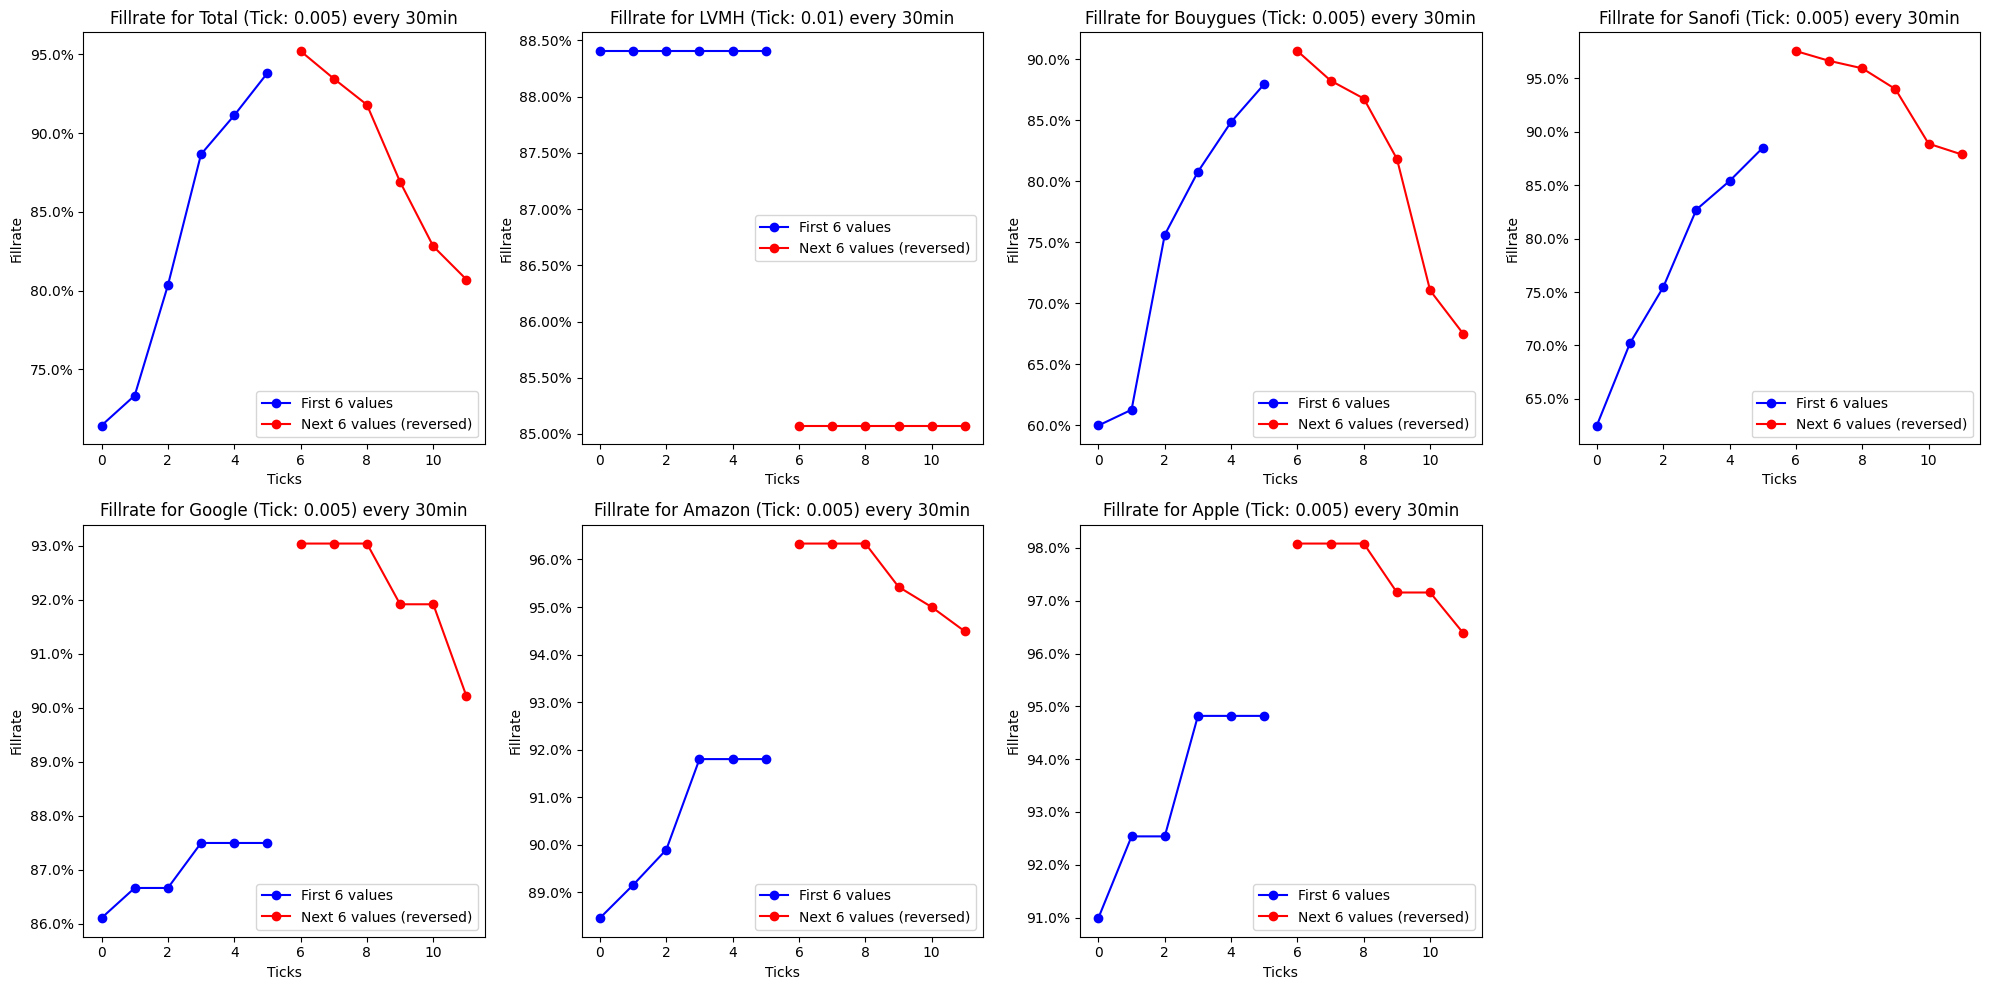

In [194]:
results_30 = merge_fillrate_tables(results_30_bid, results_30_ask)
print(f"\n--- {name_30_bid} ---\n")
display(results_30)
plot_results(results_30,"30min","Fillrate")

In [195]:
results_15_bid, name_15_bid = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"15min",number_tests,"Bid")
results_15_ask, name_15_ask = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"15min",number_tests,"Ask")


--- Fillrate with a 15min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,66.667%,68.116%,76.136%,82.927%,85.811%,90.338%,93.870%,91.623%,88.742%,82.692%,74.684%,72.973%
1,LVMH,0.010,81.053%,81.053%,81.053%,81.053%,81.053%,81.053%,76.136%,76.136%,76.136%,76.136%,76.136%,76.136%
2,Bouygues,0.005,46.939%,52.830%,62.319%,73.034%,78.302%,82.836%,88.050%,85.271%,80.808%,76.829%,62.903%,59.322%
3,Sanofi,0.005,52.542%,58.462%,67.568%,76.699%,80.620%,83.871%,95.105%,93.171%,91.279%,85.593%,79.570%,78.161%
4,Google,0.005,84.746%,86.290%,86.290%,87.218%,87.218%,87.218%,89.809%,89.809%,89.809%,88.966%,88.966%,87.218%
5,Amazon,0.005,85.586%,86.667%,88.235%,90.643%,90.643%,90.643%,94.007%,94.007%,94.007%,92.417%,91.623%,90.643%
6,Apple,0.005,89.881%,91.584%,91.584%,94.444%,94.464%,94.464%,96.734%,96.734%,96.734%,95.341%,95.341%,93.839%


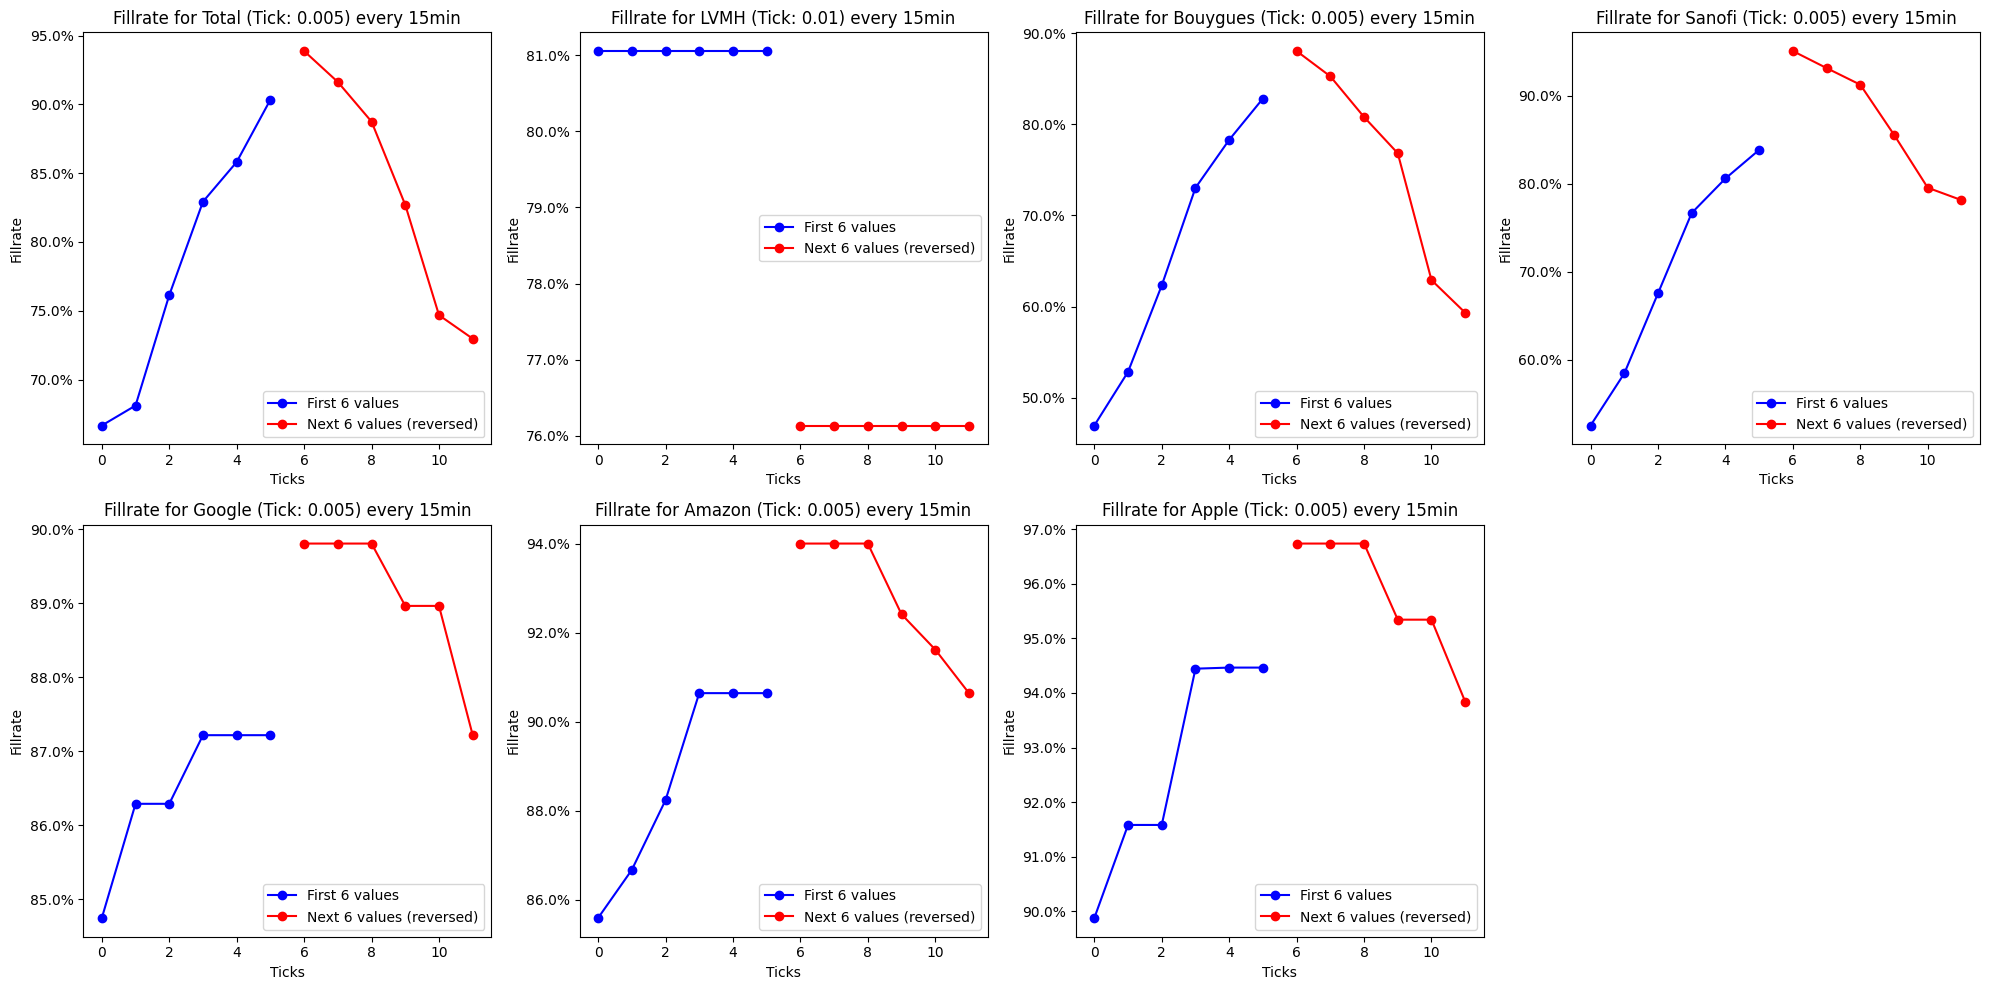

In [196]:
results_15 = merge_fillrate_tables(results_15_bid, results_15_ask)
print(f"\n--- {name_15_bid} ---\n")
display(results_15)
plot_results(results_15,"15min","Fillrate")

In [197]:
results_5_bid, name_5_bid = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5min",number_tests,"Bid")
results_5_ask, name_5_ask = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5min",number_tests,"Ask")


--- Fillrate with a 5min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,46.575%,50.667%,61.749%,74.409%,79.114%,85.106%,85.681%,80.793%,75.097%,65.152%,50.667%,47.945%
1,LVMH,0.010,64.607%,64.607%,64.607%,64.607%,64.607%,64.607%,59.259%,59.259%,59.259%,59.259%,59.259%,59.259%
2,Bouygues,0.005,24.545%,30.252%,42.222%,53.614%,62.944%,69.362%,75.197%,67.000%,59.302%,47.518%,36.290%,33.051%
3,Sanofi,0.005,34.127%,36.719%,47.333%,61.081%,68.493%,74.903%,86.256%,80.745%,77.239%,65.641%,54.658%,51.634%
4,Google,0.005,75.490%,75.814%,75.814%,78.112%,78.112%,78.112%,79.828%,79.828%,79.828%,76.777%,76.777%,74.877%
5,Amazon,0.005,75.743%,78.970%,80.247%,84.014%,84.014%,84.014%,88.064%,88.064%,88.064%,85.034%,83.456%,82.000%
6,Apple,0.005,80.935%,84.615%,84.615%,89.916%,89.937%,89.937%,92.580%,92.580%,92.580%,89.720%,89.720%,85.498%


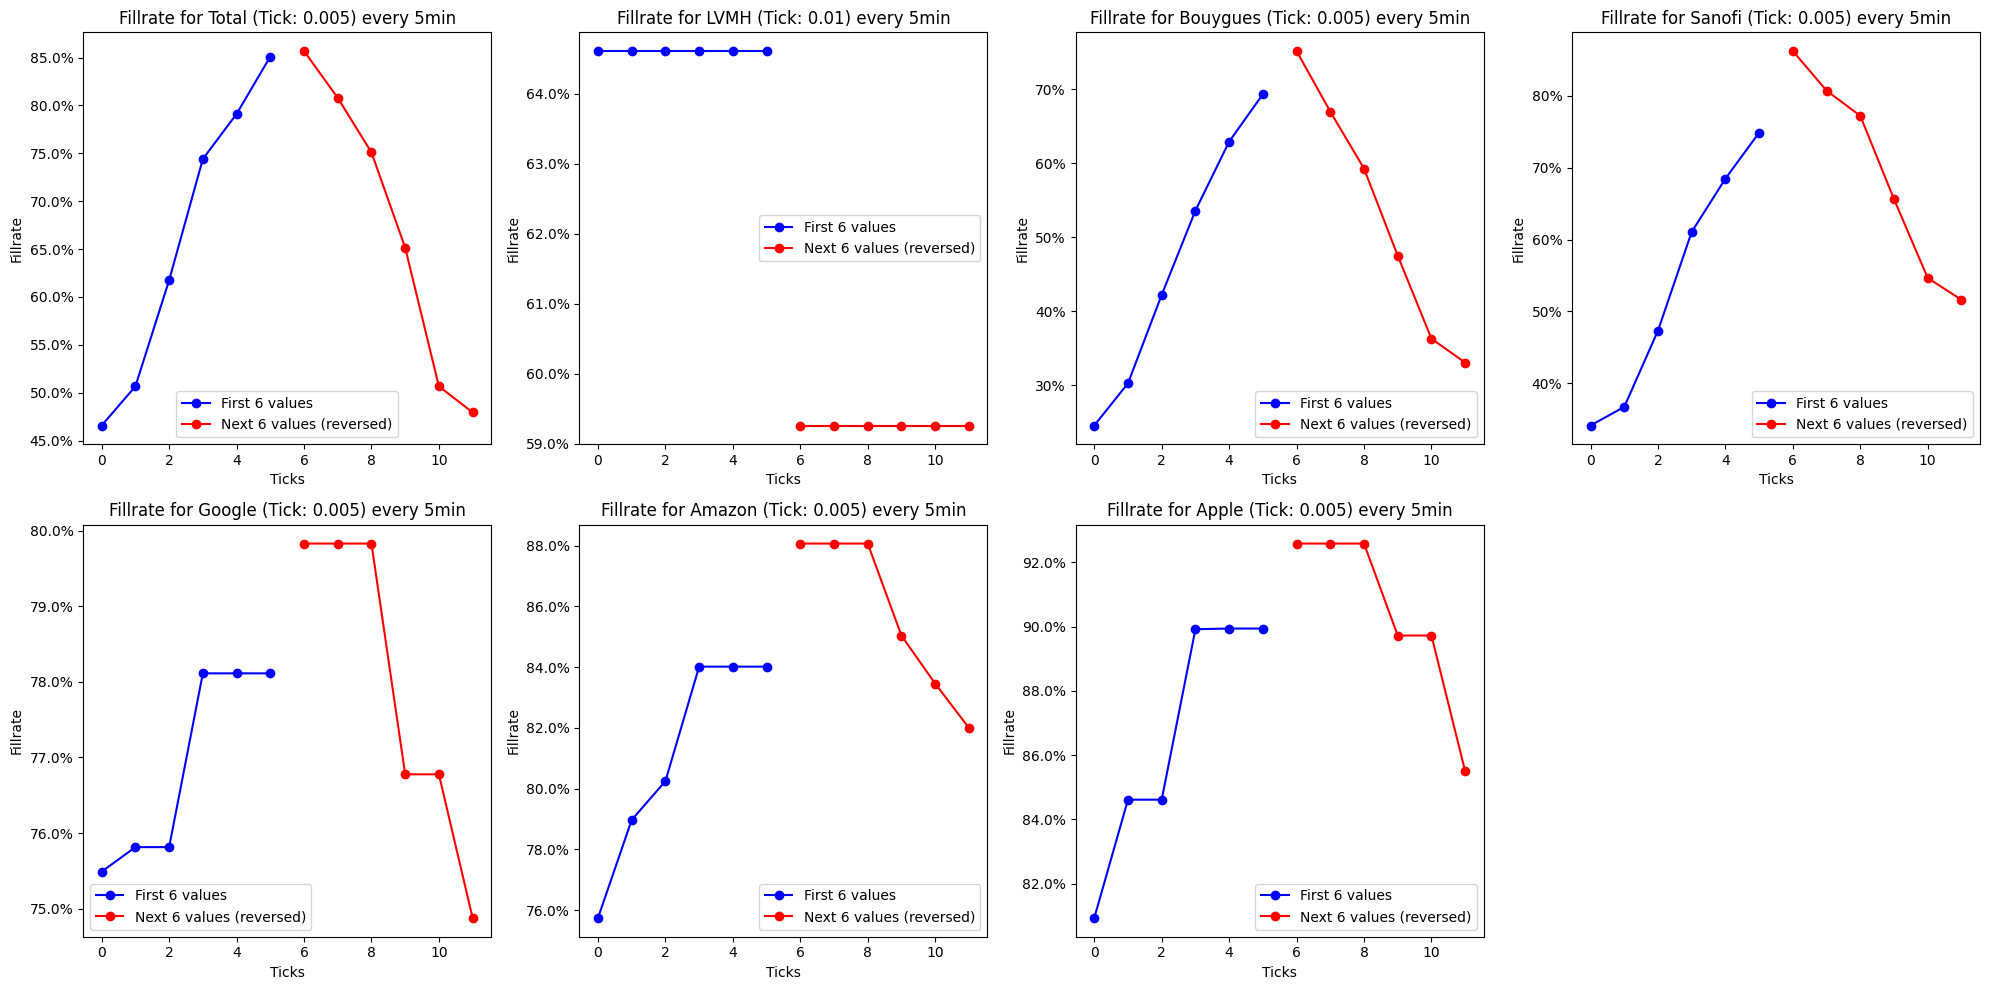

In [198]:
results_5 = merge_fillrate_tables(results_5_bid, results_5_ask)
print(f"\n--- {name_5_bid} ---\n")
display(results_5)
plot_results(results_5,"5min","Fillrate")

In [199]:
results_1_bid, name_1_bid = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"1min",number_tests,"Bid")
results_1_ask, name_1_ask = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"1min",number_tests,"Ask")


--- Fillrate with a 1min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,14.712%,17.954%,29.278%,42.448%,53.495%,62.034%,63.503%,53.453%,43.408%,29.567%,17.155%,14.468%
1,LVMH,0.010,28.960%,28.960%,28.960%,28.960%,28.960%,28.960%,28.429%,28.429%,28.429%,28.429%,28.429%,28.429%
2,Bouygues,0.005,2.857%,5.882%,12.169%,21.308%,30.652%,37.822%,41.346%,32.251%,22.169%,13.263%,6.111%,5.042%
3,Sanofi,0.005,8.916%,11.876%,20.225%,33.728%,42.632%,50.779%,62.515%,53.687%,44.595%,30.677%,18.610%,17.500%
4,Google,0.005,46.667%,50.000%,50.000%,53.974%,53.974%,53.974%,53.774%,53.774%,53.774%,50.000%,50.000%,47.122%
5,Amazon,0.005,52.264%,56.894%,58.949%,66.054%,66.054%,66.054%,71.359%,71.359%,71.324%,63.407%,60.802%,56.610%
6,Apple,0.005,60.646%,67.122%,67.122%,75.822%,75.845%,75.845%,80.371%,80.371%,80.371%,71.737%,71.705%,64.503%


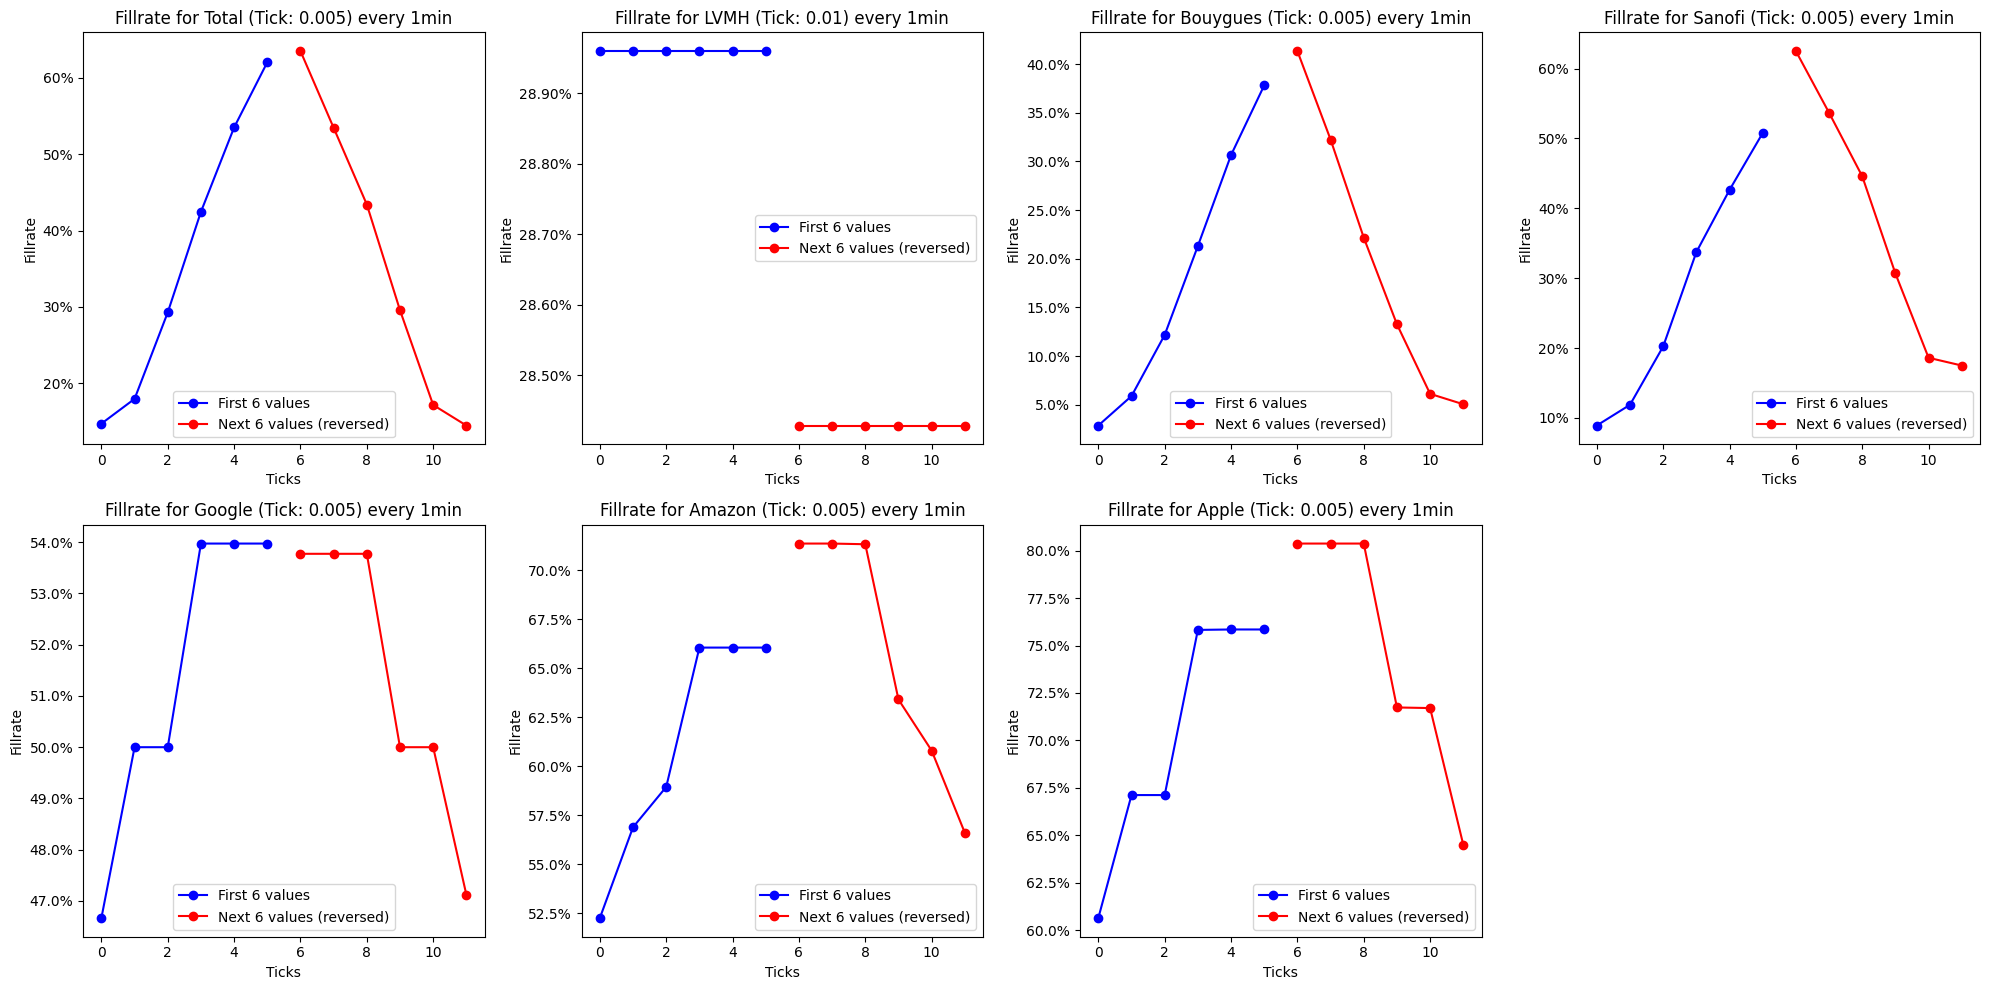

In [200]:
results_1 = merge_fillrate_tables(results_1_bid, results_1_ask)
print(f"\n--- {name_1_bid} ---\n")
display(results_1)
plot_results(results_1,"1min","Fillrate")

In [201]:
results_5s_bid, name_5s_bid = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5s",number_tests,"Bid")
results_5s_ask, name_5s_ask = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5s",number_tests,"Ask")


--- Fillrate with a 5s period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,1.158%,1.776%,4.043%,9.741%,16.110%,21.953%,20.797%,15.747%,8.458%,4.225%,1.631%,1.156%
1,LVMH,0.010,6.660%,6.660%,6.660%,6.660%,6.660%,6.660%,6.640%,6.640%,6.640%,6.640%,6.640%,6.640%
2,Bouygues,0.005,0.094%,0.751%,1.399%,3.565%,6.637%,9.075%,12.761%,9.091%,4.533%,1.676%,0.751%,0.564%
3,Sanofi,0.005,0.907%,1.386%,2.507%,6.117%,10.738%,15.068%,22.195%,16.501%,10.201%,4.971%,1.918%,1.445%
4,Google,0.005,13.353%,14.897%,14.897%,16.888%,16.888%,16.888%,16.855%,16.855%,16.855%,13.620%,13.620%,12.730%
5,Amazon,0.005,11.825%,14.781%,17.452%,24.370%,24.370%,24.370%,25.965%,25.965%,25.965%,18.078%,16.108%,12.926%
6,Apple,0.005,16.683%,23.788%,23.811%,33.882%,33.900%,33.900%,37.055%,37.055%,37.055%,25.820%,25.820%,18.809%


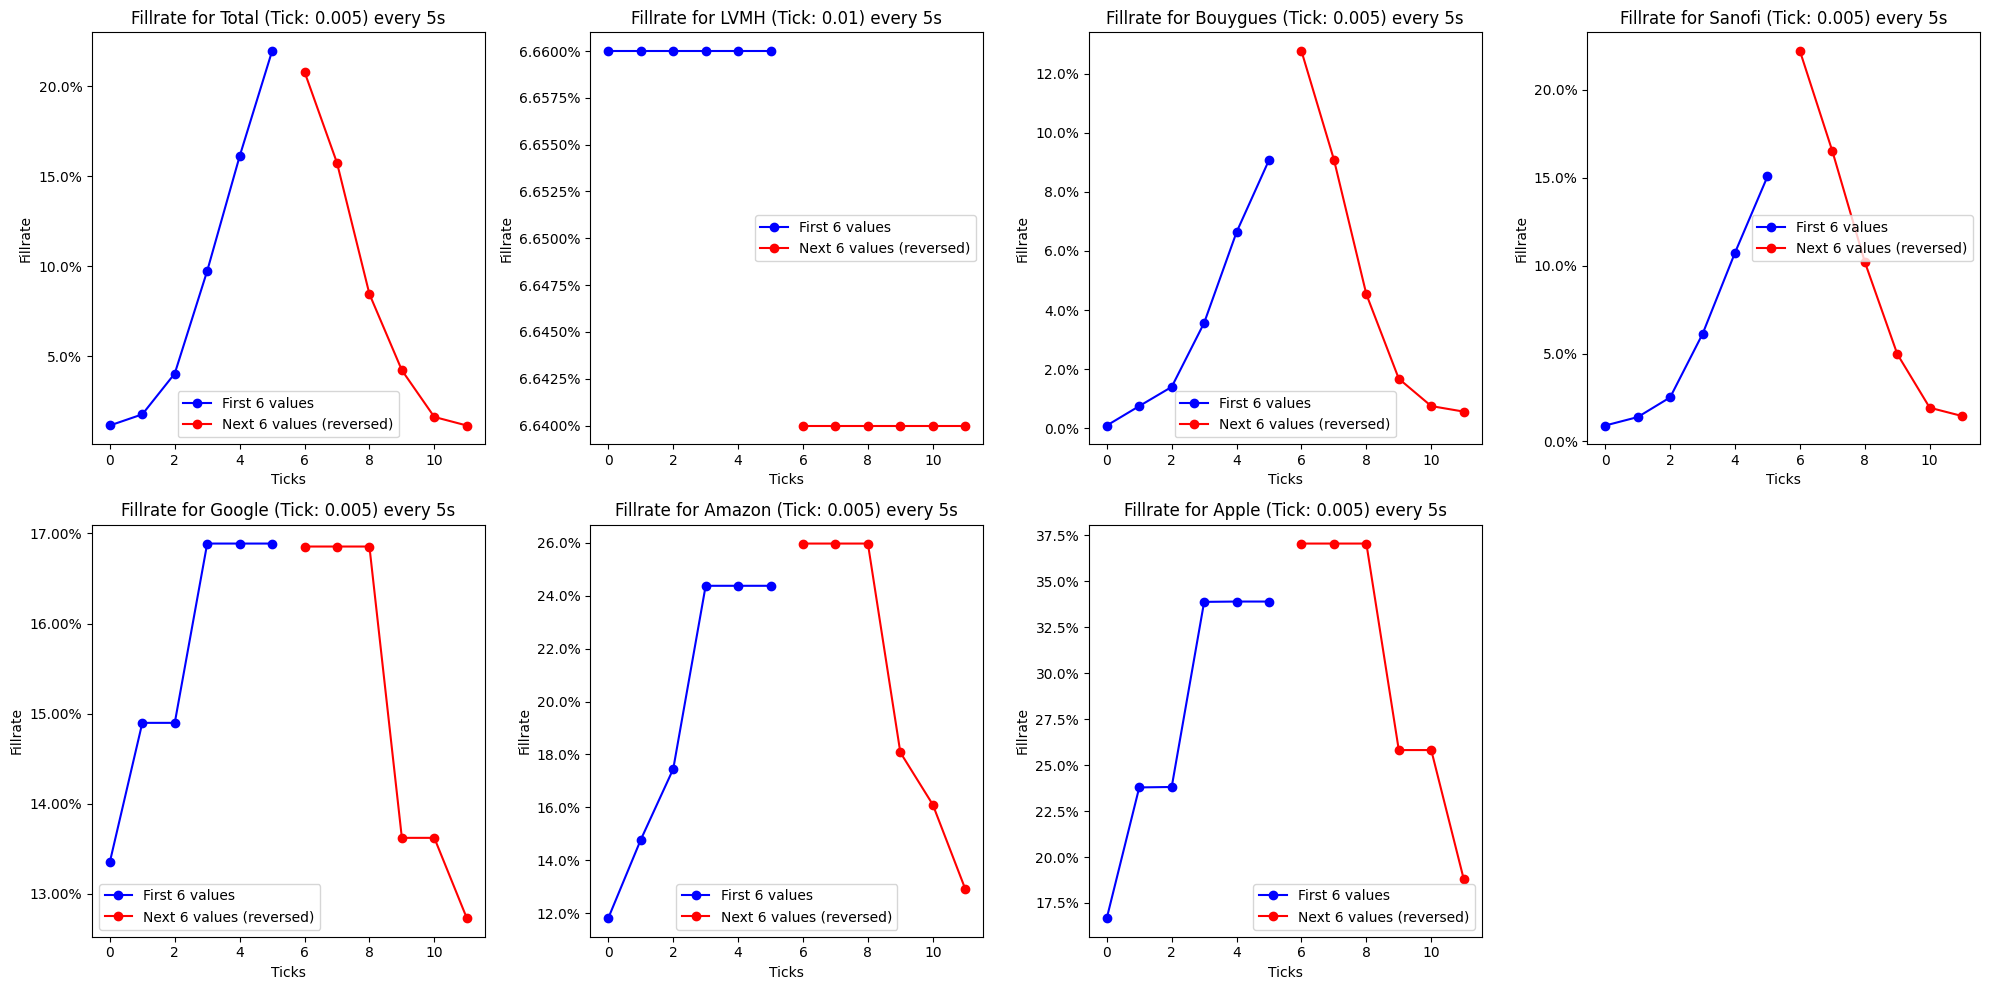

In [202]:
results_5s = merge_fillrate_tables(results_5s_bid, results_5s_ask)
print(f"\n--- {name_5s_bid} ---\n")
display(results_5s)
plot_results(results_5s,"5s","Fillrate")

### Exploring the time dependancy:

In [203]:
dataframes = [
    (results_30, "30 Minutes"),
    (results_15, "15 Minutes"),
    (results_5, "5 Minutes"),
    (results_1, "1 Minute"),
    (results_5s, "5 Seconds")
]

times_values = build_and_display_asset_tables(dataframes, list_FR_US, results_30, "Fillrate")

Fillrate Total,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid - 5 ticks,71.429%,66.667%,46.575%,14.712%,46.575%
Best Bid - 4 ticks,73.333%,68.116%,50.667%,17.954%,50.667%
Best Bid - 3 ticks,80.328%,76.136%,61.749%,29.278%,61.749%
Best Bid - 2 ticks,88.660%,82.927%,74.409%,42.448%,74.409%
Best Bid - 1 ticks,91.129%,85.811%,79.114%,53.495%,79.114%
Best Bid,93.820%,90.338%,85.106%,62.034%,85.106%
Best Ask,95.215%,93.870%,85.681%,63.503%,85.681%
Best Ask + 1 ticks,93.464%,91.623%,80.793%,53.453%,80.793%
Best Ask + 2 ticks,91.803%,88.742%,75.097%,43.408%,75.097%


Fillrate Sanofi,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid - 5 ticks,62.500%,52.542%,34.127%,8.916%,34.127%
Best Bid - 4 ticks,70.213%,58.462%,36.719%,11.876%,36.719%
Best Bid - 3 ticks,75.439%,67.568%,47.333%,20.225%,47.333%
Best Bid - 2 ticks,82.716%,76.699%,61.081%,33.728%,61.081%
Best Bid - 1 ticks,85.393%,80.620%,68.493%,42.632%,68.493%
Best Bid,88.496%,83.871%,74.903%,50.779%,74.903%
Best Ask,97.561%,95.105%,86.256%,62.515%,86.256%
Best Ask + 1 ticks,96.648%,93.171%,80.745%,53.687%,80.745%
Best Ask + 2 ticks,95.946%,91.279%,77.239%,44.595%,77.239%


Fillrate Apple,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid - 5 ticks,90.991%,89.881%,80.935%,60.646%,80.935%
Best Bid - 4 ticks,92.537%,91.584%,84.615%,67.122%,84.615%
Best Bid - 3 ticks,92.537%,91.584%,84.615%,67.122%,84.615%
Best Bid - 2 ticks,94.819%,94.444%,89.916%,75.822%,89.916%
Best Bid - 1 ticks,94.819%,94.464%,89.937%,75.845%,89.937%
Best Bid,94.819%,94.464%,89.937%,75.845%,89.937%
Best Ask,98.083%,96.734%,92.580%,80.371%,92.580%
Best Ask + 1 ticks,98.083%,96.734%,92.580%,80.371%,92.580%
Best Ask + 2 ticks,98.083%,96.734%,92.580%,80.371%,92.580%


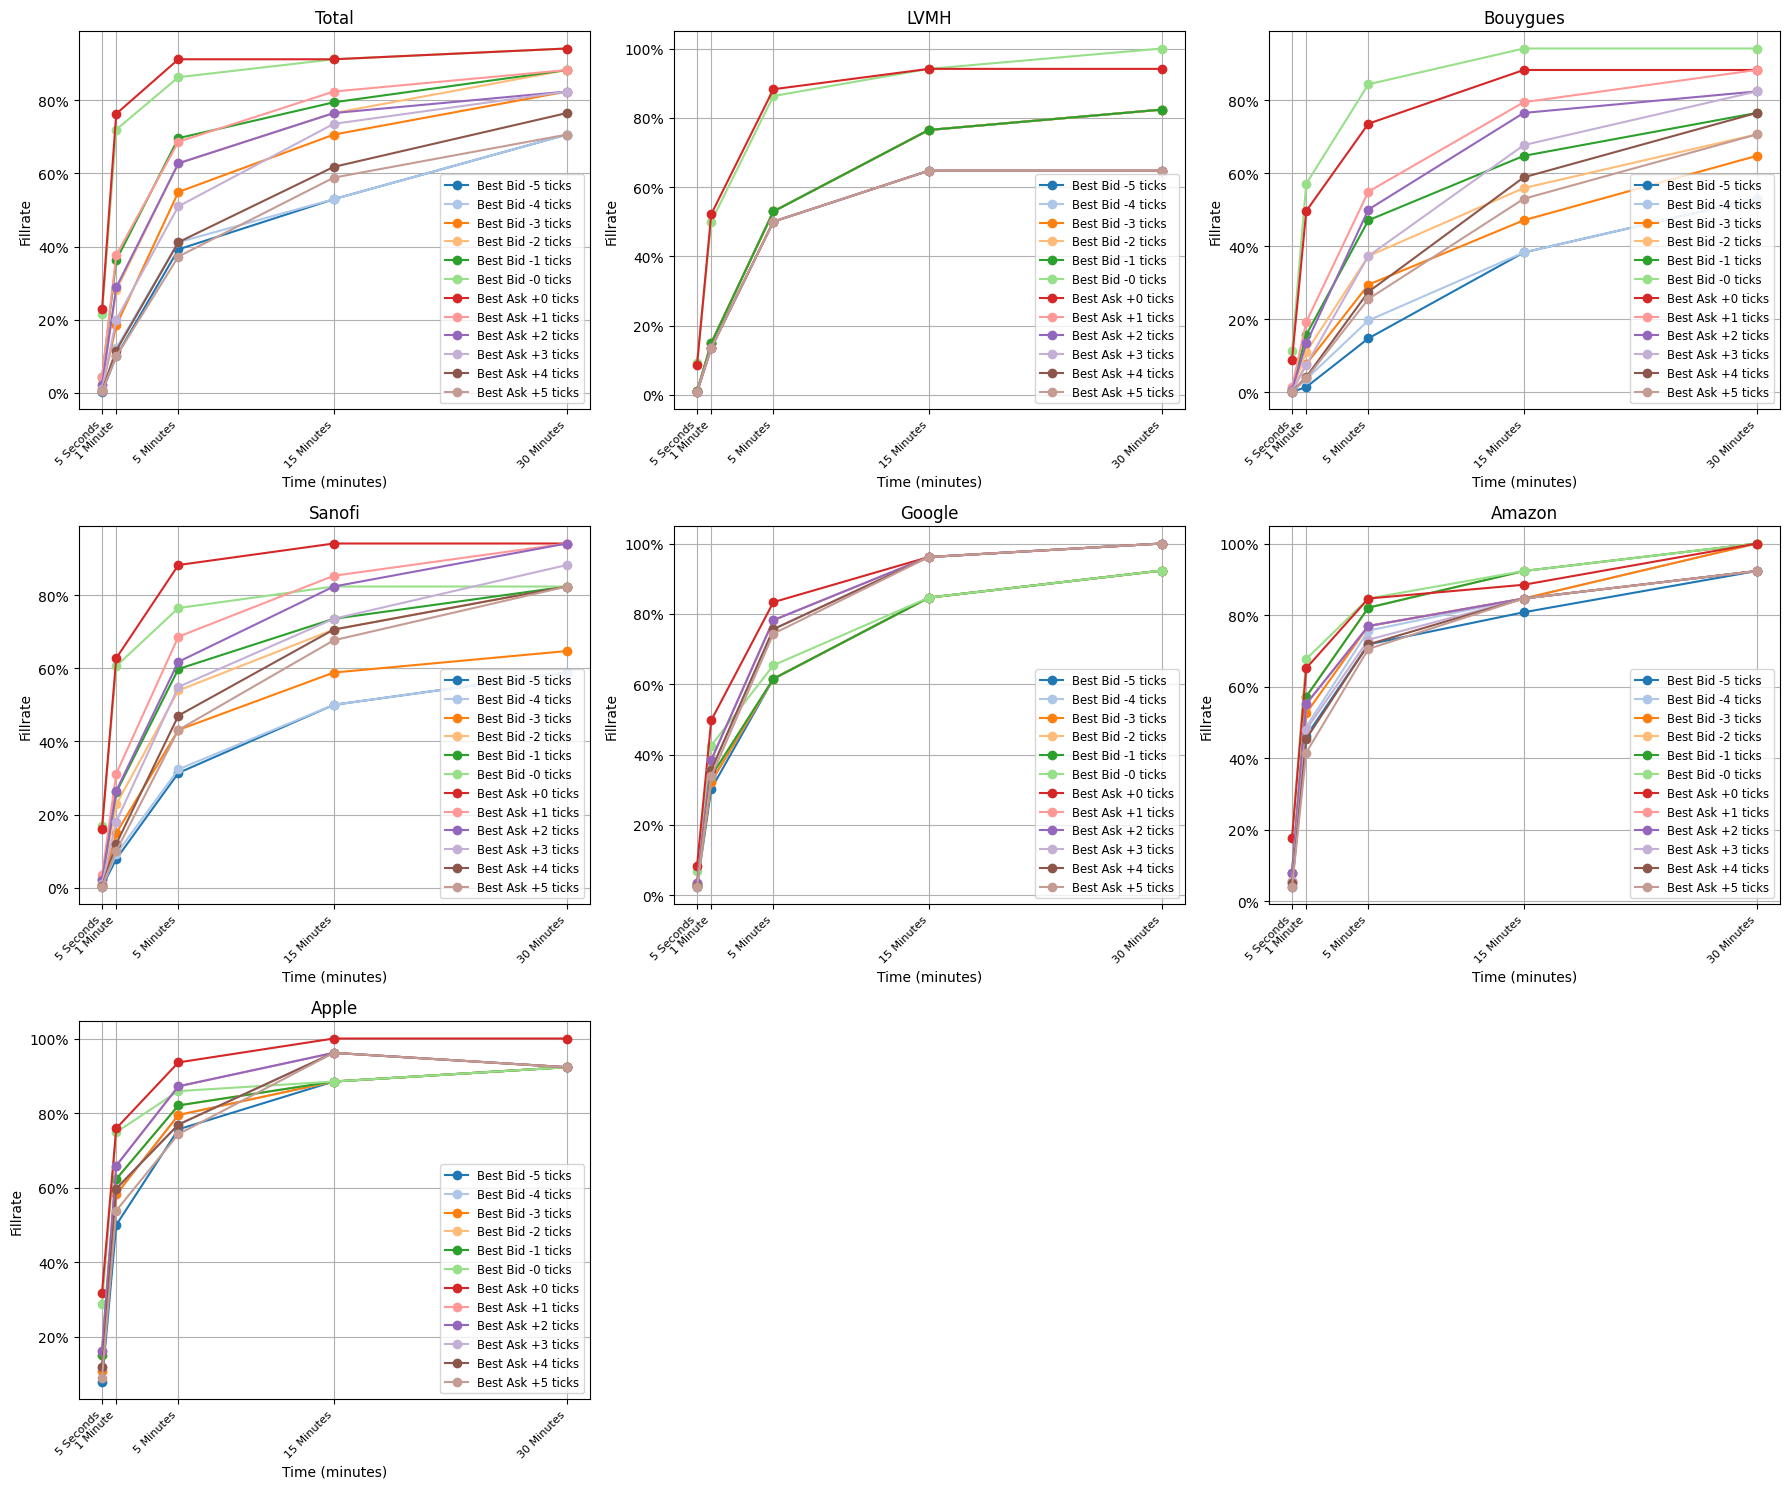

In [204]:
plot_all_assets_execution_curves(time_values,dataframes,"Fillrate")

### Comments:

The same observations made regarding execution probability also apply here. However, it is important to note that any differences in the evolution over time of the bid or ask fill rate are intrinsically linked to the specific trading week under consideration. Indeed, due to the systematic nature of the strategy and the limitation of limit orders to a maximum of 5 ticks from the best price, in a bearish market, for example, ask orders are more likely to be filled than bid orders, since the price is trending downward. The reverse is true during a session with an upward price trend. To properly assess the impact, it would be necessary to analyze data over several months, which the code allows.

The difference between U.S. and French assets remains very significant, as previously mentioned, due to liquidity and market depth for such securities. Nevertheless, we observe that LVMH shows very good fill rates, confirming our hypothesis that market capitalization is strongly linked to liquidity. A stock cannot exceed a certain nominal price for obvious manageability reasons, which results in a greater number of shares for a high market cap and, consequently, higher liquidity.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">1.2.2 Fillrate illustration for french stocks with period = 5mn on only one day</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

We only plot data from a single day for visualization purposes. As a result, the idiosyncratic effect linked to the price dynamics on that specific day will be significant and will typically create a noticeable asymmetry between the bid and the ask.

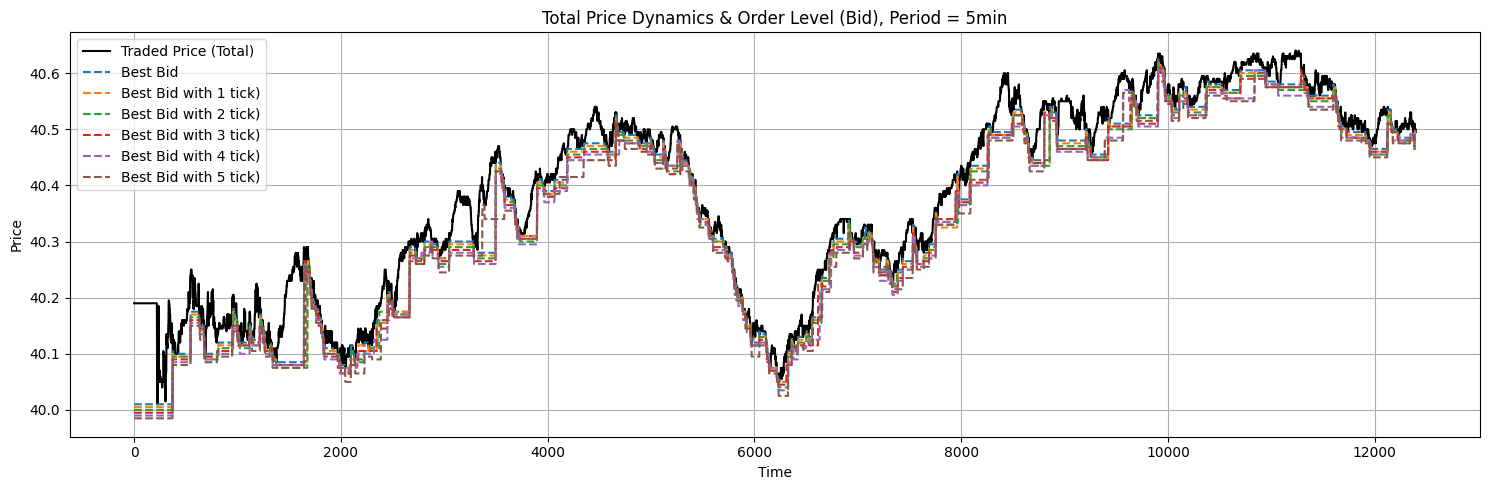

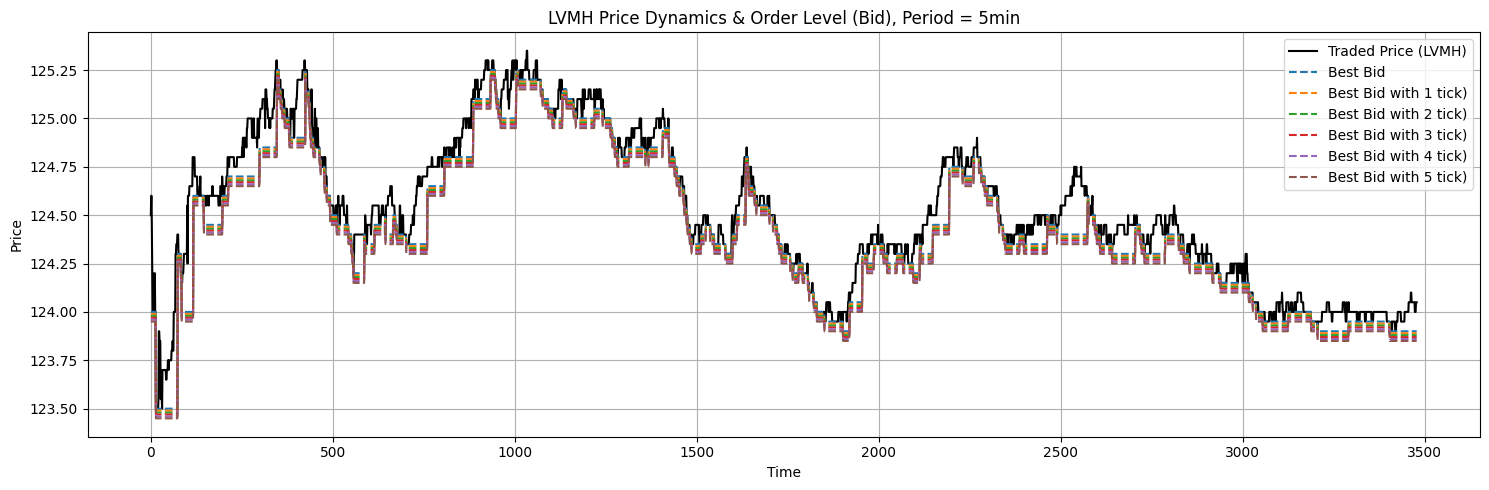

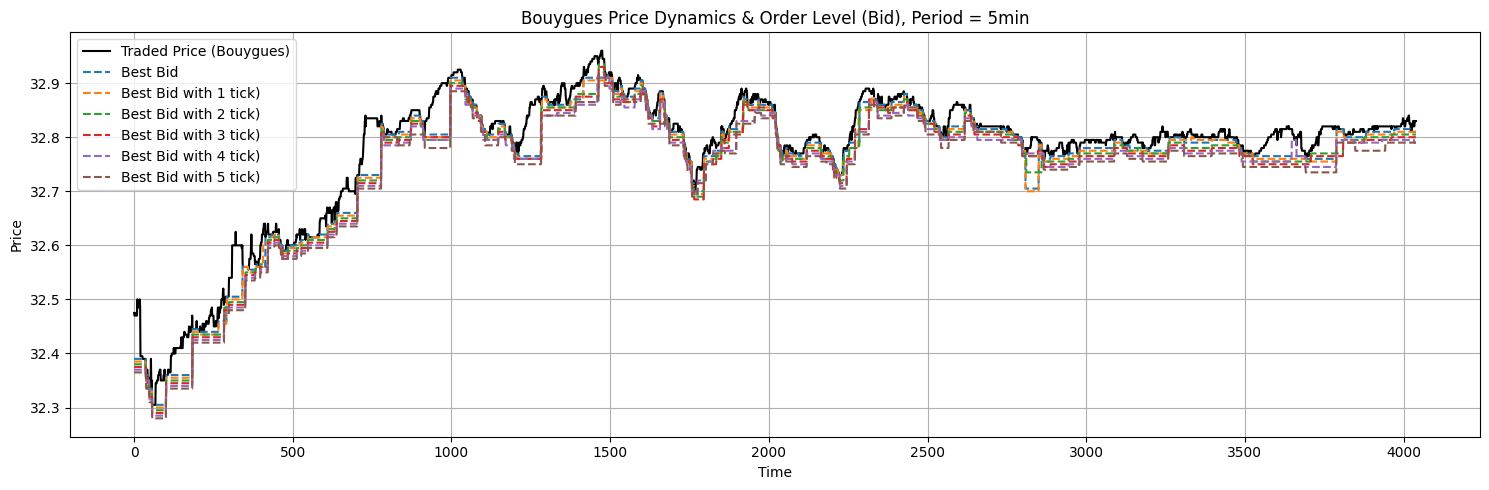

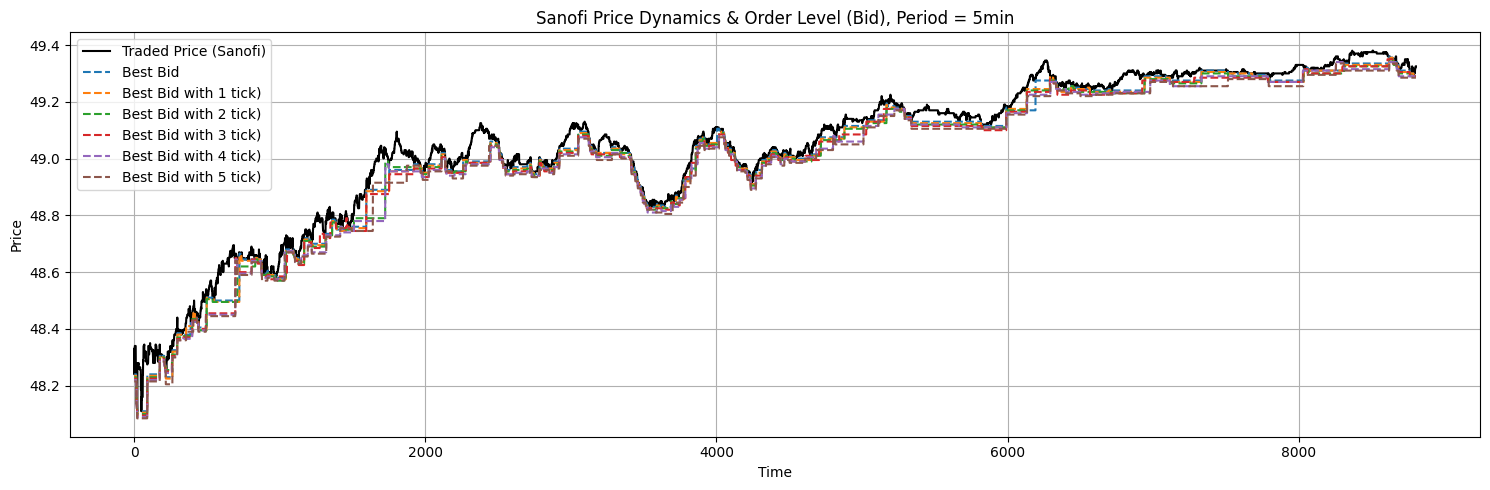

In [227]:
end_date = start_date + pd.Timedelta(hours=8, minutes=30)
fillrate_at_distance (list_FR_name,list_FR,start_date,end_date,"5min",number_tests,"Bid", plot = True)

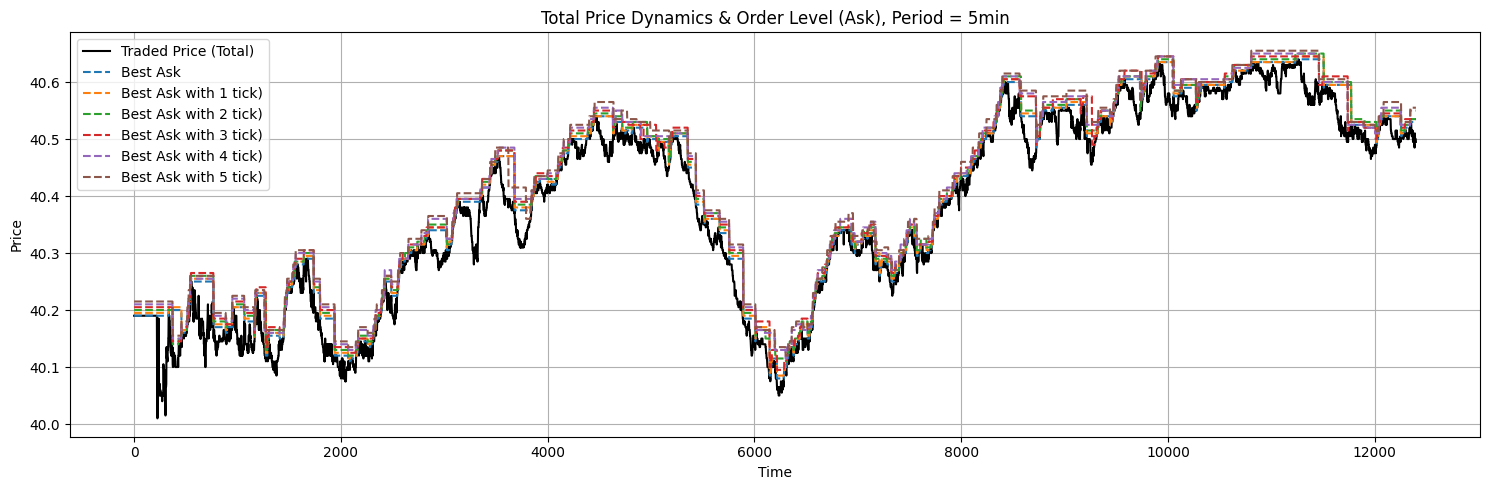

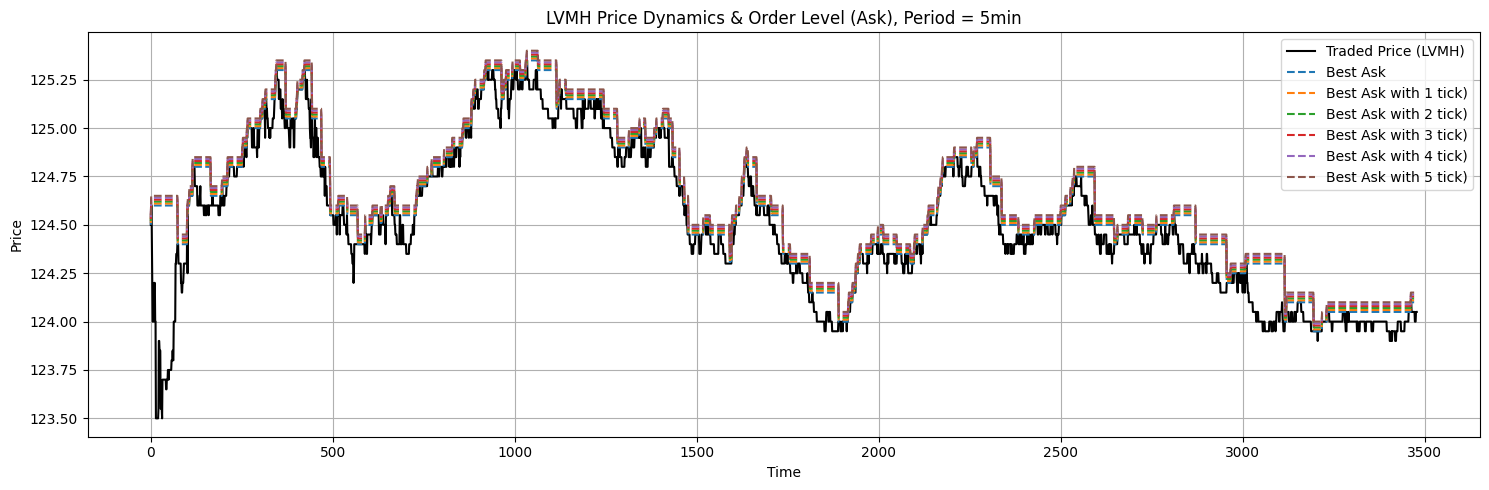

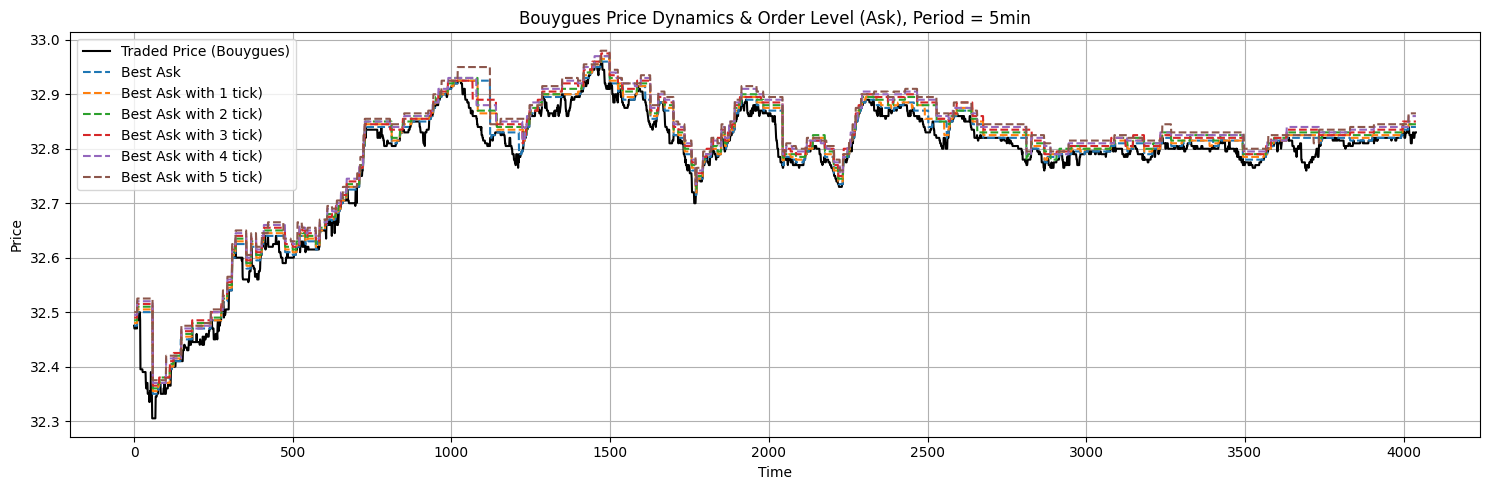

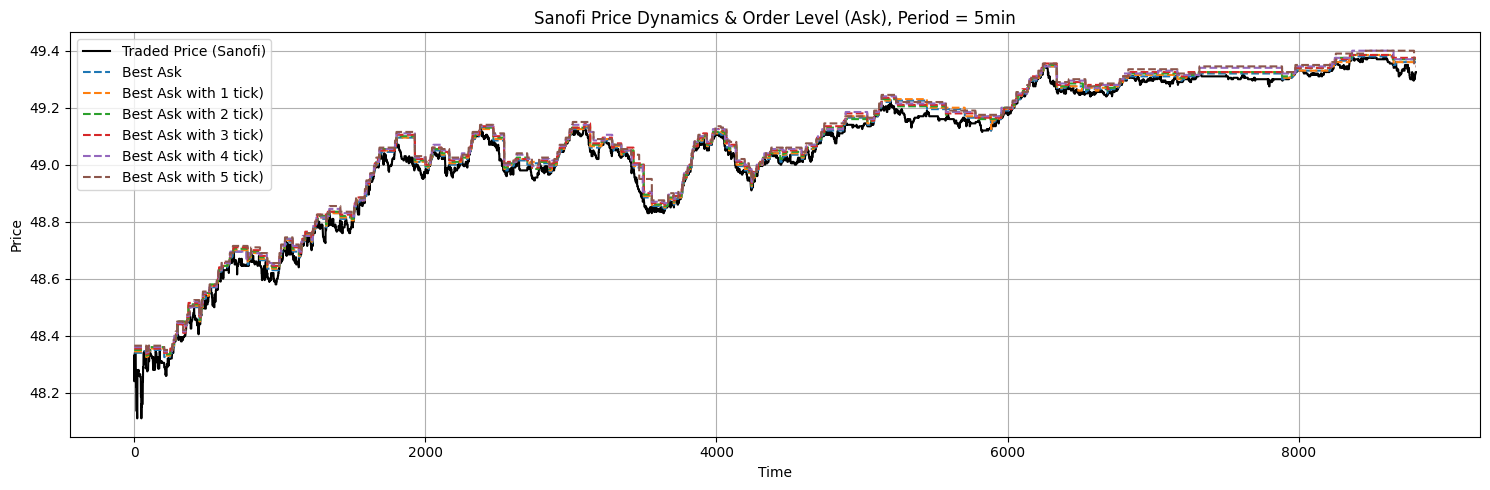

In [228]:
fillrate_at_distance (list_FR_name,list_FR,start_date,end_date,"5min",number_tests,"Ask", plot = True)

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2. Inventory and Market Making</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2.1 Inventory</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

## II. Inventory and Market Making

### 1. Inventory

* Volume obtained during the day using a liquidity seeking tactic
* Can be regarded as the integral of the fillrate over a period of time
* Thus it is dependent on the same parameters.


**Implementation**

a. Plot the inventory evolution $V$ of the previous strategy depending on $d$ and $t$ (cumulative fillrates).

b. Study the dependence of this inventory $V$ on volatility $\sigma$ and spread $S$.

c. Comment.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2.1.1 Inventory evolution according to $d$ and $t$</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### Exploring for each time horizon the inventory for a full week:

In [239]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8+24*4, minutes=30)

list_FR_US = list_FR + list_US
list_FR_US_name = list_FR_name+list_US_name
number_tests = 5
results_30_bid_inv, name_30_bid_inv =  fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"30min",number_tests,"Bid", plot=False,inventory_param =True, plot_vol_spread=False)
results_30_ask_inv, name_30_ask_inv = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"30min",number_tests,"Ask",plot=False,inventory_param =True, plot_vol_spread=False)

In [240]:
results_30_inv = merge_fillrate_tables(results_30_bid_inv, results_30_ask_inv)
print(f"\n--- {name_30_bid_inv} ---\n")
display(results_30_inv)


--- Inventory with a 30min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,219,245,355,548,720,1032,-1142,-798,-616,-404,-273,-245
1,LVMH,0.010,452,452,452,452,452,452,-373,-373,-373,-373,-373,-373
2,Bouygues,0.005,136,156,219,320,410,542,-550,-409,-320,-223,-145,-131
3,Sanofi,0.005,198,226,316,515,584,739,-890,-713,-612,-369,-265,-236
4,Google,0.005,308,307,307,333,333,333,-395,-395,-395,-351,-351,-341
5,Amazon,0.005,394,452,498,649,651,651,-687,-687,-687,-534,-483,-433
6,Apple,0.005,515,647,647,904,904,904,-1106,-1106,-1105,-759,-759,-583


In [241]:
results_15_bid_inv, name_15_bid_inv =fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"15min",number_tests,"Bid", plot=False,inventory_param =True, plot_vol_spread=False)
results_15_ask_inv, name_15_ask_inv =fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"15min",number_tests,"Ask",plot=False,inventory_param =True, plot_vol_spread=False)

In [242]:
results_15_inv = merge_fillrate_tables(results_15_bid_inv, results_15_ask_inv)
print(f"\n--- {name_15_bid_inv} ---\n")
display(results_15_inv)


--- Inventory with a 15min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,285,312,471,709,923,1318,-1470,-1033,-798,-515,-345,-313
1,LVMH,0.010,527,527,527,527,527,527,-461,-461,-461,-461,-461,-461
2,Bouygues,0.005,161,195,285,418,540,713,-775,-575,-445,-313,-200,-178
3,Sanofi,0.005,264,294,410,687,799,989,-1189,-931,-802,-479,-338,-302
4,Google,0.005,439,464,464,513,513,513,-561,-561,-561,-509,-509,-488
5,Amazon,0.005,545,620,674,893,895,895,-939,-939,-939,-711,-654,-584
6,Apple,0.005,678,859,859,1213,1214,1214,-1448,-1448,-1448,-1023,-1023,-781


In [243]:
results_5_bid_inv, name_5_bid_inv = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5min",number_tests,"Bid", plot=False,inventory_param =True, plot_vol_spread=False)
results_5_ask_inv, name_5_ask_inv = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5min",number_tests,"Ask",plot=False,inventory_param =True, plot_vol_spread=False)

In [244]:
results_5_inv = merge_fillrate_tables(results_5_bid_inv, results_5_ask_inv)
print(f"\n--- {name_5_bid_inv} ---\n")
display(results_5_inv)


--- Inventory with a 5min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,429,471,738,1146,1550,2180,-2279,-1616,-1199,-782,-506,-443
1,LVMH,0.010,763,763,763,763,763,763,-684,-684,-684,-684,-684,-684
2,Bouygues,0.005,211,258,409,646,850,1130,-1208,-874,-668,-430,-266,-235
3,Sanofi,0.005,358,420,603,999,1193,1506,-1744,-1359,-1142,-667,-448,-395
4,Google,0.005,688,753,753,835,835,835,-871,-871,-871,-781,-781,-725
5,Amazon,0.005,831,948,1025,1316,1319,1319,-1469,-1469,-1465,-1104,-1015,-903
6,Apple,0.005,1087,1395,1395,1945,1946,1946,-2191,-2191,-2189,-1553,-1553,-1197


In [245]:
results_1_bid_inv, name_1_bid_inv = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"1min",number_tests,"Bid", plot=False,inventory_param =True, plot_vol_spread=False)
results_1_ask_inv, name_1_ask_inv = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"1min",number_tests,"Ask",plot=False,inventory_param =True, plot_vol_spread=False)

In [246]:
results_1_inv = merge_fillrate_tables(results_1_bid_inv, results_1_ask_inv)
print(f"\n--- {name_1_bid_inv} ---\n")
display(results_1_inv)


--- Inventory with a 1min period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,501,609,1105,1906,2756,3857,-3925,-2740,-1947,-1118,-610,-510
1,LVMH,0.010,925,925,925,925,925,925,-854,-854,-854,-854,-854,-854
2,Bouygues,0.005,141,185,384,704,1067,1470,-1734,-1216,-820,-442,-234,-189
3,Sanofi,0.005,390,501,816,1578,1987,2536,-2774,-2126,-1681,-876,-524,-419
4,Google,0.005,1094,1236,1237,1431,1431,1431,-1341,-1341,-1340,-1177,-1177,-1084
5,Amazon,0.005,1401,1635,1809,2410,2413,2413,-2497,-2497,-2499,-1842,-1707,-1448
6,Apple,0.005,2007,2650,2651,3668,3670,3670,-3884,-3884,-3880,-2720,-2718,-2056


In [247]:
results_5s_bid_inv, name_5s_bid_inv  = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5s",number_tests,"Bid", plot=False,inventory_param =True, plot_vol_spread=False)
results_5s_ask_inv, name_5s_ask_inv = fillrate_at_distance (list_FR_US_name,list_FR_US,start_date,end_date,"5s",number_tests,"Ask",plot=False,inventory_param =True, plot_vol_spread=False)

In [248]:
results_5s_inv = merge_fillrate_tables(results_5s_bid_inv, results_5s_ask_inv)
print(f"\n--- {name_5s_bid_inv} ---\n")
display(results_5s_inv)


--- Inventory with a 5s period ---



,Security,Tick value,Best Bid - 5 ticks,Best Bid - 4 ticks,Best Bid - 3 ticks,Best Bid - 2 ticks,Best Bid - 1 ticks,Best Bid,Best Ask,Best Ask + 1 ticks,Best Ask + 2 ticks,Best Ask + 3 ticks,Best Ask + 4 ticks,Best Ask + 5 ticks
0,Total,0.005,158,243,657,1650,3114,4619,-4556,-3151,-1586,-678,-244,-153
1,LVMH,0.010,648,648,648,648,648,648,-588,-588,-588,-588,-588,-588
2,Bouygues,0.005,41,71,164,392,740,1082,-1532,-1051,-571,-244,-111,-79
3,Sanofi,0.005,143,221,469,1319,1974,2632,-2970,-2190,-1408,-545,-253,-177
4,Google,0.005,871,1013,1013,1225,1225,1225,-1172,-1172,-1172,-968,-968,-853
5,Amazon,0.005,1183,1488,1740,2604,2606,2606,-2681,-2681,-2680,-1747,-1530,-1206
6,Apple,0.005,2177,3227,3230,5035,5041,5041,-5096,-5096,-5093,-3233,-3233,-2206


In [249]:
dataframes = [
    (results_30_inv, "30 Minutes"),
    (results_15_inv, "15 Minutes"),
    (results_5_inv, "5 Minutes"),
    (results_1_inv, "1 Minute"),
    (results_5_inv, "5 Seconds")
]

times_values = build_and_display_asset_tables(dataframes, list_FR_US, results_30, "Inventory")

Inventory Total,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid -5 ticks,219,285,429,501,429
Best Bid -4 ticks,245,312,471,609,471
Best Bid -3 ticks,355,471,738,1105,738
Best Bid -2 ticks,548,709,1146,1906,1146
Best Bid -1 ticks,720,923,1550,2756,1550
Best Bid -0 ticks,1032,1318,2180,3857,2180
Best Ask +0 ticks,-1142,-1470,-2279,-3925,-2279
Best Ask +1 ticks,-798,-1033,-1616,-2740,-1616
Best Ask +2 ticks,-616,-798,-1199,-1947,-1199


Inventory Sanofi,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid -5 ticks,198,264,358,390,358
Best Bid -4 ticks,226,294,420,501,420
Best Bid -3 ticks,316,410,603,816,603
Best Bid -2 ticks,515,687,999,1578,999
Best Bid -1 ticks,584,799,1193,1987,1193
Best Bid -0 ticks,739,989,1506,2536,1506
Best Ask +0 ticks,-890,-1189,-1744,-2774,-1744
Best Ask +1 ticks,-713,-931,-1359,-2126,-1359
Best Ask +2 ticks,-612,-802,-1142,-1681,-1142


Inventory Apple,30 Minutes,15 Minutes,5 Minutes,1 Minute,5 Seconds
Tick Level,,,,,
Best Bid -5 ticks,515,678,1087,2007,1087
Best Bid -4 ticks,647,859,1395,2650,1395
Best Bid -3 ticks,647,859,1395,2651,1395
Best Bid -2 ticks,904,1213,1945,3668,1945
Best Bid -1 ticks,904,1214,1946,3670,1946
Best Bid -0 ticks,904,1214,1946,3670,1946
Best Ask +0 ticks,-1106,-1448,-2191,-3884,-2191
Best Ask +1 ticks,-1106,-1448,-2191,-3884,-2191
Best Ask +2 ticks,-1105,-1448,-2189,-3880,-2189


#### Final Comments:

We observe that the longer the time period considered, the more the inventory on the ask and bid sides tends to balance out (with total inventory tending toward zero). This suggests a significant mean-reversion phenomenon in inventories over the course of the week. Unsurprisingly, inventory levels are lower the further limit orders are placed from the best bid or ask. The fact that ask inventories are frequently higher than bid inventories suggests that this week has been rather bullish for the assets (European markets being highly correlated with U.S. markets).

Inventory quantities increase as the time window becomes smaller. However, there is a reduction when the period becomes too short, as orders are not executed and are frequently renewed, which reduces the number of trades executed. If the market maker's goal is to maximize turnover, it would be appropriate to calibrate the optimal time period accordingly.

As previously noted, the inventory levels for American assets are significantly higher than for French assets. This is consistent with the fact that limit orders are much more frequently executed for U.S. assets than for French ones, which naturally results in larger inventory holdings.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2.1.2 Inventory dependance according to $\sigma$ and the spread $S$ for french stock period = 5mn</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### Still for a full week:

In [250]:
result_spread_vol_bid, name_spread_vol_bid = fillrate_at_distance (list_FR_name,list_FR,start_date,end_date,"5min",number_tests,"Bid", plot=False,inventory_param =True, plot_vol_spread=True)


--- Inventory vs Volatility & Spread — Bid, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,Total,0,0.004749%,0.001939%,2.449,0.009695,0.010492,0.924,2180
1,Total,1,0.004325%,0.001882%,2.299,0.009871,0.010508,0.939,1550
2,Total,2,0.003657%,0.001828%,2.001,0.010006,0.010479,0.955,1146
3,Total,3,0.002962%,0.001715%,1.727,0.010234,0.010474,0.977,738
4,Total,4,0.002377%,0.001619%,1.469,0.010497,0.010480,1.002,471
5,Total,5,0.002162%,0.001609%,1.344,0.010591,0.010474,1.011,429



--- Inventory vs Volatility & Spread — Bid, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,LVMH,0,0.008888%,0.005673%,1.567,0.069611,0.069481,1.002,763
1,LVMH,1,0.008888%,0.005673%,1.567,0.069611,0.069481,1.002,763
2,LVMH,2,0.008888%,0.005673%,1.567,0.069611,0.069481,1.002,763
3,LVMH,3,0.008888%,0.005673%,1.567,0.069611,0.069481,1.002,763
4,LVMH,4,0.008888%,0.005673%,1.567,0.069611,0.069481,1.002,763
5,LVMH,5,0.008888%,0.005673%,1.567,0.069611,0.069481,1.002,763



--- Inventory vs Volatility & Spread — Bid, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,Bouygues,0,0.009802%,0.004651%,2.107,0.012990,0.013123,0.990,1130
1,Bouygues,1,0.009708%,0.004584%,2.118,0.013325,0.013079,1.019,850
2,Bouygues,2,0.009273%,0.004579%,2.025,0.013833,0.013101,1.056,646
3,Bouygues,3,0.008006%,0.004415%,1.813,0.014160,0.013081,1.082,409
4,Bouygues,4,0.007516%,0.004163%,1.805,0.015016,0.013076,1.148,258
5,Bouygues,5,0.007171%,0.004069%,1.762,0.015213,0.013003,1.170,211



--- Inventory vs Volatility & Spread — Bid, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,Sanofi,0,0.005220%,0.002232%,2.338,0.012778,0.013627,0.938,1506
1,Sanofi,1,0.004998%,0.002187%,2.286,0.013057,0.013634,0.958,1193
2,Sanofi,2,0.004771%,0.002171%,2.198,0.013339,0.013590,0.982,999
3,Sanofi,3,0.003871%,0.002048%,1.890,0.013784,0.013576,1.015,603
4,Sanofi,4,0.003639%,0.001967%,1.850,0.014260,0.013547,1.053,420
5,Sanofi,5,0.003536%,0.001915%,1.846,0.014372,0.013531,1.062,358


In [251]:
result_spread_vol_ask, name_spread_vol_ask = fillrate_at_distance (list_FR_name,list_FR,start_date,end_date,"5min",number_tests,"Ask", plot=False,inventory_param =True, plot_vol_spread=True)


--- Inventory vs Volatility & Spread — Ask, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,Total,0,0.004526%,0.001982%,2.284,0.009488,0.010356,0.916,-2279
1,Total,1,0.004197%,0.001884%,2.228,0.009702,0.010396,0.933,-1616
2,Total,2,0.003416%,0.001841%,1.855,0.009566,0.010428,0.917,-1199
3,Total,3,0.002791%,0.001742%,1.602,0.009870,0.010418,0.947,-782
4,Total,4,0.002329%,0.001618%,1.440,0.009854,0.010371,0.950,-506
5,Total,5,0.001923%,0.001604%,1.199,0.009769,0.010357,0.943,-443



--- Inventory vs Volatility & Spread — Ask, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,LVMH,0,0.009287%,0.005334%,1.741,0.067378,0.069213,0.973,-684
1,LVMH,1,0.009287%,0.005334%,1.741,0.067378,0.069213,0.973,-684
2,LVMH,2,0.009287%,0.005334%,1.741,0.067378,0.069213,0.973,-684
3,LVMH,3,0.009287%,0.005334%,1.741,0.067378,0.069213,0.973,-684
4,LVMH,4,0.009287%,0.005334%,1.741,0.067378,0.069213,0.973,-684
5,LVMH,5,0.009287%,0.005334%,1.741,0.067378,0.069213,0.973,-684



--- Inventory vs Volatility & Spread — Ask, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,Bouygues,0,0.008688%,0.004839%,1.795,0.011718,0.013095,0.895,-1208
1,Bouygues,1,0.008421%,0.004732%,1.779,0.012038,0.013063,0.922,-874
2,Bouygues,2,0.007638%,0.004715%,1.620,0.012110,0.013108,0.924,-668
3,Bouygues,3,0.006793%,0.004533%,1.499,0.012735,0.012994,0.980,-430
4,Bouygues,4,0.005629%,0.004331%,1.300,0.012935,0.013070,0.990,-266
5,Bouygues,5,0.005289%,0.004256%,1.243,0.013179,0.012991,1.014,-235



--- Inventory vs Volatility & Spread — Ask, 5min ---



,Security,Tick distance,Avg Vol (exec),Avg Vol (no exec),Ratio Vol exec / non-exec,Avg Spread (exec),Avg Spread (no exec),Ratio Spread exec / non-exec,Inventory
0,Sanofi,0,0.004830%,0.002330%,2.073,0.012778,0.013250,0.964,-1744
1,Sanofi,1,0.004586%,0.002287%,2.005,0.013245,0.013247,1.000,-1359
2,Sanofi,2,0.004361%,0.002221%,1.964,0.013462,0.013300,1.012,-1142
3,Sanofi,3,0.003289%,0.002079%,1.582,0.013519,0.013281,1.018,-667
4,Sanofi,4,0.002797%,0.001944%,1.439,0.014156,0.013261,1.067,-448
5,Sanofi,5,0.002591%,0.001931%,1.342,0.014282,0.013250,1.078,-395


#### Final Comments:

We first observe that executions tend to occur when volatility is higher than its average, with this ratio reaching up to 2.5. This ratio is also higher when the selected tick is closer to the best bid/ask, which paradoxically indicates that limit orders executed near the best are often done so during more volatile periods than those placed further away. This is likely due to the fact that distant orders require a certain “trend” in price to be reached before being hit, which is typically less volatile than a price that fluctuates rapidly and erratically around its mean.

The spread ratio is very close to 1, which is not surprising since we are observing highly liquid stocks.

Finally, we note that the higher the general and execution-related volatility, the higher the inventory levels. This corresponds to ticks that are closest to the best and ties back to the previous commentary on inventories. It thus becomes clear that there is a relationship between volatility and inventory. However, this relationship should be nuanced by considering both the proximity of the limit price to the best price, and the underlying price trend over the observed period.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2.2 Static Market Making</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### 2. Static Market Making

We consider now a market-maker using the same strategy as the agent before to buy and sell simultaneously stocks on the same market (then the distance is fixed over the day for both bid and ask sides, so it's a static strategy). We assume that at the beginning of the day the market-maker has an intial inventory $V_0 = 0$ stocks. Let $d_b$ and $d_a$ the posting distances for buying and selling respectively.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2.2.1 Static Market Making Inventory according to tick</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

**Implementation**

Let fix the duration to a few minutes (1, 5, 10, 15 or 30).

Study the inventory evolution regarding $d_b$ and $d_a$. What are the optimal $d_b$ and $d_a$ to have a stationary inventory for each duration ? (combination of the fillrates/inventory computed before).

In [6]:
def get_specific_LOB(data, tick_diff, direction,tick_value): 

    """
    Computes the price level at a given tick distance from the best bid or ask.

    Parameters
    ----------
    data: pd.DataFrame
          Single-row snapshot of LOB data.
    tick_diff: int
               Number of ticks away from the best price.
    direction: str
               'Bid' or 'Ask' side.
    tick_value: float
                Size of one tick for the asset.

    Returns
    -------
    float
        Target price level at the requested tick offset.
    """
    
    trade_price = data['TradedPrice'].iloc[0] # Use the traded price to adjust the best bid/ask safely
    if direction == "Bid": 
        # Take the minimum of trade price and quoted best bid
        best_bid = data['BidPrice'].iloc[0]
        best_bid = min(best_bid,trade_price)
        bid_level = best_bid - (tick_diff*tick_value)
        return bid_level
        
    elif direction == "Ask": 
        # Take the maximum of trade price and quoted best ask
        best_ask = data['AskPrice'].iloc[0]
        best_ask = max(best_ask,trade_price)
        ask_level = best_ask + (tick_diff*tick_value)
        return ask_level
 

def get_inventory (data, period, tick, direction,tick_ref):

    """
    Simulates limit order placement at a given tick level and computes executed inventory.

    Parameters
    ----------
    data: pd.DataFrame
          Time-indexed trade and quote data.
    period: str
            Lifespan of the simulated order (e.g., '1Min').
    tick: int
          Number of ticks from the best bid/ask to simulate.
    direction: str
               'Bid' or 'Ask' side to simulate.
    tick_ref: float
              Tick size of the asset.

    Returns
    -------
    inventory: np.ndarray
               Signed vector indicating execution quantity over time.
    """
    
    inventory = np.zeros(len(data), dtype=float) # Tracks signed volume
    i=0
    duration = pd.Timedelta(period) # Convert time window

    # Loop through all time steps
    while i <len(data) : 
        t0 = data.index[i] # Current timestamp
        snapshot = data.iloc[i] # Snapshot at time t0

        # Compute target price level for the simulated order
        target_price = get_specific_LOB(snapshot.to_frame().T, tick, direction, tick_ref) 
        j=i
        executed = False # Flag for whether the order gets filled

        # Scan forward until order expires or is executed
        while j < len(data) and data.index[j] - t0 <= duration:
            if direction == 'Bid': 

                # Best bid logic: strict execution condition
                if tick==0 : 
                    if data['TradedPrice'].iloc[j] < target_price:
                        inventory[j] += 1 # Buy executed
                        i=j
                        break
                else: 
                    if data['TradedPrice'].iloc[j] <= target_price:
                        inventory[j] += 1
                        i=j
                        break
                    
            elif direction == 'Ask': 
                # Best ask logic
                if tick ==0 : 
                    if data['TradedPrice'].iloc[j] > target_price:
                        inventory[j] += -1 # Sell executed
                        i=j
                        break
                else : 
                    if data['TradedPrice'].iloc[j] >= target_price:
                        inventory[j] += -1
                        i=j
                        break
            j+=1
        i=j # Move on to the next decision time
        
    return inventory

def compute_inventory (name_list,data_list,start_date,end_date,period,tick_bid, tick_ask): 

    """
    Computes the net inventory resulting from placing limit orders at specified distances
    from the best bid and ask over a time period.

    Parameters
    ----------
    name_list: list
               List of asset identifiers.
    data_list: list
               Corresponding list of price DataFrames for each asset.
    start_date: datetime
                Start of simulation window.
    end_date: datetime
              End of simulation window.
    period: str
            Duration of each simulated order.
    tick_bid: int
              Tick distance from best bid for bid-side simulation.
    tick_ask: int
              Tick distance from best ask for ask-side simulation.

    Returns
    -------
    None
        Displays a DataFrame summarizing inventory results.
    """
    
    tick_dict = {}
    data_dict =  {}
    final_results =[]

    # Loop over assets to filter and prepare their data
    for name, data in zip(name_list, data_list): 
        tick_dict[name] = get_tick(data['TradedPrice']) # Estimate tick size
        data=data.reset_index() # Flatten multi-index if needed
        data['Time'] = pd.to_datetime(data['Time']) # Ensure datetime format
        data = data[(data['Time'] >= start_date) & (data['Time'] < end_date)] # Filter window
        data = data.set_index("Time") # Use time as index again
        data_dict[name] = data

    # Now simulate inventory for each asset
    for name, data in data_dict.items():

        duration = pd.Timedelta(period)
        row = {'Security': name, 'Tick value':tick_dict[name]}

        # Simulate executions separately for bid and ask
        inventory_bid = get_inventory (data, period, tick_bid, "Bid",tick_dict[name])
        inventory_ask = get_inventory (data, period, tick_ask, "Ask",tick_dict[name])
        bid_sum = np.sum(inventory_bid)
        ask_sum = np.sum(inventory_ask)

        # Add bid-side results
        if tick_bid == 0 : 
            row[f'Best Bid'] = f"{bid_sum}"
        else : 
            row[f'Best Bid - {tick_bid} ticks'] = f"{bid_sum}"

        # Add ask-side results
        if tick_ask == 0 : 
            row[f'Best Ask'] = f"{ask_sum}"
        else : 
            row[f'Best Ask + {tick_ask} ticks'] = f"{ask_sum}"
        row[f'Total end inventory'] = f"{bid_sum + ask_sum}"  # Total net signed inventory = bid - ask
           
        final_results.append(row)

    # Convert to DataFrame for presentation
    final_results = pd.DataFrame(final_results)
    final_results['Inventory ratio'] = (final_results['Total end inventory'].map(float) / (final_results.iloc[:, 2].map(float)-final_results.iloc[:,3].map(float))).apply(lambda x: round(x, 2))
    final_results.name = f"Inventory with a {period} period"
    print(f"\n--- {final_results.name} ---\n")
    display(final_results)

### For a full week:

In [57]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8, minutes=30)

list_FR_US = list_FR + list_US
list_FR_US_name = list_FR_name+list_US_name
tick_bid = 0
tick_ask = 0
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"30min",tick_bid, tick_ask)
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"15min",tick_bid, tick_ask)
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"10min",tick_bid, tick_ask)
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"5min",tick_bid, tick_ask)
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"1min",tick_bid, tick_ask)


--- Inventory with a 30min period ---



,Security,Tick value,Best Bid,Best Ask,Total end inventory,Inventory ratio
0,Total,0.005,167.0,-199.0,-32.0,-0.09
1,LVMH,0.010,61.0,-57.0,4.0,0.03
2,Bouygues,0.005,73.0,-97.0,-24.0,-0.14
3,Sanofi,0.005,100.0,-240.0,-140.0,-0.41
4,Google,0.005,70.0,-107.0,-37.0,-0.21
5,Amazon,0.005,112.0,-184.0,-72.0,-0.24
6,Apple,0.005,183.0,-307.0,-124.0,-0.25



--- Inventory with a 15min period ---



,Security,Tick value,Best Bid,Best Ask,Total end inventory,Inventory ratio
0,Total,0.005,187.0,-245.0,-58.0,-0.13
1,LVMH,0.010,77.0,-67.0,10.0,0.07
2,Bouygues,0.005,111.0,-140.0,-29.0,-0.12
3,Sanofi,0.005,130.0,-272.0,-142.0,-0.35
4,Google,0.005,116.0,-141.0,-25.0,-0.10
5,Amazon,0.005,155.0,-251.0,-96.0,-0.24
6,Apple,0.005,273.0,-385.0,-112.0,-0.17



--- Inventory with a 10min period ---



,Security,Tick value,Best Bid,Best Ask,Total end inventory,Inventory ratio
0,Total,0.005,255.0,-296.0,-41.0,-0.07
1,LVMH,0.010,77.0,-82.0,-5.0,-0.03
2,Bouygues,0.005,135.0,-150.0,-15.0,-0.05
3,Sanofi,0.005,139.0,-314.0,-175.0,-0.39
4,Google,0.005,140.0,-155.0,-15.0,-0.05
5,Amazon,0.005,179.0,-277.0,-98.0,-0.21
6,Apple,0.005,318.0,-458.0,-140.0,-0.18



--- Inventory with a 5min period ---



,Security,Tick value,Best Bid,Best Ask,Total end inventory,Inventory ratio
0,Total,0.005,360.0,-371.0,-11.0,-0.02
1,LVMH,0.010,115.0,-96.0,19.0,0.09
2,Bouygues,0.005,163.0,-191.0,-28.0,-0.08
3,Sanofi,0.005,194.0,-364.0,-170.0,-0.30
4,Google,0.005,182.0,-186.0,-4.0,-0.01
5,Amazon,0.005,247.0,-332.0,-85.0,-0.15
6,Apple,0.005,429.0,-549.0,-120.0,-0.12



--- Inventory with a 1min period ---



,Security,Tick value,Best Bid,Best Ask,Total end inventory,Inventory ratio
0,Total,0.005,549.0,-562.0,-13.0,-0.01
1,LVMH,0.010,117.0,-114.0,3.0,0.01
2,Bouygues,0.005,191.0,-215.0,-24.0,-0.06
3,Sanofi,0.005,326.0,-512.0,-186.0,-0.22
4,Google,0.005,292.0,-285.0,7.0,0.01
5,Amazon,0.005,467.0,-588.0,-121.0,-0.11
6,Apple,0.005,785.0,-954.0,-169.0,-0.10


#### Comments:

In the static market-making with symmetric depth, the final inventory is not controlled a priori and relies essentially on a symmetry of the fillrate on the Bid and Ask sides.

We added a feature called inventory ratio which is the end inventory divided by the total traded volume (|ask| + |bid| inventory) to be able to compare what happens on different securities where the volumes were very different.

On average over the different securities, the absolute inventory ratio grows with the time period considered. It may produce portfolios that are closer to null-inventory on short periods (< 1min) for securities that had quite symmetric fillrates (Total, LVMH and Google here on 1 minute have the inventory ratio closest to 0) while the more asymmetric assets like Sanofi have a much bigger imbalance of -0.22 on 1 minute period that only worsens when we extend the order period up to 30 minutes.

In [58]:
tick_bid = 1
tick_ask = 1
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"30min",tick_bid, tick_ask)
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"15min",tick_bid, tick_ask) 
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"10min",tick_bid, tick_ask) 
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"5min",tick_bid, tick_ask) 
compute_inventory (list_FR_US_name,list_FR_US,start_date,end_date,"1min",tick_bid, tick_ask) 


--- Inventory with a 30min period ---



,Security,Tick value,Best Bid - 1 ticks,Best Ask + 1 ticks,Total end inventory,Inventory ratio
0,Total,0.005,113.0,-143.0,-30.0,-0.12
1,LVMH,0.010,61.0,-57.0,4.0,0.03
2,Bouygues,0.005,56.0,-75.0,-19.0,-0.15
3,Sanofi,0.005,76.0,-173.0,-97.0,-0.39
4,Google,0.005,70.0,-107.0,-37.0,-0.21
5,Amazon,0.005,112.0,-184.0,-72.0,-0.24
6,Apple,0.005,183.0,-307.0,-124.0,-0.25



--- Inventory with a 15min period ---



,Security,Tick value,Best Bid - 1 ticks,Best Ask + 1 ticks,Total end inventory,Inventory ratio
0,Total,0.005,127.0,-175.0,-48.0,-0.16
1,LVMH,0.010,77.0,-67.0,10.0,0.07
2,Bouygues,0.005,83.0,-110.0,-27.0,-0.14
3,Sanofi,0.005,104.0,-191.0,-87.0,-0.29
4,Google,0.005,116.0,-141.0,-25.0,-0.10
5,Amazon,0.005,155.0,-251.0,-96.0,-0.24
6,Apple,0.005,273.0,-385.0,-112.0,-0.17



--- Inventory with a 10min period ---



,Security,Tick value,Best Bid - 1 ticks,Best Ask + 1 ticks,Total end inventory,Inventory ratio
0,Total,0.005,182.0,-211.0,-29.0,-0.07
1,LVMH,0.010,77.0,-82.0,-5.0,-0.03
2,Bouygues,0.005,100.0,-112.0,-12.0,-0.06
3,Sanofi,0.005,107.0,-222.0,-115.0,-0.35
4,Google,0.005,140.0,-155.0,-15.0,-0.05
5,Amazon,0.005,179.0,-277.0,-98.0,-0.21
6,Apple,0.005,318.0,-458.0,-140.0,-0.18



--- Inventory with a 5min period ---



,Security,Tick value,Best Bid - 1 ticks,Best Ask + 1 ticks,Total end inventory,Inventory ratio
0,Total,0.005,250.0,-265.0,-15.0,-0.03
1,LVMH,0.010,115.0,-96.0,19.0,0.09
2,Bouygues,0.005,124.0,-134.0,-10.0,-0.04
3,Sanofi,0.005,150.0,-260.0,-110.0,-0.27
4,Google,0.005,182.0,-186.0,-4.0,-0.01
5,Amazon,0.005,247.0,-332.0,-85.0,-0.15
6,Apple,0.005,429.0,-549.0,-120.0,-0.12



--- Inventory with a 1min period ---



,Security,Tick value,Best Bid - 1 ticks,Best Ask + 1 ticks,Total end inventory,Inventory ratio
0,Total,0.005,398.0,-387.0,11.0,0.01
1,LVMH,0.010,117.0,-114.0,3.0,0.01
2,Bouygues,0.005,141.0,-149.0,-8.0,-0.03
3,Sanofi,0.005,243.0,-364.0,-121.0,-0.20
4,Google,0.005,292.0,-285.0,7.0,0.01
5,Amazon,0.005,467.0,-588.0,-121.0,-0.11
6,Apple,0.005,785.0,-954.0,-169.0,-0.10


#### Comments:

The observations are quite similar when we keep a symmetric limit order placement around the best bid and ask, with final inventory ratios that do not change much from the depth 0 placement on most timeframes.

#### Final Comments:

This strategy of static market making with symmetric posting does not produce in general a trading strategy with inventories close to zero at the end of the day. It gives to the market maker a directional exposure to the closing price of the security.

We should try to break this order posting asymmetry to reflect the fillrate asymmetry if we wish to produce a strategy with a smaller absolute inventory ratio at the end of the day for the market maker.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2.2.2 Optimal tick for end of period null inventory</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

In [3]:
def get_rows (name,eop_ratio,V0,last_price, tick, cb_opt, ca_opt, tick_bid_opti, tick_ask_opti, inv, PnL,PnL_latent, arg_type,liquidation_at_the_end) :

    """
    Builds one or two result rows summarizing strategy performance (PnL, inventory, etc.)
    depending on whether we're evaluating Both strategies, Vol-assessed only, or Static MM only.
    """

    # Handle case where both strategies (dynamic and static) are evaluated
    if arg_type == "Both": 
        inv_vol, inv_static = inv # Inventories from both strats
        PnL_vol, PnL_static = PnL # Final realized PnL
        eop_ratio_vol, eop_ratio_static = eop_ratio # Ratio of 0 inventory at end
        PnL_latent_vol, PnL_latent_static = PnL_latent # Unrealized PnL

        # If we force liquidation, latent PnL must be 0
        if liquidation_at_the_end:
            PnL_latent_vol, PnL_latent_static = "",""
        else : 
            PnL_latent_vol = f"{PnL_latent_vol:.2f}"
            PnL_latent_static = f"{PnL_latent_static:.2f}"

        # Row for dynamic MM strategy
        row1 = {
                "Security": f"{name} dynamic MM",
                "Tick value": f"{tick:.3f}",
                "cb_opti": f"{cb_opt:.2f}" ,
                "ca_opti": f"{ca_opt:.2f}" ,
                "TickBid Opti": "" ,
                "TickAsk Opti": "",
                "P&L": f"{PnL_vol:.2f}",
                "End Inv": f"{inv_vol[-1]:.2f}",
                "MtM End Inv": f"{inv_vol[-1]*last_price:.2f}",
                "Unrealized P&L": PnL_latent_vol,
                "Average Inv": f"{inv_vol.mean():.2f}",
                "Average Absolute Inv": f"{abs(inv_vol).mean():.2f}",
                "Max Inv Eop": f"{max(inv_vol.max(),V0):.0f}",
                "Min Inv Eop": f"{min(inv_vol.min(),V0):.0f}",
                "% Eop with Null Inv": f"{eop_ratio_vol*100:.2f}%",}

        # Row for static MM strategy
        row2 = {
                "Security": f"{name} static MM",
                "Tick value": f"{tick:.3f}",
                "cb_opti": "" ,
                "ca_opti": "" ,
                "TickBid Opti": f" - {tick_bid_opti} ticks" ,
                "TickAsk Opti": f" + {tick_ask_opti} ticks",
                "P&L": f"{PnL_static:.2f}",
                "End Inv": f"{inv_static[-1]:.2f}",
                "MtM End Inv": f"{inv_static[-1]*last_price:.2f}",
                "Unrealized P&L": PnL_latent_static,
                "Average Inv": f"{inv_static.mean():.2f}",
                "Average Absolute Inv": f"{abs(inv_static).mean():.2f}",
                "Max Inv Eop": f"{max(inv_static.max(),V0):.0f}",
                "Min Inv Eop": f"{min(inv_static.min(),V0):.0f}",
                "% Eop with Null Inv": f"{eop_ratio_static*100:.2f}%",}

        return row1, row2

    # If only dynamic MM is assessed
    elif arg_type == "Vol_assessed": 
        if liquidation_at_the_end:
            PnL_latent = ""
        else : 
            PnL_latent = f"{PnL_latent:.2f}"
        row = {
                "Security": f"{name} dynamic MM",
                "Tick value": f"{tick:.3f}",
                "cb_opti": f"{cb_opt:.3f}" ,
                "ca_opti": f"{ca_opt:.3f}" ,
                "TickBid Opti": "" ,
                "TickAsk Opti": "",
                "P&L": f"{PnL:.2f}",
                "End Inv": f"{inv[-1]:.2f}",
                "MtM End Inv": f"{inv[-1]*last_price:.2f}",
                "Unrealized P&L": PnL_latent,
                "Average Inv": f"{inv.mean():.2f}",
                "Average Absolute Inv": f"{abs(inv).mean():.2f}",
                "Max Inv Eop": f"{max(inv.max(),V0):.0f}",
                "Min Inv Eop": f"{min(inv.min(),V0):.0f}",
                "% Eop with Null Inv": f"{eop_ratio*100:.2f}%",}
        return row
        
    # If only static MM is assessed
    elif arg_type == "Static_MM": 
        if liquidation_at_the_end:
            PnL_latent = ""
        else : 
            PnL_latent = f"{PnL_latent:.2f}"
        row = {
                "Security": f"{name} static MM",
                "Tick value": f"{tick:.3f}",
                "cb_opti": "" ,
                "ca_opti": "" ,
                "TickBid Opti": f" - {tick_bid_opti} ticks" ,
                "TickAsk Opti": f" + {tick_ask_opti} ticks",
                "P&L": f"{PnL:.2f}",
                "End Inv": f"{inv[-1]:.2f}",
                "MtM End Inv": f"{inv[-1]*last_price:.2f}",
                "Unrealized P&L": PnL_latent,
                "Average Inv": f"{inv.mean():.2f}",
                "Average Absolute Inv": f"{abs(inv).mean():.2f}",
                "Max Inv Eop": f"{max(inv.max(),V0):.0f}",
                "Min Inv Eop": f"{min(inv.min(),V0):.0f}",
                "% Eop with Null Inv": f"{eop_ratio*100:.2f}%",}
        return row
        
def get_LOB_vol_or_tick_oriented(data,tick, vol,direction,cste,normalization, tick_value,vol_param):

    """
    Computes a limit price level based on either a fixed tick distance or
    a volatility-scaled tick offset, depending on the mode.

    Parameters
    ----------
    data: pd.DataFrame
          One-row snapshot of price data.
    tick: int
          Fixed tick offset (used if vol_param is False).
    vol: float
         Local volatility estimate (used if vol_param is True).
    direction: str
               'Bid' or 'Ask'.
    cste: float
          Coefficient used in volatility-based tick computation.
    normalization: float
                   Normalization constant to map vol to ticks.
    tick_value: float
                Tick size.
    vol_param: bool
               If True, use volatility-scaled logic. Otherwise, use tick directly.

    Returns
    -------
    price_level: float
                 Target price level for order.
    tick_diff: int
               Effective tick distance used (could be dynamic if vol_param is True).
    """

    if vol_param : 
        tick_diff =  int(round(cste*vol * normalization / tick_value)) # Convert volatility into an integer number of ticks (scaled)
    else : 
       tick_diff = tick # Use fixed tick
       
    trade_price = data['TradedPrice'].iloc[0]  # Use trade price to avoid crossing effects

    if direction == "Bid": 
        best_bid = data['BidPrice'].iloc[0]
        best_bid = min(best_bid,trade_price)
        bid_level = best_bid - (tick_diff*tick_value)

        return bid_level,tick_diff
        
    elif direction == "Ask": 
        
        best_ask = data['AskPrice'].iloc[0]
        best_ask = max(best_ask,trade_price)
        ask_level = best_ask + (tick_diff*tick_value)

        return ask_level,tick_diff
        
def precompute_vol_avg_vol(df,tick):

    """
    Precomputes squared log returns and volatility normalization constant,
    which maps average volatility to 1 tick size.

    Parameters
    ----------
    df: pd.DataFrame
        Market data containing 'TradedPrice'.
    tick: float
          Tick size for the asset.

    Returns
    -------
    df: pd.DataFrame
        Updated with log returns and cumulative sum of squared returns.
    normalization_cste: float
                        Ratio: 1 tick / average volatility.
    """
    
    df = df.copy()

    # Log-price and squared log-returns
    df['LogPrice'] = np.log(df['TradedPrice'])
    df['LogRetSq'] = df['LogPrice'].diff() ** 2
    df['LogRetSq'] = df['LogRetSq'].fillna(0)

    df['LogRetSqCumSum'] = df['LogRetSq'].cumsum() # Cumulative sum for fast rolling volatility access
    avg_vol = np.sqrt(df['LogRetSq'].mean()) # Mean volatility over the whole period
    
    normalization_cste = tick / avg_vol # Normalize: how many ticks corresponds to average volatility
    return df,normalization_cste
    
def get_vol(df, i, period_vol):

    """
    Computes local realized volatility for a window ending at index i.

    Parameters
    ----------
    df: pd.DataFrame
        Data with 'LogRetSqCumSum' column.
    i: int
       Current index.
    period_vol: str
                Time window (e.g. '5Min') to look backward.

    Returns
    -------
    vol: float
         Estimated local volatility at index i.
    """

    # Handle first tick edge case
    if i == 0 : 
        return 0 

    # Get current time and compute window start
    t_i = df.index[i]
    t_start = t_i - pd.Timedelta(period_vol)
    
    j = df.index.searchsorted(t_start, side='left') # Locate the first index after t_start

    # If start is outside data range or crosses days, fallback to whole window
    if t_start < df.index[0] or t_start.date() != t_i.date() or j == 0  : 
        return np.sqrt(df['LogRetSqCumSum'].iloc[i]/(i+1))
    else : 
         return np.sqrt((df['LogRetSqCumSum'].iloc[i] - df['LogRetSqCumSum'].iloc[j-1])/(i-j+1)) # Compute volatility over window [j, i]oui
    
def get_PnL_given_strat (data,tick,first_ilocs,first_ilocs_vol,cste,normalization, period, period_vol, direction,tick_ref,V0,vol_strat):

    """
    Simulates one side of the market making strategy (Bid or Ask),
    building inventory and price queue over time.

    Parameters
    ----------
    data: pd.DataFrame
          Tick-level market data.
    tick: int
          Fixed tick offset (ignored if vol_strat=True).
    first_ilocs: list of int
                 Indices of first rows per 'period'.
    first_ilocs_vol: list of int
                     Indices of first rows per 'period_vol'.
    cste: float
          Scaling constant for volatility-based placement.
    normalization: float
                   Normalization factor: 1 tick / avg volatility.
    period: str
            Holding time for each order.
    period_vol: str
                Lookback window for local volatility.
    direction: str
               'Bid' or 'Ask'.
    tick_ref: float
              Tick size of the asset.
    V0: int
        Initial inventory at time 0.
    vol_strat: bool
               Whether to use a volatility-based dynamic placement.

    Returns
    -------
    inventory: np.ndarray
               Time series of net inventory.
    price_queue: deque
                 FIFO queue of filled trades (signed price, timestamp).
    """
    
    inventory = np.zeros(len(data), dtype=float) # Track signed position over time
    i=0 # Index pointer
    duration = pd.Timedelta(period) # Order lifetime
    price_queue = deque() # Store price and timestamps of executed trades
    timestamp = data.index[0]

    # Init inventory if V0 ≠ 0
    if V0 >0 and direction=="Bid" :
        for _ in range(V0):
            price_queue.append((data['TradedPrice'].iloc[0],timestamp)) # Bought at market
    elif V0<0 and direction == "Ask": 
        for _ in range(abs(V0)):
            price_queue.append((-data['TradedPrice'].iloc[0],timestamp)) # Sold at market
            
    PnL=0. # Not used directly here

    # Loop through each timestamp
    while i <len(data) : 
        t0 = data.index[i] 
        snapshot = data.iloc[i]
        
        j=i

        # Get local volatility if enabled
        if vol_strat : 
            vol = get_vol(data, i,period_vol)
        else : 
            vol = 0 

        target_price,tick_diff = get_LOB_vol_or_tick_oriented(snapshot.to_frame().T,tick,vol, direction, cste,normalization, tick_ref,vol_strat) # Compute the target price and tick distance for this order
        
        executed = False 

        # Look ahead in time to simulate the life of the order
        while j < len(data) and data.index[j] - t0 <= duration:
            traded_price = data['TradedPrice'].iloc[j]
            timestamp = data.index[j]

            # Bid logic
            if direction == 'Bid' and (
                (tick_diff == 0 and traded_price < target_price) or
                (tick_diff > 0 and traded_price <= target_price)):
                inventory[j] += 1
                price_queue.append((target_price, timestamp)) # Buy at target
                i = j
                break
                
            # Ask logic
            elif direction == 'Ask' and (
                (tick_diff == 0 and traded_price > target_price) or
                (tick_diff > 0 and traded_price >= target_price)):
                inventory[j] -= 1
                price_queue.append((-target_price, timestamp)) # Sell at target
                i = j
                break

            j+=1
        i=j # Move pointer to next order
        
    return inventory, price_queue

def compute_Pnl (data, price_queue_bid, price_queue_ask, final_liquidation): 

    """
    Computes the realized and unrealized P&L by matching buy and sell orders
    in FIFO order and optionally liquidating remaining inventory.

    Parameters
    ----------
    data: pd.DataFrame
          Market data to get final price for liquidation.
    price_queue_bid: deque
                     Executed buy orders (positive prices).
    price_queue_ask: deque
                     Executed sell orders (negative prices).
    final_liquidation: bool
                       Whether to mark-to-market remaining inventory.

    Returns
    -------
    PnL: float
         Realized profit and loss from closed positions.
    latent_PnL: float
                Unrealized value of remaining inventory (MTM).
    """

    # Merge and sort all executed trades by time
    total_queue = list(price_queue_bid) + list(price_queue_ask)
    total_queue.sort(key=lambda x: x[1]) # Sort by timestamp

    last_prices = deque() # Queue of unmatched inventory (FIFO)
    PnL = 0

    # Match trades: +price = buy, -price = sell
    for price, _ in total_queue:
        if price > 0 : 
            if last_prices and last_prices[0] < 0 : # Match against earlier sell
                entry_price = - last_prices.popleft()
                PnL+= entry_price - price
            else : 
                last_prices.append(price)
        else : 
             if last_prices and last_prices[0] > 0: # Match against earlier buy
                entry_price = last_prices.popleft()
                PnL += -price - entry_price
             else:
                last_prices.append(price)

    # Handle unmatched trades (inventory) at final price
    latent_PnL = 0 
    final_price = data['TradedPrice'].iloc[-1]
    for price in last_prices:
        if price > 0:
            latent_PnL += final_price - price
        else:
            latent_PnL += -price - final_price
    return PnL,latent_PnL
    
def bid_ask_strat_to_optimize(cb,ca,tick_bid,tick_ask,normalization,data,period, period_vol,tick_value,V0, vol_strat,liquidation_at_the_end,weights, provide_data = False):

    """
    Runs a complete bid-ask market making strategy and evaluates its performance.

    Parameters
    ----------
    cb, ca: float
            Scaling constants for bid/ask in volatility mode.
    tick_bid, tick_ask: int
                        Fixed tick levels (for static strategy).
    normalization: float
                   Tick / avg volatility constant.
    data: pd.DataFrame
          Market data.
    period: str
            Order lifetime.
    period_vol: str
                Volatility computation window.
    tick_value: float
                Tick size.
    V0: int
        Starting inventory.
    vol_strat: bool
               Use volatility-based strategy if True, else static.
    liquidation_at_the_end: bool
                            Force zero inventory at end.
    weights: tuple
             Weights for optimization.
    provide_data: bool
                  If True, return raw simulation results.

    Returns
    -------
    Depends on mode. Either:
    - (inventory, queue_bid, queue_ask)
    - or (PnL, latent_PnL, eop_ratio, end_inv, inv_period)
    """
    
    df = data.copy()

    # Round timestamps to their corresponding execution/volatility buckets
    df['Period'] = df.index.floor(period)
    df['PeriodVol'] = df.index.floor(period_vol)
    
    df_reset = df.reset_index() # Reset index so we can use groupby with .head() (get first row of each period)
    
    first_ilocs = df_reset.groupby('Period').head(1).index.to_list() # Find the first row index of each "execution period"
    first_ilocs_vol = df_reset.groupby('PeriodVol').head(1).index.to_list()  # Same for "volatility periods" (rolling vol updates)
    inventory_bid, price_queue_bid = get_PnL_given_strat (data,tick_bid,first_ilocs,first_ilocs_vol,cb,normalization, period,period_vol, "Bid",tick_value,V0,vol_strat) # Run strategy on the bid side
    inventory_ask,price_queue_ask = get_PnL_given_strat (data,tick_ask,first_ilocs,first_ilocs_vol,ca,normalization, period,period_vol, "Ask",tick_value,V0,vol_strat) # Run strategy on the ask side

    inv = np.array(inventory_bid) + np.array(inventory_ask) # Net inventory at every time point = sum of Bid + Ask legs

    # For each period (e.g., every 5 min), compute cumulative inventory
    inv_period = [inv[first_ilocs[i]:first_ilocs[i+1]].sum() for i in range(len(first_ilocs) - 1)]
    inv_period.append(inv[first_ilocs[-1]:].sum())
    inv_period = np.array(inv_period).cumsum()

    if liquidation_at_the_end : 
        inv_period[-1] = 0 # For each period (e.g., every 5 min), compute cumulative inventory

    # Ratio of periods that ended flat (inventory == 0)
    eop_ratio = np.sum(inv_period == 0) / len(inv_period)
    
    if provide_data: 
        inv = inv.cumsum() # Reconstruct full inventory trajectory
        return inv, price_queue_bid, price_queue_ask
    else : 
        PnL, PnL_latent = compute_Pnl (df, price_queue_bid, price_queue_ask, liquidation_at_the_end)
        return PnL, PnL_latent, eop_ratio, inv_period[-1], inv_period # Return both realized and unrealized metrics
   
def manual_vol_grid_test(cb_values,ca_values,fixed_args,liquidation_at_the_end,name):

    """
    Performs a brute-force grid search on volatility-scaled bid/ask placement parameters (cb, ca),
    evaluating PnL, inventory behavior, and execution efficiency.

    Parameters
    ----------
    cb_values: list of float
               List of candidate coefficients for bid side (volatility-scaled).
    ca_values: list of float
               Same for ask side.
    fixed_args: tuple
                Arguments to pass to bid_ask_strat_to_optimize() (without cb, ca).
    liquidation_at_the_end: bool
                            If True, forces all inventory to be liquidated at the end.
    name: str
          Asset name (for logging/display purposes).

    Returns
    -------
    combi: list of (cb, ca)
           Grid combinations tested.
    PnL: list of float
         Final realized PnLs for each combination.
    eop: list of float
         End-of-period zero-inventory ratios.
    end_inv: list of float
             Final inventory levels (absolute).
    """
    
    grid = [(cb, ca) for cb in cb_values for ca in ca_values] # Create Cartesian grid of all (cb, ca) pairs
    PnL = []
    eop = []
    end_inv = []
    combi = []

    def evaluate(params):
        cb, ca = params
        PnL_test_pre,PnL_latent_test, eop_test, end_inv_test,_ = bid_ask_strat_to_optimize(cb, ca, *fixed_args) # Run the strategy with selected cb, ca and fixed args
        if liquidation_at_the_end: # If we liquidate, add the latent PnL to final realized PnL
            PnL_test=PnL_test_pre+PnL_latent_test
        else : PnL_test = PnL_test_pre

        return (cb, ca, PnL_test, eop_test, end_inv_test)

    # Multithreaded evaluation for performance
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(evaluate, params) for params in grid]
        for f in tqdm(as_completed(futures), total=len(futures), desc=f"Vol Assessed Grid Eval {name}"):
            cb, ca, pnl_val, eop_val, end_inv_val = f.result()
            combi.append((cb, ca))
            PnL.append(pnl_val)
            eop.append(eop_val)
            end_inv.append(end_inv_val)
    
    return combi, PnL, eop, end_inv

def manual_tick_grid_test(tick_bid_values, tick_ask_values, fixed_args,liquidation_at_the_end,name):

    """
    Performs a grid search over fixed tick distances for bid/ask placements,
    used for evaluating the static market making strategy.

    Parameters
    ----------
    tick_bid_values: list of int
                     List of candidate tick distances for the bid side.
    tick_ask_values: list of int
                     Same for the ask side.
    fixed_args: tuple
                Arguments to pass to bid_ask_strat_to_optimize() (excluding ticks).
    liquidation_at_the_end: bool
                            Whether to enforce inventory flattening at the end.
    name: str
          Name of the asset (for logging progress).

    Returns
    -------
    combi: list of (tick_bid, tick_ask)
           All tested combinations.
    PnL: list of float
         Realized profits for each pair.
    eop: list of float
         End-of-period ratios with zero inventory.
    end_inv: list of float
             Final signed inventory values.
    """
    
    grid = [(tb, ta) for tb in tick_bid_values for ta in tick_ask_values]
    PnL = []
    eop = []
    end_inv = []
    combi = []

    def evaluate(params):
        tick_bid, tick_ask = params
        PnL_test_pre, PnL_latent_test, eop_val, end_inv_val,_ = bid_ask_strat_to_optimize(0,0, tick_bid, tick_ask, *fixed_args) # Run the strategy with selected tick_bid, tick_ask and fixed args
        if liquidation_at_the_end: # If we liquidate, add the latent PnL to final realized PnL
            PnL_val=PnL_test_pre+PnL_latent_test
        else : 
            PnL_val = PnL_test_pre
        return (tick_bid, tick_ask, PnL_val, eop_val, end_inv_val)

    # Multithreaded evaluation for performance
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(evaluate, params) for params in grid]
        for f in tqdm(as_completed(futures), total=len(futures), desc=f"Tick Grid Eval {name}"):
            tick_bid, tick_ask, pnl_val, eop_val, end_inv_val = f.result()
            combi.append((tick_bid, tick_ask))
            PnL.append(pnl_val)
            eop.append(eop_val)
            end_inv.append(end_inv_val)

    return combi, PnL, eop, end_inv

def get_opti(combi_param, PnL_list, eop_list, end_inv_list, weights): 

    """
    Selects the optimal strategy configuration from a grid using a weighted
    score that balances PnL, inventory flatness, and inventory risk.

    Parameters
    ----------
    combi_param: list of tuples
                 Grid of parameters (e.g., [(cb, ca), ...] or [(tick_bid, tick_ask), ...]).
    PnL_list: list of float
              Profit and loss per combination.
    eop_list: list of float
              End-of-period zero-inventory ratios.
    end_inv_list: list of float
                  Final inventory levels (absolute).
    weights: tuple (w_pnl, w_end, w_eop)
             Optimization weights.

    Returns
    -------
    opti1, opti2: float or int
                  Optimal parameters (e.g., cb/ca or tick distances).
    """

    PnL_array = np.array(PnL_list)
    eop_array = np.array(eop_list)
    end_inv_array = np.abs(end_inv_list)  
    
    # Z-score normalization

    # Normalize PnL (maximize)
    if PnL_array.std() == 0 : 
        PnL_z = PnL_array
    else : 
        PnL_z = (PnL_array - PnL_array.mean()) / PnL_array.std()
        
    # Normalize EOP (maximize)
    if eop_array.std() == 0 : 
        eop_z = eop_array
    else : 
        eop_z = (eop_array - eop_array.mean()) / eop_array.std()

    # Normalize End Inventory (minimize)
    if end_inv_array.std() == 0 : 
        if end_inv_array.mean()==0 : 
            end_inv_z= np.zeros_like(end_inv_array)
        else : 
            end_inv_z = np.zeros_like(3.)
    else: 
        end_inv_z = np.array([(x - end_inv_array.mean()) / end_inv_array.std() if x != 0 else 0 for x in end_inv_array])

    # Weighted score
    w_pnl, w_end,w_eop = weights
    scores = w_pnl * PnL_z + w_eop * eop_z - w_end * end_inv_z

    best_idx = np.argmax(scores) # Select the best score
    opti1, opti2 = combi_param[best_idx] # Return the associated parameters for the best score
    return opti1, opti2

def compute_strategies (name_list,data_list,start_date,end_date,period,period_vol,V0,liquidation_at_the_end, what_to_evaluate,nb_points = (5,5),search_vol = 11 , weights=(1/3,1/3,1/3), plot=False, give_data=False): 

    """
    Master function that runs simulations for different market making strategies
    (volatility-based, tick-based, or both), performs grid search optimization,
    and optionally plots results and returns a summary DataFrame.

    Parameters
    ----------
    name_list: list
               List of asset identifiers (names).
    data_list: list
               List of pd.DataFrames containing tick data for each asset.
    start_date: datetime
                Beginning of the simulation window.
    end_date: datetime
              End of the simulation window.
    period: str
            Lifetime of each limit order (e.g. '1Min', '5Min').
    period_vol: str
                Lookback window used to compute local volatility (e.g. '5Min').
    V0: int
        Initial inventory at the start of simulation.
    liquidation_at_the_end: bool
                            If True, forces inventory to 0 at the final timestamp (liquidation).
    what_to_evaluate: str
                      Strategy type to evaluate: 'Both', 'Vol_assessed', or 'Static_MM'.
    nb_points: tuple
               Number of grid points for each strategy type (volatility-based, tick-based).
    search_vol: int
                Upper bound value for cb/ca in volatility grid search.
    weights: tuple
             Optimization weights for scoring (PnL, terminal inventory, eop ratio).
    plot: bool
          If True, plots inventory dynamics and execution trajectories.
    give_data: bool
               If True, give the data to reconstrct the PnL and the inventory (to be called for a single stock each time).
    Returns
    -------
    None
         Displays and prints a summary DataFrame with strategy outcomes.
    """
    
    tick_dict = {}
    data_dict =  {}
    final_results =[]

    # Process each asset's raw data
    for name, data in zip(name_list, data_list): 
        tick_dict[name] = get_tick(data['TradedPrice']) # Estimate tick size from price changes
        data.index = pd.to_datetime(data.index)  # Ensure datetime index
        data = data[(data.index >= start_date) & (data.index < end_date)] # Time filter
        data_dict[name] = data # Store filtered data
        


    for name, data in data_dict.items():
        
        data,normalization = precompute_vol_avg_vol(data, tick_dict[name]) # Get additional columns for the vol and the constant for vol_assessed strategy
        nb_points_vol, nb_points_tick  = nb_points
        cb_values = np.linspace(1, search_vol, nb_points_vol) # Volatility grid: bid side
        ca_values = np.linspace(1, search_vol, nb_points_vol) # Volatility grid: ask side
        tick_bid_values = np.arange(0, nb_points_tick, 1) # Tick grid: bid side
        tick_ask_values = np.arange(0, nb_points_tick, 1) # Tick grid: ask side
        last_price = data['TradedPrice'].iloc[-1]  # Final price for MtM valuation

        # === Evaluate both strategies: dynamic (vol) and static (tick) ===
        if what_to_evaluate == "Both": 

            # Grid search for volatility-based strategy
            fixed_args_vol = (0, 0, normalization, data, period, period_vol, tick_dict[name], V0, True, liquidation_at_the_end, weights)
            combi_vol, PnL_list_vol, eop_list_vol, end_inv_list_vol = manual_vol_grid_test(cb_values, ca_values, fixed_args_vol,liquidation_at_the_end,name)
            cb_opt,ca_opt = get_opti(combi_vol, PnL_list_vol, eop_list_vol, end_inv_list_vol, weights)

            # Simulate optimal volatility strategy
            PnL_vol,PnL_vol_final_latent, eop_ratio_vol,_,opti_inv_vol = bid_ask_strat_to_optimize(cb_opt,ca_opt,0,0,normalization,data,period, period_vol,tick_dict[name],V0, True,liquidation_at_the_end,weights)

            # Grid search for static (tick-based) strategy
            fixed_args_tick = (normalization, data, period, period_vol, tick_dict[name], V0, False, liquidation_at_the_end, weights)
            combi_tick, PnL_list_tick, eop_list_tick, end_inv_list_tick =  manual_tick_grid_test(tick_bid_values, tick_ask_values, fixed_args_tick,liquidation_at_the_end,name)
            tick_bid_opti,tick_ask_opti = get_opti(combi_tick, PnL_list_tick, eop_list_tick, end_inv_list_tick, weights)

            # Simulate optimal static strategy
            PnL_static,PnL_static_latent, eop_ratio_static,_,opti_inv_static= bid_ask_strat_to_optimize(0,0,tick_bid_opti,tick_ask_opti,normalization,data,period, period_vol,tick_dict[name],V0, False,liquidation_at_the_end,weights)

            # If liquidation is required, add latent PnL into realized
            if liquidation_at_the_end: 
                PnL_vol =PnL_vol+PnL_vol_final_latent
                PnL_vol_final_latent=0
                PnL_static=PnL_static+PnL_static_latent
                PnL_static_latent = 0
                
            row1,row2 = get_rows (name,(eop_ratio_vol,eop_ratio_static),V0, last_price, tick_dict[name], cb_opt, ca_opt, tick_bid_opti, tick_ask_opti, (opti_inv_vol,opti_inv_static), (PnL_vol, PnL_static), (PnL_vol_final_latent,PnL_static_latent),"Both",liquidation_at_the_end)
            final_results.append(row1)
            final_results.append(row2)

             # Optional visual output
            if plot: 
                inv_period_vol, price_queue_bid_vol, price_queue_ask_vol =bid_ask_strat_to_optimize(cb_opt,ca_opt,0,0,normalization,data,period, period_vol,tick_dict[name],V0, True,liquidation_at_the_end,weights,provide_data=True)
                inv_period_static, price_queue_bid_static, price_queue_ask_static=bid_ask_strat_to_optimize(0,0,tick_bid_opti,tick_ask_opti,normalization,data,period, period_vol,tick_dict[name],V0, False,liquidation_at_the_end,weights,provide_data=True)
                plot_strategy(data,period, period_vol, inv_period_vol, price_queue_bid_vol,price_queue_ask_vol, name, "Dynamic MM",weights,liquidation_at_the_end)
                plot_strategy(data,period, period_vol, inv_period_static, price_queue_bid_static,price_queue_ask_static, name, "Static MM",weights,liquidation_at_the_end)
            if give_data: 
                inv_period_vol, price_queue_bid_vol, price_queue_ask_vol =bid_ask_strat_to_optimize(cb_opt,ca_opt,0,0,normalization,data,period, period_vol,tick_dict[name],V0, True,liquidation_at_the_end,weights,provide_data=True)
                inv_period_static, price_queue_bid_static, price_queue_ask_static=bid_ask_strat_to_optimize(0,0,tick_bid_opti,tick_ask_opti,normalization,data,period, period_vol,tick_dict[name],V0, False,liquidation_at_the_end,weights,provide_data=True)
                return (data,period, period_vol, inv_period_vol, price_queue_bid_vol,price_queue_ask_vol, name, "Dynamic MM",weights,liquidation_at_the_end), (data,period, period_vol, inv_period_static, price_queue_bid_static,price_queue_ask_static, name, "Static MM",weights,liquidation_at_the_end)
                
        # === Evaluate only volatility-based strategy ===
        elif what_to_evaluate == "Vol_assessed":
            
            fixed_args_vol = (0, 0, normalization, data, period, period_vol, tick_dict[name], V0, True, liquidation_at_the_end, weights)
            combi_vol, PnL_list_vol, eop_list_vol, end_inv_list_vol = manual_vol_grid_test(cb_values, ca_values, fixed_args_vol,liquidation_at_the_end,name)
            cb_opt,ca_opt = get_opti(combi_vol, PnL_list_vol, eop_list_vol, end_inv_list_vol, weights)
            PnL_vol,PnL_vol_final_latent,eop_ratio_vol,_,opti_inv_vol = bid_ask_strat_to_optimize(cb_opt,ca_opt,0,0,normalization,data,period, period_vol,tick_dict[name],V0, True,liquidation_at_the_end,weights)
            if liquidation_at_the_end: 
                PnL_vol =PnL_vol+PnL_vol_final_latent
                PnL_vol_final_latent=0
            row = get_rows (name,eop_ratio_vol,V0,last_price,  tick_dict[name], cb_opt, ca_opt, 0, 0, opti_inv_vol, PnL_vol,PnL_vol_final_latent, "Vol_assessed",liquidation_at_the_end)
            final_results.append(row)
            if plot: 
                inv_period_vol, price_queue_bid_vol, price_queue_ask_vol =bid_ask_strat_to_optimize(cb_opt,ca_opt,0,0,normalization,data,period, period_vol,tick_dict[name],V0, True,liquidation_at_the_end,weights,provide_data=True)
                plot_strategy(data,period, period_vol, inv_period_vol, price_queue_bid_vol,price_queue_ask_vol, name, "Dynamic MM",weights,liquidation_at_the_end)
            if give_data: 
                 inv_period_vol, price_queue_bid_vol, price_queue_ask_vol =bid_ask_strat_to_optimize(cb_opt,ca_opt,0,0,normalization,data,period, period_vol,tick_dict[name],V0, True,liquidation_at_the_end,weights,provide_data=True)
                 return (data,period, period_vol, inv_period_vol, price_queue_bid_vol,price_queue_ask_vol, name, "Dynamic MM",weights,liquidation_at_the_end)
                
        # === Evaluate only static (tick-based) strategy ===
        elif what_to_evaluate == "Static_MM":
            
            fixed_args_tick = (normalization, data, period, period_vol, tick_dict[name], V0, False, liquidation_at_the_end, weights)
            combi_tick, PnL_list_tick, eop_list_tick, end_inv_list_tick =  manual_tick_grid_test(tick_bid_values, tick_ask_values, fixed_args_tick,liquidation_at_the_end,name)
            tick_bid_opti,tick_ask_opti = get_opti(combi_tick, PnL_list_tick, eop_list_tick, end_inv_list_tick, weights)
            PnL_static,PnL_static_latent,eop_ratio_static,_,opti_inv_static= bid_ask_strat_to_optimize(0,0,tick_bid_opti,tick_ask_opti,normalization,data,period, period_vol,tick_dict[name],V0, False,liquidation_at_the_end,weights)
            if liquidation_at_the_end: 
                PnL_static=PnL_static+PnL_static_latent
                PnL_static_latent = 0

            row = get_rows (name,eop_ratio_static,V0,last_price,  tick_dict[name], 0, 0, tick_bid_opti, tick_ask_opti, opti_inv_static, PnL_static,PnL_static_latent, "Static_MM",liquidation_at_the_end)
            final_results.append(row)
            if plot: 
                inv_period_static, price_queue_bid_static, price_queue_ask_static=bid_ask_strat_to_optimize(0,0,tick_bid_opti,tick_ask_opti,normalization,data,period, period_vol,tick_dict[name],V0, False,liquidation_at_the_end,weights,provide_data=True)
                plot_strategy(data,period, period_vol, inv_period_static, price_queue_bid_static,price_queue_ask_static, name, "Static MM",weights, liquidation_at_the_end)
            if give_data: 
                inv_period_static, price_queue_bid_static, price_queue_ask_static=bid_ask_strat_to_optimize(0,0,tick_bid_opti,tick_ask_opti,normalization,data,period, period_vol,tick_dict[name],V0, False,liquidation_at_the_end,weights,provide_data=True)
                return (data,period, period_vol, inv_period_static, price_queue_bid_static,price_queue_ask_static, name, "Static MM",weights, liquidation_at_the_end)
                
    # === Final output formatting and display ===
    final_results = pd.DataFrame(final_results)
    criterias = 476
    if liquidation_at_the_end: 
        if what_to_evaluate=="Both": 
            final_results.name = f"Comparaison vol_assessed and static MM strategy with V0 = {V0}, period = {period}, vol_period = {period_vol}, final_liquidation = {liquidation_at_the_end} and weights = {weights}"
        else :
            final_results.name = f"{what_to_evaluate} with V0 = {V0}, period = {period}, vol_period = {period_vol}, final_liquidation = {liquidation_at_the_end} and weights = {weights}"
    else : 
        if what_to_evaluate=="Both": 
            final_results.name = f"Comparaison vol_assessed and static MM strategy with V0 = {V0}, period = {period}, vol_period = {period_vol}, final_liquidation = {liquidation_at_the_end} and weights = {weights}"
        else :
            final_results.name = f"{what_to_evaluate} with V0 = {V0}, period = {period}, vol_period = {period_vol}, final_liquidation = {liquidation_at_the_end} and weights = {weights}"

    print(f"\n--- {final_results.name} ---\n")
    display(
    final_results.style.set_properties(**{
        'text-align': 'center'
    }).set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]} 
    ])
    )

In [4]:
def get_vol(df, i, period_vol):

    """
    Computes realized volatility over a backward-looking window ending at index i.

    Parameters
    ----------
    df: pd.DataFrame
        DataFrame with precomputed LogRetSqCumSum column.
    i: int
        Index at which volatility is measured.
    period_vol: str
                Rolling volatility window (e.g., '5Min').

    Returns
    -------
    vol: float
         Realized volatility over the backward window.
    """
    
    if i == 0 : 
        return 0  # Cannot compute vol at first index
    t_i = df.index[i]
    t_start = t_i - pd.Timedelta(period_vol)
    j = df.index.searchsorted(t_start, side='left') # Find index j such that df.index[j] ≈ t_start

    # Edge case: start time is before available data or crosses date boundary
    if t_start < df.index[0] or t_start.date() != t_i.date() or j == 0  : 
        return np.sqrt(df['LogRetSqCumSum'].iloc[i]/(i+1))
    else : 
         return np.sqrt((df['LogRetSqCumSum'].iloc[i] - df['LogRetSqCumSum'].iloc[j-1])/(i-j+1)) # Otherwise, compute diff of cumulated squared returns over window [j, i]

def get_tick (prices, decimal_precision=6) : 

    """
    Estimates the minimum price increment (tick size) using observed price changes.

    Parameters
    ----------
    prices: pd.Series
            Time-indexed traded price series.
    decimal_precision: int
                       Number of decimal digits used to convert float prices to integers.

    Returns
    -------
    tick: float
          Estimated tick size based on greatest common divisor of non-zero deltas.
    """
    
    deltas = prices.diff().abs().dropna() # Compute absolute differences between successive prices
    deltas = deltas[deltas > 0] # Remove zeros (which would disrupt GCD)

    # Scale differences into integers
    scale = 10**decimal_precision
    scaled_deltas = (deltas * scale).round().astype(int)
    tick_int = reduce(gcd, scaled_deltas) # Get the GCD of all scaled price changes

    # Convert back to float space
    tick = tick_int / scale
    return tick

def plot_strategy(df,period, period_vol, inv, price_queue_bid,price_queue_ask, name, strat,weights, liquidation_at_the_end):

    """
    Visual diagnostic for market making strategy: shows price evolution, volatility,
    inventory, realized/unrealized PnL and order executions.

    Parameters
    ----------
    df: pd.DataFrame
        Tick data with columns like 'TradedPrice'.
    period: str
            Limit order lifetime (e.g., '1Min').
    period_vol: str
                Window for volatility estimation.
    inv: list or ndarray
         Cumulative inventory values per timestamp.
    price_queue_bid: deque
                     Buy-side executed orders (positive prices).
    price_queue_ask: deque
                     Sell-side executed orders (negative prices).
    name: str
          Asset name (for title).
    strat: str
           Strategy type ('Static MM', 'Dynamic MM').
    weights: tuple
             Optimization weights used in grid search.
    liquidation_at_the_end: bool
                            If True, closes inventory at final timestamp (adds PnL).
    """

    # Initialize 4-panel plot: Price | Volatility | Inventory | PnL
    fig, axs = plt.subplots(1, 4, figsize=(25, 5), sharex=True)
    fig.suptitle(f"{strat} on {name} with period = {period}, vol_period = {period_vol}, "
                 f"final_liquidation = {liquidation_at_the_end} and weights = {weights}",
                 fontsize=14, fontweight='bold')

    # ==== PANEL 1: Traded price ====
    axs[0].plot(df.index, df['TradedPrice'], label='Traded Price')
    axs[0].set_title("Traded Price")
    axs[0].grid(True)
    axs[0].legend()

    # ==== PANEL 2: Rolling Volatility + Execution points ====

    unique_index = [i for i in range(1,len(df)) if df.index[i] != df.index[i-1]]  # Filter for unique timestamps to avoid duplicate index values (due to resets)

    # Compute realized volatility at those points
    rolling_vol_values = [get_vol(df, i, period_vol) for i in unique_index]
    rolling_vol_index = [df.index[i] for i in unique_index]
    rolling_vol = pd.Series(rolling_vol_values, index=rolling_vol_index)

    # Extract timestamps for executed trades
    buy_times = [timestamp for price, timestamp in price_queue_bid if price > 0]
    sell_times = [timestamp for price, timestamp in price_queue_ask if price < 0]

    # If forced liquidation: append execution at end
    if liquidation_at_the_end: 
        if inv[-1] >0: 
            inv[-1] = 0
            buy_times.append(df.index[-1])
        else : 
            sell_times.append(df.index[-1])
            
    # Plot rolling volatility curve        
    axs[1].plot(rolling_vol.index, rolling_vol, label=f'Rolling Volatility every {period_vol}', color='green')

    # Match volatility values to execution times for Buy orders
    buy_y = [rolling_vol[ts] for ts in buy_times if ts in rolling_vol.index]
    buy_x = [ts for ts in buy_times if ts in rolling_vol.index]
    axs[1].scatter(buy_x, buy_y, color='red', marker='x', label='Buy order')
    
    # Same for Sell orders
    sell_y = [rolling_vol[ts] for ts in sell_times if ts in rolling_vol.index]
    sell_x = [ts for ts in sell_times if ts in rolling_vol.index]
    axs[1].scatter(sell_x, sell_y, color='blue', marker='x', label='Sell order')
    axs[1].set_title("Volatility & Trades")
    axs[1].grid(True)
    axs[1].legend()

    # ==== PANEL 3: Inventory path ====
    inventory_series = pd.Series(inv, index=df.index)
    axs[2].plot(df.index, inventory_series, color='purple')
    axs[2].set_title("Inventory")
    axs[2].grid(True)

    # ==== PANEL 4: PnL dynamics ====
    total_queue = sorted(list(price_queue_bid) + list(price_queue_ask), key=lambda x: x[1])  
    #Step 1: merge + sort all trades by execution timestamp
    last_prices = deque()
    pnl_values = []
    timestamps = []
    PnL=0

    # Step 2: simulate LIFO-style execution to pair buys/sells
    for price, ts in total_queue:
        if price > 0 : # Buy
            if last_prices and last_prices[0] < 0 : # Match against a pending sell 
                entry_price = - last_prices.popleft()
                PnL+= entry_price - price
            else : 
                last_prices.append(price)
        else : 
             if last_prices and last_prices[0] > 0: # Match against pending buy
                entry_price = last_prices.popleft()
                PnL += -price - entry_price
             else:
                last_prices.append(price)
        timestamps.append(ts)
        pnl_values.append(PnL)

    pnl_series = pd.Series(pnl_values, index=pd.to_datetime(timestamps)) # Convert PnL to time series aligned on timestamps
    pnl_series = pnl_series.groupby(pnl_series.index).last() # Remove duplicates — keep last PnL per timestamp
    
    pnl_series = pnl_series.reindex(df.index, method='ffill').fillna(0) # Align with df.index to fill entire timeline 

    # Step 3: Compute remaining latent PnL (open inventory)
    latent_PnL = 0 
    final_price = df['TradedPrice'].iloc[-1]
    for price in last_prices:
        if price > 0:
            # On vend au dernier prix
            latent_PnL += final_price - price
        else:
            # On rachète au dernier prix
            latent_PnL += -price - final_price

    # Step 4: Plot realized + unrealized PnL
    if liquidation_at_the_end : 
        pnl_series.iloc[-1] +=latent_PnL
        axs[3].plot(pnl_series.index, pnl_series, label="Realized P&L", color='blue')
    else : 
        axs[3].plot(pnl_series.index, pnl_series, label="Realized P&L", color='blue')
        axs[3].plot([pnl_series.index[-1]], [pnl_series.iloc[-1] + latent_PnL], marker='o', color='red', label="Unrealized P&L")
        axs[3].plot([pnl_series.index[-1], pnl_series.index[-1]],[pnl_series.iloc[-1], pnl_series.iloc[-1] + latent_PnL],linestyle='--', color='red')
    axs[3].set_title("Cumulative P&L")
    axs[3].grid(True)
    axs[3].legend()

    # === Formatting X-axis across all panels ===
    xtick_locs = np.linspace(0, len(df.index) - 1, 8, dtype=int)
    xtick_labels = [df.index[i].strftime('%Y-%m-%d %H:%M') for i in xtick_locs]
    for ax in axs:
        ax.set_xticks(df.index[xtick_locs])
        ax.set_xticklabels(xtick_labels, rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.92]) # Adjust layout to fit title
    plt.show()

### In this first part, the optimizer only tries to minimize the absolute end of period inventory (for a full week).

In [8]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8+24*4, minutes=30)

compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","0min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Static_MM", nb_points = (1,11),search_vol = 10, weights=(0.,0,1), plot=False)

Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [15:43<00:00,  7.80s/it]



--- Static_MM with V0 = 0, period = 15min, vol_period = 0min, final_liquidation = False and weights = (0.0, 0, 1) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total static MM,0.005,,,- 6 ticks,+ 7 ticks,18.74,8.00,329.80,-0.64,-4.71,7.45,10,-28,7.65%
1,LVMH static MM,0.010,,,- 6 ticks,+ 6 ticks,-83.39,44.00,5258.00,-16.76,29.65,29.95,65,-5,2.94%
2,Bouygues static MM,0.005,,,- 9 ticks,+ 9 ticks,4.32,-14.00,-457.80,0.96,-6.64,6.76,2,-17,11.76%
3,Sanofi static MM,0.005,,,- 5 ticks,+ 10 ticks,49.13,118.00,5872.86,-61.12,40.82,42.27,118,-10,5.29%
4,Google static MM,0.005,,,- 3 ticks,+ 3 ticks,-32.69,-45.00,-27739.80,-86.91,-30.70,32.61,19,-93,3.08%
5,Amazon static MM,0.005,,,- 2 ticks,+ 4 ticks,-12.34,239.00,44322.55,-57.27,35.08,62.63,242,-89,3.08%
6,Apple static MM,0.005,,,- 5 ticks,+ 7 ticks,63.20,50.00,16813.50,147.45,8.00,36.11,87,-53,1.54%


In [9]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"5min","0min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Static_MM", nb_points = (1,11),search_vol = 10, weights=(0.,0,1), plot=False)

Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [16:28<00:00,  8.17s/it]



--- Static_MM with V0 = 0, period = 5min, vol_period = 0min, final_liquidation = False and weights = (0.0, 0, 1) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total static MM,0.005,,,- 10 ticks,+ 10 ticks,6.67,-2.00,-82.45,0.17,-6.19,6.52,4,-17,6.27%
1,LVMH static MM,0.010,,,- 0 ticks,+ 2 ticks,-174.17,79.00,9440.50,-21.55,62.38,62.94,130,-13,1.57%
2,Bouygues static MM,0.005,,,- 8 ticks,+ 9 ticks,8.75,6.00,196.20,-0.01,1.95,2.83,13,-5,18.63%
3,Sanofi static MM,0.005,,,- 6 ticks,+ 7 ticks,-15.81,21.00,1045.17,-3.30,-7.57,14.19,22,-33,3.73%
4,Google static MM,0.005,,,- 3 ticks,+ 4 ticks,327.86,-28.00,-17260.32,-12.88,0.91,20.52,62,-57,2.05%
5,Amazon static MM,0.005,,,- 7 ticks,+ 9 ticks,-60.74,56.00,10385.20,38.03,-1.94,21.96,80,-62,4.36%
6,Apple static MM,0.005,,,- 8 ticks,+ 10 ticks,37.35,45.00,15132.15,114.86,11.15,31.33,102,-66,1.28%


In [10]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"1min","0min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Static_MM", nb_points = (1,11),search_vol = 10, weights=(0.,0,1), plot=False)

Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [21:28<00:00, 10.65s/it]



--- Static_MM with V0 = 0, period = 1min, vol_period = 0min, final_liquidation = False and weights = (0.0, 0, 1) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total static MM,0.005,,,- 9 ticks,+ 9 ticks,10.09,4.00,164.90,-0.13,-0.92,3.27,8,-8,6.70%
1,LVMH static MM,0.010,,,- 0 ticks,+ 7 ticks,-763.69,667.00,79706.50,-334.80,320.98,321.05,669,-4,0.43%
2,Bouygues static MM,0.005,,,- 10 ticks,+ 9 ticks,3.22,-25.00,-817.50,2.18,-8.57,8.66,1,-25,31.70%
3,Sanofi static MM,0.005,,,- 9 ticks,+ 9 ticks,-1.99,-1.00,-49.77,0.14,-7.06,7.59,3,-15,6.07%
4,Google static MM,0.005,,,- 9 ticks,+ 7 ticks,107.90,-62.00,-38219.28,-62.90,-15.34,17.58,21,-62,1.95%
5,Amazon static MM,0.005,,,- 9 ticks,+ 10 ticks,-23.09,56.00,10385.20,8.85,-7.08,22.00,63,-53,2.13%
6,Apple static MM,0.005,,,- 3 ticks,+ 5 ticks,922.01,595.00,200080.65,1443.39,275.93,283.58,642,-71,1.03%


#### Final Comments:

In this configuration, the strategy is entirely constrained by the end-of-period inventory objective (weights = (0., 0, 1)), with no consideration for P&L or inventory smoothing throughout the session. The behavior that emerges is closely linked to the execution frequency and reveals a clear tendency to avoid execution when possible.

At high execution frequencies (e.g. 1-minute), the optimizer frequently sets tick values to the maximum bounds of the search grid (±9 or ±10), especially for stocks like Bouygues, Sanofi, or Google. This reflects an intentional strategy to avoid trading: by quoting far from the mid-price, the model satisfies the formal requirement of placing orders while minimizing the likelihood of being executed. The strategy effectively uses the high frequency to wait passively and only engage with the market when price movements are extreme and favorable.

At lower frequencies (e.g. 15 minutes), tick values remain wide but are generally less extreme. The strategy has fewer opportunities to delay, and thus shows a slightly greater willingness to execute. However, the resulting executions are still insufficient to consistently reduce exposure.

This behavior is confirmed by the "% EOP with Null Inventory" metric. A high value indicates that the strategy regularly ends execution intervals with a flat inventory, showing effective inventory control. In most of the results, however, this percentage remains very low—typically below 5%—suggesting that the strategy holds positions most of the time, despite being constrained to reduce them by the end. For instance, Apple with a 1-minute period shows only 1.03% of flat intervals, even though it ends with a substantial long position (+595). Bouygues is one of the few exceptions, with over 30% of flat intervals and more moderate inventory levels.

This illustrates the limits of a strategy guided solely by end-of-period inventory. The optimizer often exploits its flexibility by avoiding engagement with the market rather than actively managing risk through trading. As a result, end inventories remain large, mark-to-market exposure is high, and unrealized P&L can be significant.

Overall, the strategy respects the letter of the constraint but not its practical spirit. Introducing urgency near the session end, adjusting ticks dynamically based on inventory trajectory, or combining this constraint with partial P&L incentives would likely produce more consistent and effective behavior.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3. Dynamical Market Making</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

* Realtime reassessments
* Dynamical inventory
* Use market indicators to compute the posting distance


**Implementation** 

Let fix the duration $t$ (a few minutes: 1, 5, 10, 15 or 30).

a. Set the posting distances $d_b$ and $d_a$ as functions of the intraday volatility : $d_{b,t} = c_b\sigma_t$ and $d_{a,t}=c_a\sigma_t$. Determine the optimal constants $c_b$ and $c_a$ to have a stationary inventory with $V_0=0$. 

b. Plot on the same graph the evolutions of inventory, price and volatility for the optimal values of $c_b$ and $c_a$. Comment.

c. What is the dependency of the optimal strategy regarding the initial inventory $V_0$ (positive or negative) ?

d. Propose other intraday parameters which could be used to optimize the posting price. Justify your choice. 


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3.1 Strategy according to the market maker profile</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### Investor profile and MM utility

**The utility function we use is a weighted average of three different losses: the standardized P&L of the strategy, the standardized absolute end inventory after the total period for the trades considered (1 day, 1 week etc) and the End-Of-Period zero-inventory ratio (it counts at the end of each few minutes period wether the current inventory is 0 or not).**

The tuple of three numbers used below to designate investor profiles is the weight put on each one of those three losses, mirroring the specific aversions of the market maker.

When discussing the P&L of the strategies a posteriori after having done the experiment for an investor profile, we mean the sum of the aggregated P&L of the closed positions and the unrealized P&L corresponding to the End-Of-Day inventory liquidated at the last trade price of the considered trading period.

To resume for a profile (0.2,0.5,0.3), the market maker has preferences quantified as : 
- 20% to have a high P&L
- 50% to have no inventory at the end of the strategy
- 30% to have zero inventory every period within the strategy (period to take back the undone limit order and place another one)

**All the other plot and dataframe take place within a single day.**

### Equally weighted - (1/3,1/3,1/3)

In [12]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8, minutes=30)

In [12]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8, minutes=30)

compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"30min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"5min","5min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"1min","1min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=False)

Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [09:49<00:00,  2.62s/it]



--- Vol_assessed with V0 = 0, period = 30min, vol_period = 30min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.643,2.286,,,5.09,7.00,283.46,0.00,3.65,12.94,31,-23,5.88%
1,LVMH dynamic MM,0.010,3.571,2.929,,,10.05,6.00,744.30,0.03,-2.06,3.59,6,-9,17.65%
2,Bouygues dynamic MM,0.005,8.071,10.000,,,0.28,2.00,65.66,0.12,-0.88,1.47,2,-4,29.41%
3,Sanofi dynamic MM,0.005,2.929,5.500,,,4.58,2.00,98.65,0.05,2.47,6.35,18,-8,17.65%
4,Google dynamic MM,0.005,2.286,9.357,,,-15.40,-7.00,-4230.31,-2.21,-17.38,17.38,0,-34,7.69%
5,Amazon dynamic MM,0.005,2.929,8.714,,,-49.01,0.00,0.00,0.00,-30.46,30.46,0,-56,7.69%
6,Apple dynamic MM,0.005,6.143,10.000,,,-14.39,1.00,329.72,0.93,-23.00,23.15,1,-43,7.69%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [08:01<00:00,  2.14s/it]



--- Vol_assessed with V0 = 0, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



...


--- Vol_assessed with V0 = 0, period = 5min, vol_period = 5min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,10.000,10.000,,,0.95,-5.00,-202.47,0.49,-3.76,4.06,2,-11,14.71%
1,LVMH dynamic MM,0.010,6.786,6.143,,,10.63,2.00,248.10,0.28,-3.96,4.73,6,-13,12.87%
2,Bouygues dynamic MM,0.005,10.000,10.000,,,-0.15,-1.00,-32.83,-0.02,-0.42,0.97,2,-3,31.37%
3,Sanofi dynamic MM,0.005,4.214,8.714,,,4.70,21.00,1035.83,0.58,4.18,5.67,21,-6,14.71%
4,Google dynamic MM,0.005,6.786,8.071,,,-8.99,12.00,7251.96,13.96,-1.90,9.05,22,-27,11.54%
5,Amazon dynamic MM,0.005,1.643,6.786,,,-65.49,69.00,12711.18,-17.51,-0.50,28.32,69,-47,6.41%
6,Apple dynamic MM,0.005,3.571,7.429,,,-95.34,66.00,21761.52,59.70,2.27,31.47,92,-64,7.69%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [12:18<00:00,  3.28s/it]



--- Vol_assessed with V0 = 0, period = 1min, vol_period = 1min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,9.357,10.000,,,0.76,3.00,121.48,-0.08,-2.38,3.00,4,-8,16.07%
1,LVMH dynamic MM,0.010,8.714,9.357,,,0.55,4.00,496.20,0.33,-1.93,2.65,6,-9,25.93%
2,Bouygues dynamic MM,0.005,7.429,8.714,,,-0.24,-2.00,-65.66,-0.02,0.81,1.16,4,-2,32.11%
3,Sanofi dynamic MM,0.005,6.143,10.000,,,0.32,11.00,542.58,-0.02,-0.89,2.21,11,-7,17.19%
4,Google dynamic MM,0.005,4.857,4.857,,,-11.43,7.00,4230.31,4.76,-0.59,11.82,32,-39,6.78%
5,Amazon dynamic MM,0.005,5.500,10.000,,,-63.95,57.00,10500.54,-8.30,1.47,22.75,58,-40,4.64%
6,Apple dynamic MM,0.005,6.143,8.714,,,-61.79,54.00,17804.88,24.36,-1.46,24.21,68,-50,3.33%


#### Comments:

In the equally weighted case, the optimal strategies struggle to reach a positive P&L on all the US securities while it's producing small, positive, P&L on the French securities.

On longer time horizons (15 and 30 minutes), we observe that the optimization yields an average inventory significantly higher on the US securities than the French ones, which may explain some additional directional exposure in the opposite direction of markets leading to negative P&L. Moreover, the same observation holds for the average absolute inventory that implies directional exposure at all times.

The coefficients are frequently being pushed near the boundary 10 for the search of optimal $c_{b}$ and $c_{a}$ which tries to push the orders far from the best ask/bid to limit excess inventory, this end-of-period constraint on short time horizons makes the algorithm struggle to know wether it should try to sell or buy more, it displays the lack of asymmetry in the strategy design.

Here also, we had some weight on the zero-EOP-inventory ratio which prevent the strategy to hold for long time stocks and wait to make P&L. We will see how performance changes when we move weight out of this variable.

### Aggressive - (0.8,0.2,0)

In this case, we disregard the zero End-Of-Period rate and focus on optimizing mostly the P&L with a small penality of 20% on the End inventory.

In [ ]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"30min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"5min","5min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"1min","1min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=False)

Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [06:45<00:00,  1.80s/it]



--- Vol_assessed with V0 = 0, period = 30min, vol_period = 30min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,8.03,14.00,566.93,-0.35,9.82,14.53,38,-15,0.00%
1,LVMH dynamic MM,0.010,5.500,1.643,,,16.38,-1.00,-124.05,0.01,-8.88,8.88,0,-16,0.00%
2,Bouygues dynamic MM,0.005,1.000,2.286,,,1.54,1.00,32.83,0.07,-5.00,5.59,2,-16,11.76%
3,Sanofi dynamic MM,0.005,1.000,4.857,,,7.91,5.00,246.62,0.08,6.47,8.71,24,-5,0.00%
4,Google dynamic MM,0.005,2.286,10.000,,,-15.44,-6.00,-3625.98,-1.55,-16.77,16.92,1,-33,0.00%
5,Amazon dynamic MM,0.005,4.214,10.000,,,-40.89,-5.00,-921.10,4.34,-28.46,28.46,0,-51,0.00%
6,Apple dynamic MM,0.005,6.786,10.000,,,-14.22,-1.00,-329.72,-0.02,-23.77,23.77,0,-43,0.00%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [09:32<00:00,  2.55s/it]



--- Vol_assessed with V0 = 0, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



...


--- Vol_assessed with V0 = 0, period = 5min, vol_period = 5min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.929,,,22.17,86.00,3482.57,0.47,50.49,50.55,87,-2,0.00%
1,LVMH dynamic MM,0.010,6.143,2.929,,,22.15,-14.00,-1736.70,4.35,-18.50,18.50,0,-28,0.99%
2,Bouygues dynamic MM,0.005,1.000,9.357,,,2.38,111.00,3644.13,1.18,50.92,50.92,111,0,0.00%
3,Sanofi dynamic MM,0.005,1.000,4.857,,,16.33,37.00,1825.03,1.97,18.19,18.58,43,-4,3.92%
4,Google dynamic MM,0.005,2.929,2.929,,,1.51,2.00,1208.66,1.52,-9.19,12.09,15,-34,1.28%
5,Amazon dynamic MM,0.005,8.071,10.000,,,-29.64,-15.00,-2763.30,4.14,-36.82,36.82,0,-58,0.00%
6,Apple dynamic MM,0.005,7.429,10.000,,,-54.84,6.00,1978.32,3.56,-24.10,29.00,26,-59,0.00%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [14:40<00:00,  3.92s/it]



--- Vol_assessed with V0 = 0, period = 1min, vol_period = 1min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,33.65,132.00,5345.34,-6.24,72.64,72.74,133,-3,0.60%
1,LVMH dynamic MM,0.010,5.500,2.286,,,18.60,-25.00,-3101.25,6.79,-24.17,24.17,0,-34,0.25%
2,Bouygues dynamic MM,0.005,1.000,10.000,,,2.88,122.00,4005.26,1.18,58.56,58.56,122,0,0.00%
3,Sanofi dynamic MM,0.005,1.000,4.214,,,30.57,90.00,4439.25,7.73,45.72,45.72,90,0,0.00%
4,Google dynamic MM,0.005,8.071,8.071,,,-5.94,7.00,4230.31,4.82,-3.57,10.42,25,-34,2.71%
5,Amazon dynamic MM,0.005,2.929,2.929,,,-19.10,-76.00,-14000.72,15.46,-91.11,91.13,3,-124,0.26%
6,Apple dynamic MM,0.005,1.000,10.000,,,28.12,451.00,148703.72,174.02,206.10,206.50,458,-12,0.00%


#### Comments:

First of all, we clearly observe the absence of a constraint on the End of Period inventory, which leads the algorithm to favor strategies that hold positions for longer periods, as these are more conducive to generating P&L. The light constraint regarding end-of-day inventory works well for longer timeframes but less so for shorter ones, where some strategies end the day with a significant inventory.

However, this strategy manages to generate positive P&L, even if it involves liquidating the inventory at the end. We do note, however, that French stocks over the 30-minute period tend to end the day with almost no remaining inventory and still deliver positive P&L.

The adjustment variables used for tick selection are sometimes pushed to their extremes by the algorithm (e.g., Apple, Amazon, Google). This is due to the price dynamics on that specific day, which drive the algorithm to avoid over-selling when prices are falling, by trying to minimize the probability that the order gets executed. If we were to expand the range of these parameters, it's likely that these extreme values would still be selected.

We also observe that some strategies are unidirectional in their inventory, i.e., they are always short or always long. This is related to how the algorithm is built—it looks into the future, performs backtesting, and outputs the best parameters, thus taking advantage of price trends.

### Cautious but risk taker - (0.6,0.2,0.2)

We now considered a more diversified profile, looking for P&L with an attention to the risk taken. 

In [18]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"30min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"5min","5min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"1min","1min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False)

Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:44<00:00,  2.06s/it]



--- Vol_assessed with V0 = 0, period = 30min, vol_period = 30min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,8.03,14.00,566.93,-0.35,9.82,14.53,38,-15,0.00%
1,LVMH dynamic MM,0.010,6.143,2.929,,,16.08,-3.00,-372.15,0.81,-8.06,8.06,0,-17,5.88%
2,Bouygues dynamic MM,0.005,1.000,2.286,,,1.54,1.00,32.83,0.07,-5.00,5.59,2,-16,11.76%
3,Sanofi dynamic MM,0.005,2.929,5.500,,,4.58,2.00,98.65,0.05,2.47,6.35,18,-8,17.65%
4,Google dynamic MM,0.005,2.286,9.357,,,-15.40,-7.00,-4230.31,-2.21,-17.38,17.38,0,-34,7.69%
5,Amazon dynamic MM,0.005,2.929,8.714,,,-49.01,0.00,0.00,0.00,-30.46,30.46,0,-56,7.69%
6,Apple dynamic MM,0.005,6.143,10.000,,,-14.39,1.00,329.72,0.93,-23.00,23.15,1,-43,7.69%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [10:00<00:00,  2.67s/it]



--- Vol_assessed with V0 = 0, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



...


--- Vol_assessed with V0 = 0, period = 5min, vol_period = 5min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.929,,,22.17,86.00,3482.57,0.47,50.49,50.55,87,-2,0.00%
1,LVMH dynamic MM,0.010,6.786,6.143,,,10.63,2.00,248.10,0.28,-3.96,4.73,6,-13,12.87%
2,Bouygues dynamic MM,0.005,10.000,10.000,,,-0.15,-1.00,-32.83,-0.02,-0.42,0.97,2,-3,31.37%
3,Sanofi dynamic MM,0.005,1.643,6.143,,,12.09,54.00,2663.55,8.57,24.26,24.44,54,-2,10.78%
4,Google dynamic MM,0.005,7.429,9.357,,,-5.83,10.00,6043.30,11.97,-3.24,8.55,19,-27,10.26%
5,Amazon dynamic MM,0.005,1.643,6.786,,,-65.49,69.00,12711.18,-17.51,-0.50,28.32,69,-47,6.41%
6,Apple dynamic MM,0.005,3.571,7.429,,,-95.34,66.00,21761.52,59.70,2.27,31.47,92,-64,7.69%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [12:23<00:00,  3.31s/it]



--- Vol_assessed with V0 = 0, period = 1min, vol_period = 1min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,33.65,132.00,5345.34,-6.24,72.64,72.74,133,-3,0.60%
1,LVMH dynamic MM,0.010,8.714,9.357,,,0.55,4.00,496.20,0.33,-1.93,2.65,6,-9,25.93%
2,Bouygues dynamic MM,0.005,7.429,8.714,,,-0.24,-2.00,-65.66,-0.02,0.81,1.16,4,-2,32.11%
3,Sanofi dynamic MM,0.005,6.143,10.000,,,0.32,11.00,542.58,-0.02,-0.89,2.21,11,-7,17.19%
4,Google dynamic MM,0.005,4.857,4.857,,,-11.43,7.00,4230.31,4.76,-0.59,11.82,32,-39,6.78%
5,Amazon dynamic MM,0.005,5.500,10.000,,,-63.95,57.00,10500.54,-8.30,1.47,22.75,58,-40,4.64%
6,Apple dynamic MM,0.005,6.143,8.714,,,-61.79,54.00,17804.88,24.36,-1.46,24.21,68,-50,3.33%


#### Comments:

This strategy is interesting because it provides good control over the end-of-period inventory due to the constant monitoring carried out on the inventory at EOP. However, as previously discussed, these constraints somewhat reduce the P&L, and in some cases may even make it highly negative (particularly in the case of U.S. assets).

The control over the end inventory becomes less effective as the considered trading period gets shorter, which is consistent. Furthermore, we continue to observe the presence of extreme values in the parameters related to the directional positions taken by the strategy in relation to the price, in an attempt to profit from its fluctuations - this remains a limitation of the algorithm.

#### Final Comments:

The faith in such a model for market making depends heavily on the venues considered, the robustness of the caracteristics of the strategies on French securities for different profiles gives more faith in the feasability of this more simplistic market making model while the large fluctuations on US securities for small changes in investor profile makes such a parameter estimation less likely to remain effective.

The volatility scaling of the depth at which we place orders does not account for all the variability in the optimal strategies here. The failure of keeping a proper imbalance tries to be mitigated by scaling the volatility with extreme factors to reduce the trading activity while we should be using more appropriate features to reduce the volume without reducing your exposure to trading.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3.2 Few strategies plot</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Vol Assessed Grid Eval Total: 100%|██████████████████████████████████████████████████| 225/225 [02:54<00:00,  1.29it/s]


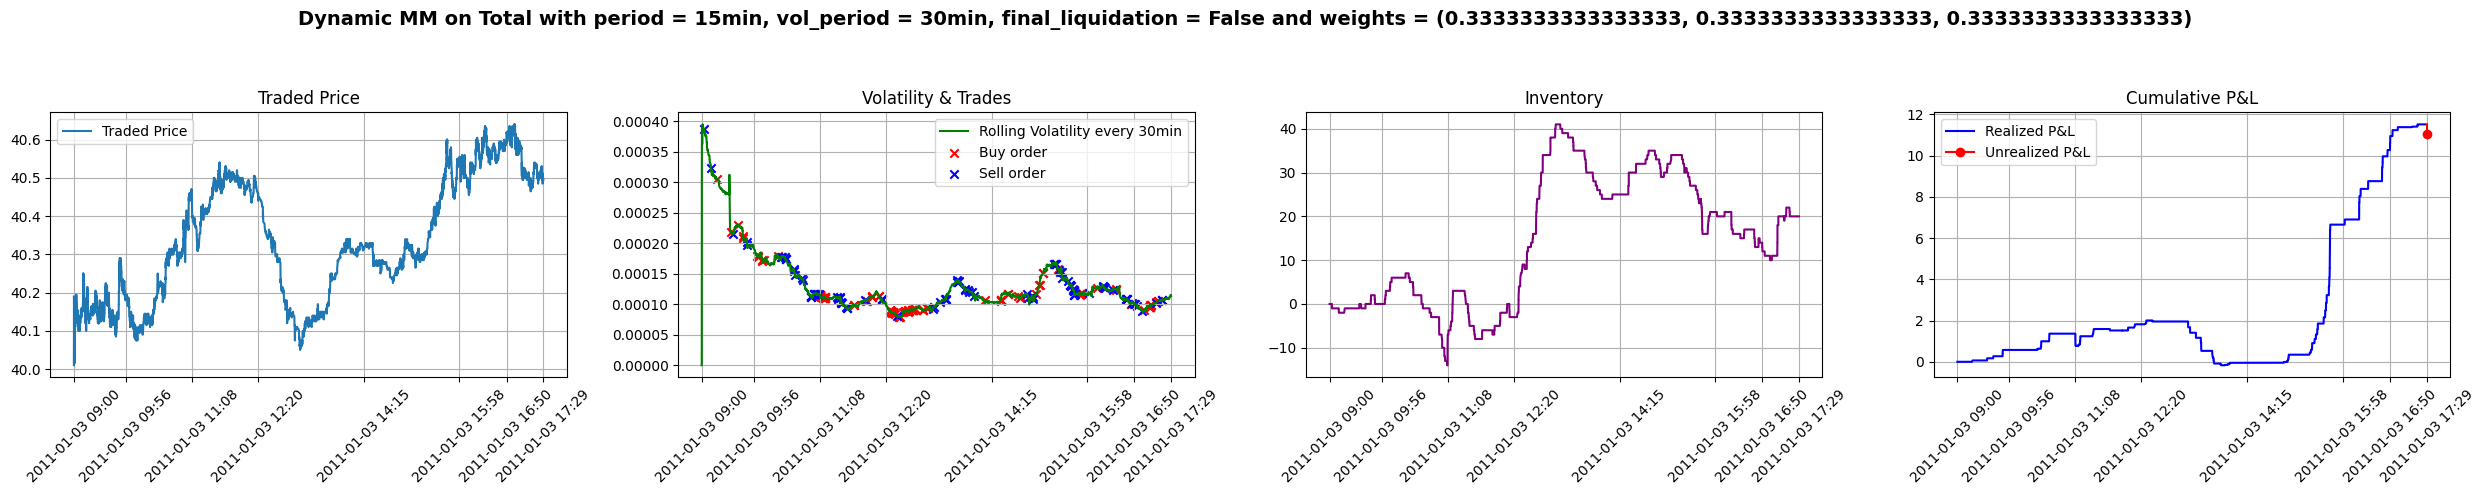


--- Vol_assessed with V0 = 0, period = 15min, vol_period = 30min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.643,2.929,,,11.52,20.00,809.90,-0.46,14.76,16.18,39,-8,8.82%


In [8]:
compute_strategies (['Total'],[total],start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=True)

#### Comments:

While the End of Period inventory constraint is significant at the start of the day, the algorithm is subsequently driven by the P&L (which is nonexistent when starting with near-zero inventory) to purchase large quantities, which it then liquidates due to the upward price trend. This results in a large end-of-day inventory, but the unrealized P&L (i.e., if liquidated at the end) is not particularly negative, as the stocks were bought when prices were still low. This clearly shows how the parameters become biased due to their ability to "look into the future," which is problematic.

Vol Assessed Grid Eval LVMH: 100%|███████████████████████████████████████████████████| 225/225 [01:30<00:00,  2.49it/s]


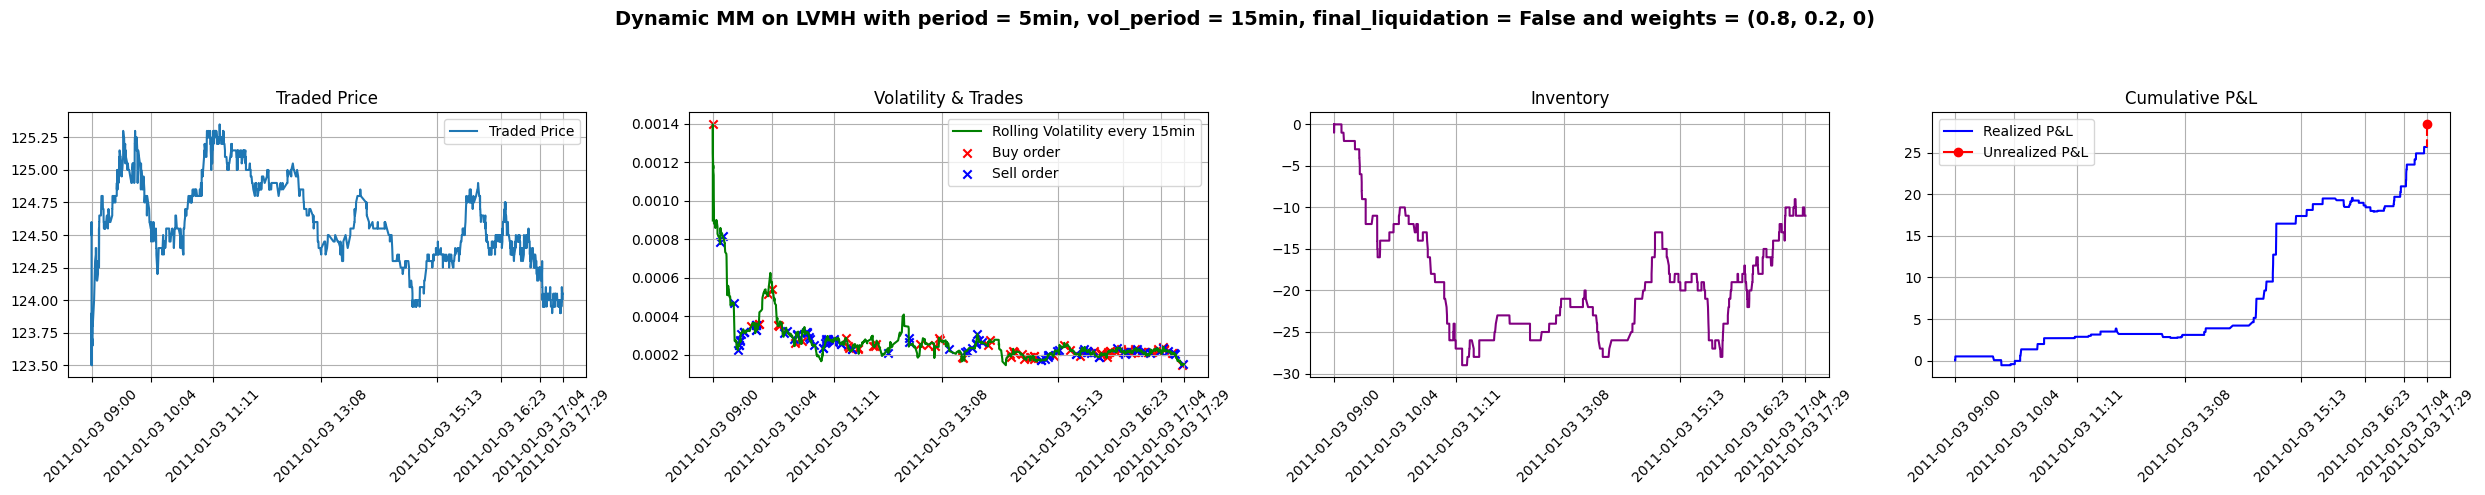


--- Vol_assessed with V0 = 0, period = 5min, vol_period = 15min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,LVMH dynamic MM,0.010,6.143,4.214,,,25.71,-11.00,-1364.55,2.72,-18.93,18.93,0,-29,0.99%


In [9]:
compute_strategies (['LVMH'],[lvmh],start_date,end_date,"5min","15min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=True)

#### Comments:

As expected for this type of investor profile, it is the appeal of P&L that drives the strategy, leading it to pay little attention to the end-inventory constraint. The strategy thus becomes directional and takes advantage of the stock’s decline over the day, resulting in a strong directional exposure by the end of the trading day—an outcome we do not necessarily want.

Vol Assessed Grid Eval Bouygues: 100%|███████████████████████████████████████████████| 225/225 [02:51<00:00,  1.31it/s]


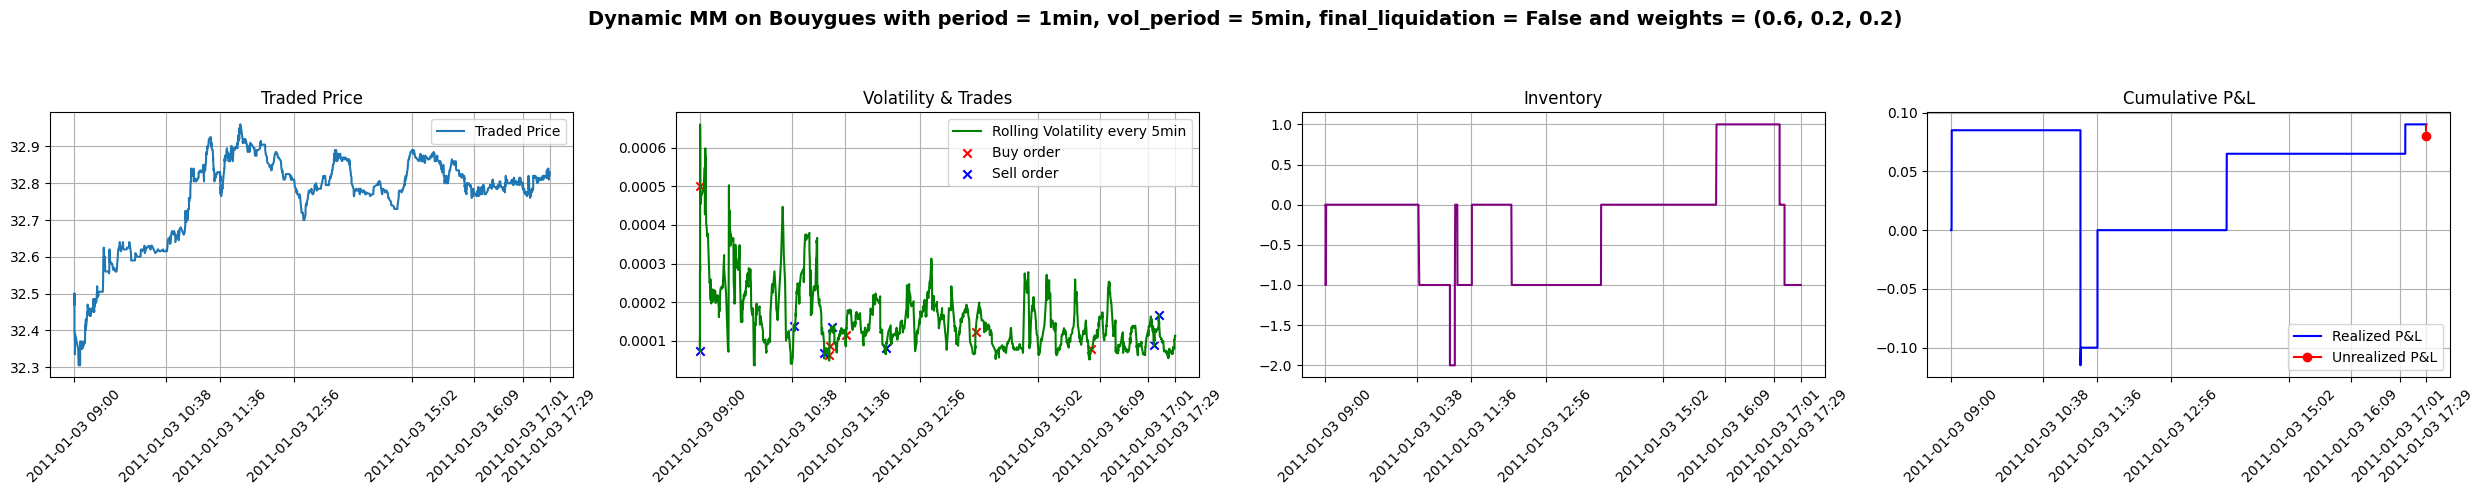


--- Vol_assessed with V0 = 0, period = 1min, vol_period = 5min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Bouygues dynamic MM,0.005,10.000,8.071,,,0.09,-1.00,-32.83,-0.01,-0.20,0.48,1,-2,52.98%


In [10]:
compute_strategies (['Bouygues'],[bouygues],start_date,end_date,"1min","5min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=True)

#### Comments:

The End of Period inventory constraint is actually a very restrictive one-it effectively freezes the strategy’s buying and selling activity, as it prevents the portfolio from holding any directional exposure. As a result, we end up with an almost zero inventory and very low P&L, but also minimal risk. This strategy becomes interesting if deployed with larger volumes, but in that case, the issue of market impact would become central.

#### Final Comments:

The design of a market making strategy forces us to combine constraints that push the control variables in opposite directions. 

Inventory, as it turns out, tries to limit the trading rate while the P&L constraint tries to push it upwards.

Without using directional signals to assist our quoting, we would need to have a dynamic quoting taking the current inventory as input in order to force the inventory to mean-revert further towards zero than it currently does.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3.3 Examples of variation of V0</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

**We now observe the behavior of our strategies under the assumption that the day starts with existing inventory in the portfolio, as a market-making desk would typically begin its trading day.**

##### Three profile, period = 15mn, vol_period = 15mn, V0=100

In [13]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False)

Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:28<00:00,  1.99s/it]



--- Vol_assessed with V0 = 100, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,25.27,0.00,0.00,15.51,7.00,10.88,100,-12,11.76%
1,LVMH dynamic MM,0.010,4.214,3.571,,,15.86,9.00,1116.45,-49.19,-2.29,4.94,100,-14,11.76%
2,Bouygues dynamic MM,0.005,4.214,6.143,,,9.79,7.00,229.81,27.47,0.91,2.79,100,-5,26.47%
3,Sanofi dynamic MM,0.005,6.786,10.000,,,28.93,-9.00,-443.93,69.95,-3.65,3.65,100,-9,23.53%
4,Google dynamic MM,0.005,2.929,8.071,,,591.17,-1.00,-604.33,118.94,-12.23,12.77,100,-27,7.69%
5,Amazon dynamic MM,0.005,2.929,9.357,,,320.47,7.00,1289.54,-73.67,-24.77,25.85,100,-51,3.85%
6,Apple dynamic MM,0.005,6.143,7.429,,,336.79,1.00,329.72,59.05,-27.42,28.19,100,-41,3.85%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:27<00:00,  1.99s/it]



--- Vol_assessed with V0 = 100, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,25.27,0.00,0.00,15.51,7.00,10.88,100,-12,11.76%
1,LVMH dynamic MM,0.010,5.500,3.571,,,15.86,1.00,124.05,-42.99,-8.35,8.47,100,-18,2.94%
2,Bouygues dynamic MM,0.005,1.000,1.000,,,33.58,-25.00,-820.75,1.84,-18.00,18.18,100,-30,0.00%
3,Sanofi dynamic MM,0.005,1.643,2.929,,,81.57,-22.00,-1085.15,19.16,-6.74,8.26,100,-27,0.00%
4,Google dynamic MM,0.005,2.286,2.929,,,627.56,-23.00,-13899.59,62.71,-23.00,23.00,100,-39,0.00%
5,Amazon dynamic MM,0.005,3.571,10.000,,,323.35,3.00,552.66,-67.37,-26.42,26.65,100,-50,0.00%
6,Apple dynamic MM,0.005,1.000,7.429,,,370.35,116.00,38247.52,99.99,30.58,34.88,120,-21,0.00%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:29<00:00,  2.00s/it]



--- Vol_assessed with V0 = 100, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,2.286,,,25.27,0.00,0.00,15.51,7.00,10.88,100,-12,11.76%
1,LVMH dynamic MM,0.010,4.214,3.571,,,15.86,9.00,1116.45,-49.19,-2.29,4.94,100,-14,11.76%
2,Bouygues dynamic MM,0.005,1.000,1.643,,,31.33,-17.00,-558.11,4.91,-13.50,13.68,100,-25,2.94%
3,Sanofi dynamic MM,0.005,2.286,3.571,,,77.55,-19.00,-937.18,20.14,-9.44,9.56,100,-25,11.76%
4,Google dynamic MM,0.005,2.286,2.929,,,627.56,-23.00,-13899.59,62.71,-23.00,23.00,100,-39,0.00%
5,Amazon dynamic MM,0.005,2.929,9.357,,,320.47,7.00,1289.54,-73.67,-24.77,25.85,100,-51,3.85%
6,Apple dynamic MM,0.005,5.500,10.000,,,348.06,40.00,13188.80,68.35,-3.88,17.27,100,-28,3.85%


#### Comments:

The results we obtain when starting with an initial inventory $V_0$ of 100 shares are quite surprising. Indeed, one might expect that any profile emphasizing end inventory or EOP (End of Period) inventory would enforce a highly asymmetric strategy of constant selling. This is true for certain stocks such as Apple across all three profiles, but it cannot be generalized—especially not to French stocks.

Regarding the balanced profile, the strategy tends to liquidate the entire position to achieve an end inventory close to zero. Some of these strategies work well, resulting in nearly zero inventory at the end of the period and realized P&L, as seen with Total. In fact, for very liquid U.S. stocks, the strategy sometimes even leads the investor to hold a short portfolio, with positions up to -51 shares. The balanced strategy actually performs quite well when there is initial inventory, as it resembles an optimal liquidation process, and in such cases the constraint parameters turn out to be well-suited.

For the aggressive profile, the results are more nuanced. The strategy rarely ends with a zero inventory and sometimes ends with relatively significant end inventories. The P&L is higher than with the balanced strategy, but at the cost of greater portfolio risk. For example, while the P&L on Google is appealing, it should not overshadow the fact that 23 shares are shorted for a Mark-to-Market value of $13,900$, creating significant exposure relative to the gain ($600$).

Finally, the cautious profile is relatively comparable to the aggressive one, with slightly lower end inventories due to the constraint of having zero inventory more regularly throughout the day. Nonetheless, the same risk-related comments that apply to the aggressive profile are also relevant here. When starting with a positive initial inventory, the balanced profile is generally preferred.

##### Three profile, period = 15mn, vol_period = 15mn, V0=-100

In [14]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=-100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=-100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=-100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False)

Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:30<00:00,  2.00s/it]



--- Vol_assessed with V0 = -100, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,8.714,9.357,,,-3.37,-3.00,-121.48,-25.74,-2.59,3.53,5,-100,14.71%
1,LVMH dynamic MM,0.010,8.714,10.000,,,0.30,6.00,744.30,47.82,0.12,2.59,6,-100,17.65%
2,Bouygues dynamic MM,0.005,4.214,6.143,,,-10.51,7.00,229.81,-23.22,0.91,2.79,8,-100,26.47%
3,Sanofi dynamic MM,0.005,6.786,10.000,,,-20.60,-9.00,-443.93,-79.53,-3.65,3.65,0,-100,23.53%
4,Google dynamic MM,0.005,4.857,9.357,,,-606.25,-2.00,-1208.66,-100.43,-11.96,12.42,4,-100,7.69%
5,Amazon dynamic MM,0.005,2.929,9.357,,,-391.37,7.00,1289.54,58.17,-24.77,25.85,7,-100,3.85%
6,Apple dynamic MM,0.005,6.143,7.429,,,-395.93,1.00,329.72,-6.23,-27.42,28.19,6,-100,3.85%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:27<00:00,  1.99s/it]



--- Vol_assessed with V0 = -100, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,10.000,10.000,,,-2.86,-8.00,-323.96,-27.49,-6.03,6.03,0,-100,2.94%
1,LVMH dynamic MM,0.010,6.786,5.500,,,3.31,1.00,124.05,58.19,-6.76,6.94,1,-100,0.00%
2,Bouygues dynamic MM,0.005,8.714,8.714,,,-4.52,-1.00,-32.83,-30.55,-3.24,3.24,0,-100,5.88%
3,Sanofi dynamic MM,0.005,10.000,10.000,,,-11.29,-22.00,-1085.15,-92.46,-9.56,9.56,0,-100,5.88%
4,Google dynamic MM,0.005,10.000,8.714,,,-490.27,-22.00,-13295.26,-245.58,-20.85,20.85,-3,-100,0.00%
5,Amazon dynamic MM,0.005,10.000,10.000,,,-220.83,-44.00,-8105.68,-73.41,-51.04,51.04,-19,-100,0.00%
6,Apple dynamic MM,0.005,1.000,6.786,,,-337.75,104.00,34290.88,3.02,20.50,27.88,108,-100,0.00%


Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 225/225 [07:32<00:00,  2.01s/it]



--- Vol_assessed with V0 = -100, period = 15min, vol_period = 15min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,8.714,9.357,,,-3.37,-3.00,-121.48,-25.74,-2.59,3.53,5,-100,14.71%
1,LVMH dynamic MM,0.010,6.143,6.786,,,3.14,17.00,2108.85,44.43,4.09,5.44,17,-100,8.82%
2,Bouygues dynamic MM,0.005,8.714,9.357,,,-4.52,1.00,32.83,-30.50,-2.12,2.24,1,-100,17.65%
3,Sanofi dynamic MM,0.005,6.786,10.000,,,-20.60,-9.00,-443.93,-79.53,-3.65,3.65,0,-100,23.53%
4,Google dynamic MM,0.005,9.357,10.000,,,-513.15,-18.00,-10877.94,-214.82,-18.35,18.35,0,-100,3.85%
5,Amazon dynamic MM,0.005,2.929,9.357,,,-391.37,7.00,1289.54,58.17,-24.77,25.85,7,-100,3.85%
6,Apple dynamic MM,0.005,1.643,6.786,,,-341.33,103.00,33961.16,2.12,19.50,27.58,107,-100,3.85%


#### Comments:

The results here are very different. All three profiles perform poorly. The balanced profile leads to the largest losses, while the aggressive profile incurs the smallest losses—though this comes at the cost of relatively high end-of-day inventories, except in notable cases like LVMH and Bouygues, where end inventories are actually lower than those under the balanced strategy. These outcomes prompt a reevaluation of our earlier findings. Due to the strategy’s “predictive” nature, it adjusts its parameters to market conditions. We can infer that most price trends on this particular day were bullish. The need to cover short positions in a rising market leads to significant losses, whereas liquidating a long inventory contributes to positive performance.

#### Final Comments:

Given that these strategies are highly dependent on price dynamics, it would be worth considering the implementation of “restraint” parameters for buying or selling inventory based on market momentum. Additionally, signals could be developed to encourage aggressive liquidation during sharp dips—either upward or downward, depending on the position.

The symmetric nature of the strategy is clearly challenged here when varying the initial inventory. However, these results are not entirely unexpected.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3.3.3 Same plot as before with $V0$ in {-100,100}</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Vol Assessed Grid Eval Total: 100%|██████████████████████████████████████████████████| 225/225 [03:45<00:00,  1.00s/it]


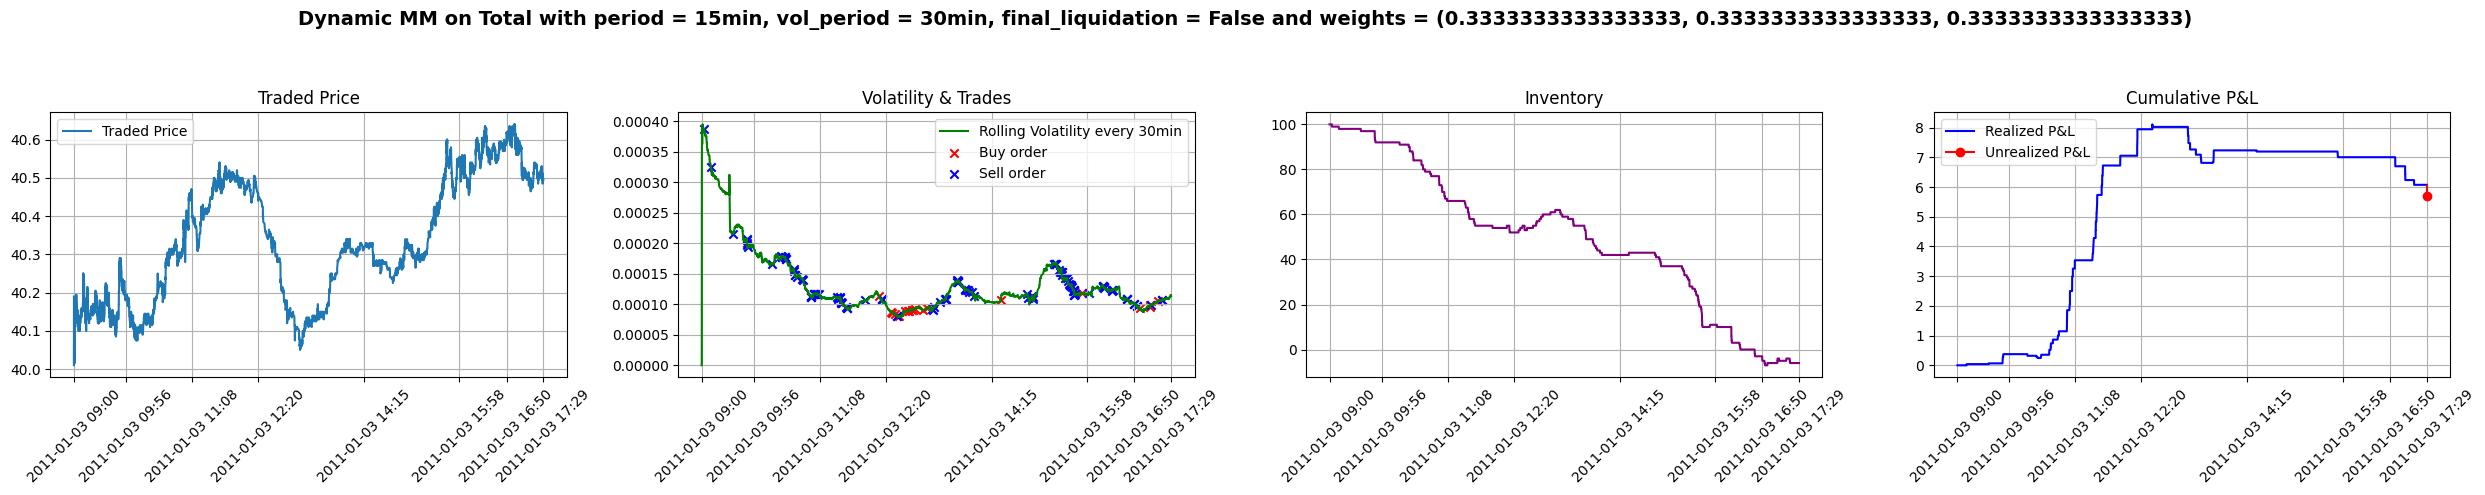


--- Vol_assessed with V0 = 50, period = 15min, vol_period = 30min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,10.000,2.286,,,6.08,-6.00,-242.97,-0.38,48.00,49.18,98,-6,2.94%


Vol Assessed Grid Eval Total: 100%|██████████████████████████████████████████████████| 225/225 [04:20<00:00,  1.16s/it]


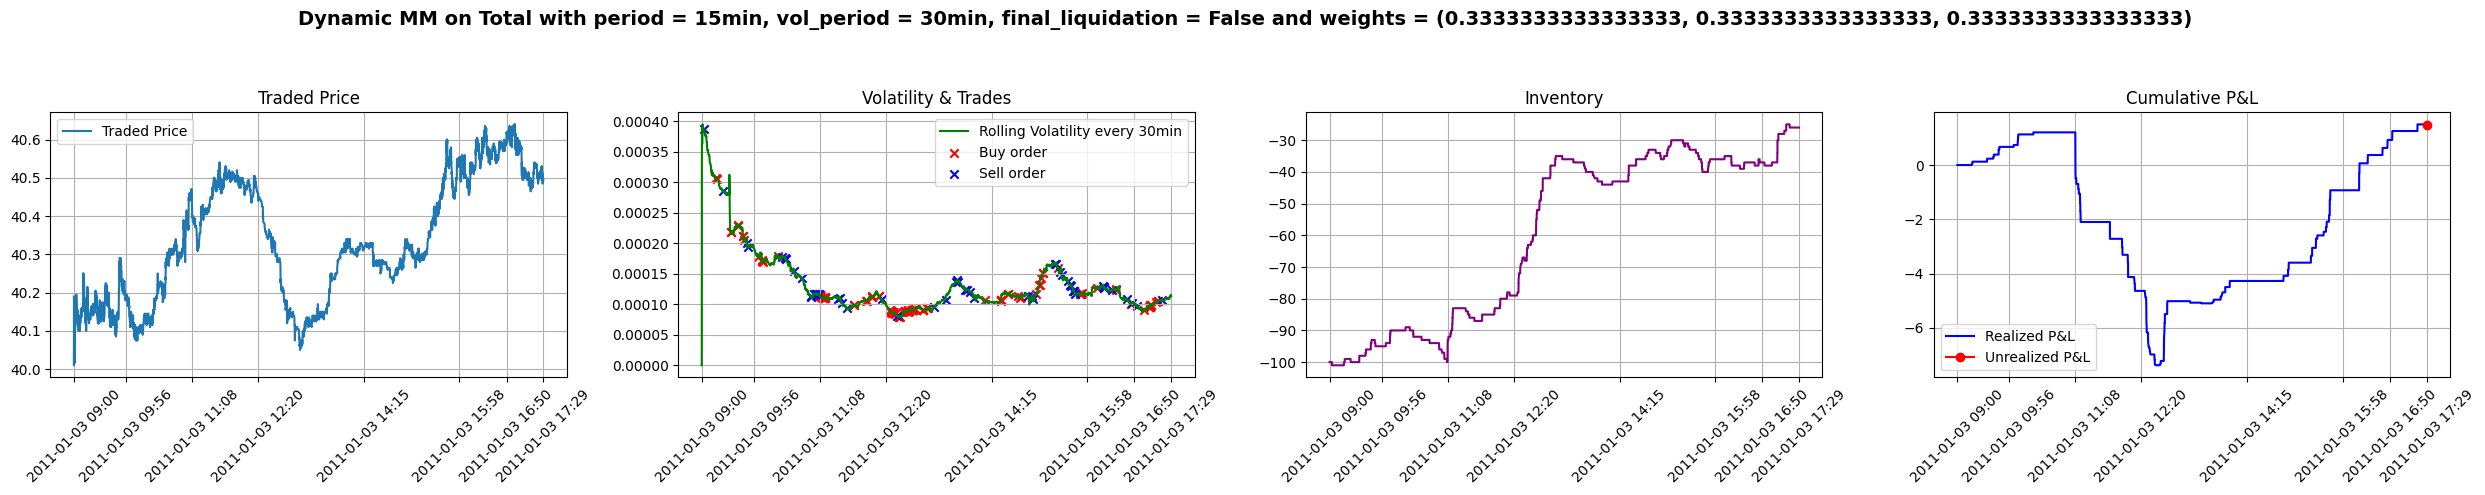


--- Vol_assessed with V0 = -50, period = 15min, vol_period = 30min, final_liquidation = False and weights = (0.3333333333333333, 0.3333333333333333, 0.3333333333333333) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.000,5.500,,,1.50,-26.00,-1052.87,-0.04,-58.38,58.38,-26,-101,0.00%


In [6]:
compute_strategies (['Total'],[total],start_date,end_date,"15min","30min",V0=100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=True)
compute_strategies (['Total'],[total],start_date,end_date,"15min","30min",V0=-100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(1/3,1/3,1/3), plot=True)

#### Comments:

When starting with opposite side inventories, the equally weighted strategy manages to converge towards an inventory closer to zero and the inventory dynamics matches better on this sample the traded price dynamics. When the asset is trending downwards strongly, the negative starting inventory strategy buys a lot and catches up on its imbalance with flatter inventory dynamics outside this and on the other hand, it is only during the strong downwards trend that the positive starting inventory strategy flattens out.

Vol Assessed Grid Eval LVMH: 100%|███████████████████████████████████████████████████| 225/225 [01:46<00:00,  2.12it/s]


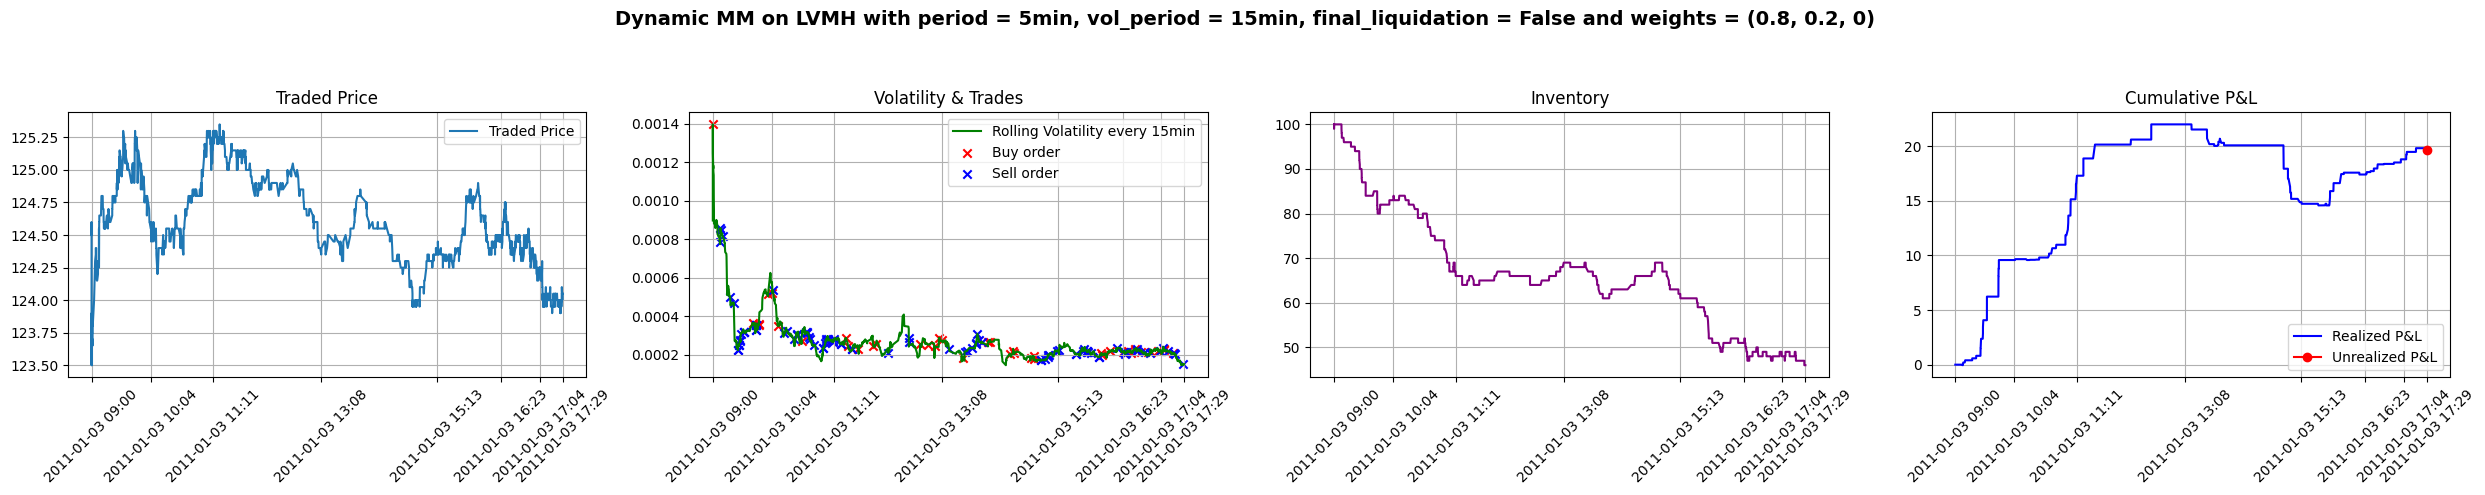


--- Vol_assessed with V0 = 50, period = 5min, vol_period = 15min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,LVMH dynamic MM,0.010,10.000,1.643,,,19.82,46.00,5706.30,-0.16,66.12,66.12,100,46,0.00%


Vol Assessed Grid Eval LVMH: 100%|███████████████████████████████████████████████████| 225/225 [01:44<00:00,  2.16it/s]


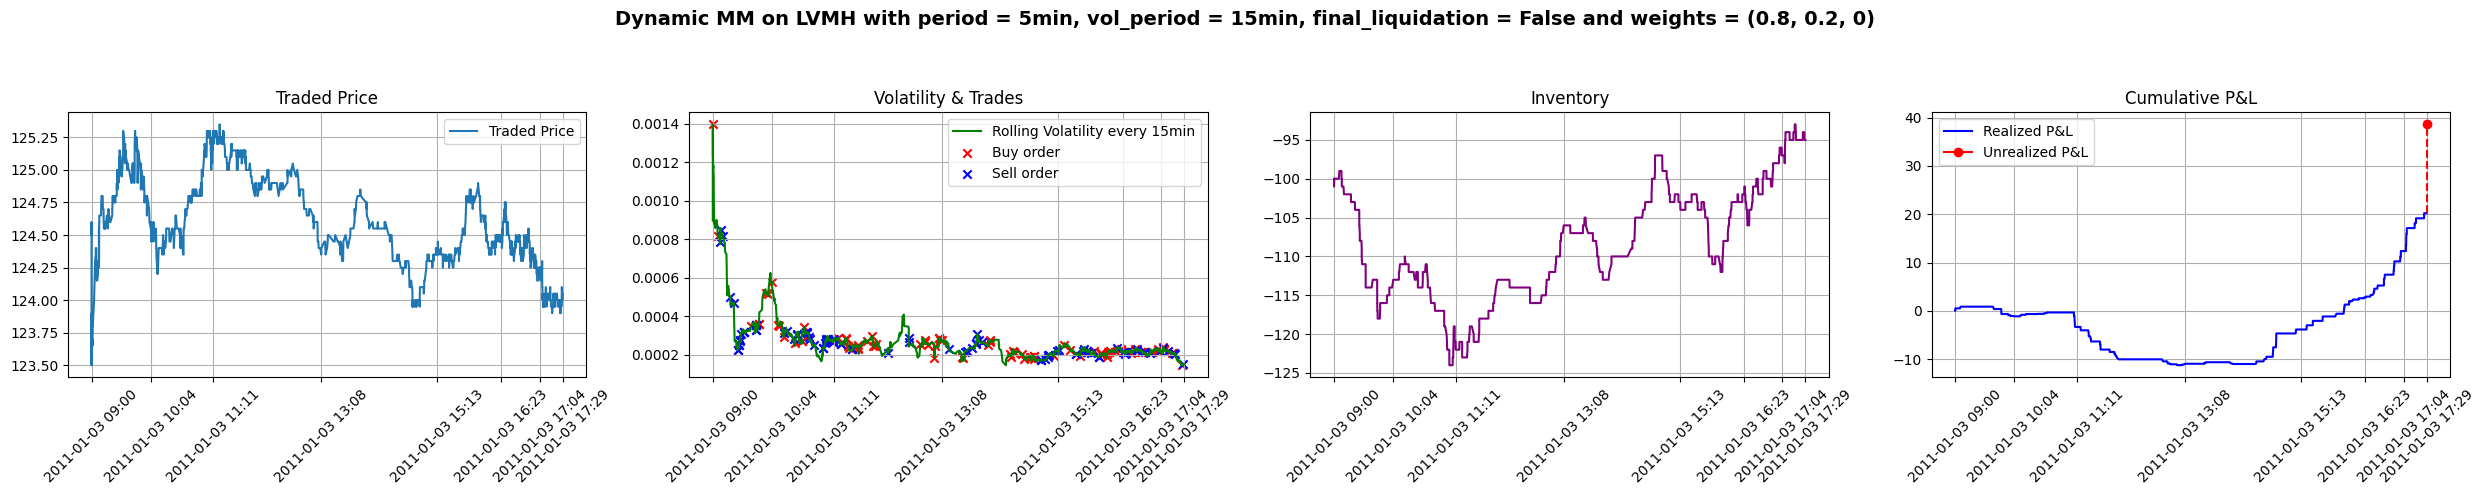


--- Vol_assessed with V0 = -50, period = 5min, vol_period = 15min, final_liquidation = False and weights = (0.8, 0.2, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,LVMH dynamic MM,0.010,4.857,2.929,,,20.22,-95.00,-11784.75,18.40,-108.59,108.59,-50,-124,0.00%


In [7]:
compute_strategies (['LVMH'],[lvmh],start_date,end_date,"5min","15min",V0=100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=True)
compute_strategies (['LVMH'],[lvmh],start_date,end_date,"5min","15min",V0=-100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.8,0.2,0), plot=True)

#### Comments:

In the scenario of a loss driven at 80% by the PnL, the inventory curve is not agnostic to the starting inventory.

The LVMH dynamic MM still presents mean-reverting properties on the inventory curve, but it is now reverting near the starting inventory rather than the target zero. The static MM strategy is pushing down the inventory towards with little to no room upwards.

Vol Assessed Grid Eval Bouygues: 100%|███████████████████████████████████████████████| 225/225 [03:07<00:00,  1.20it/s]


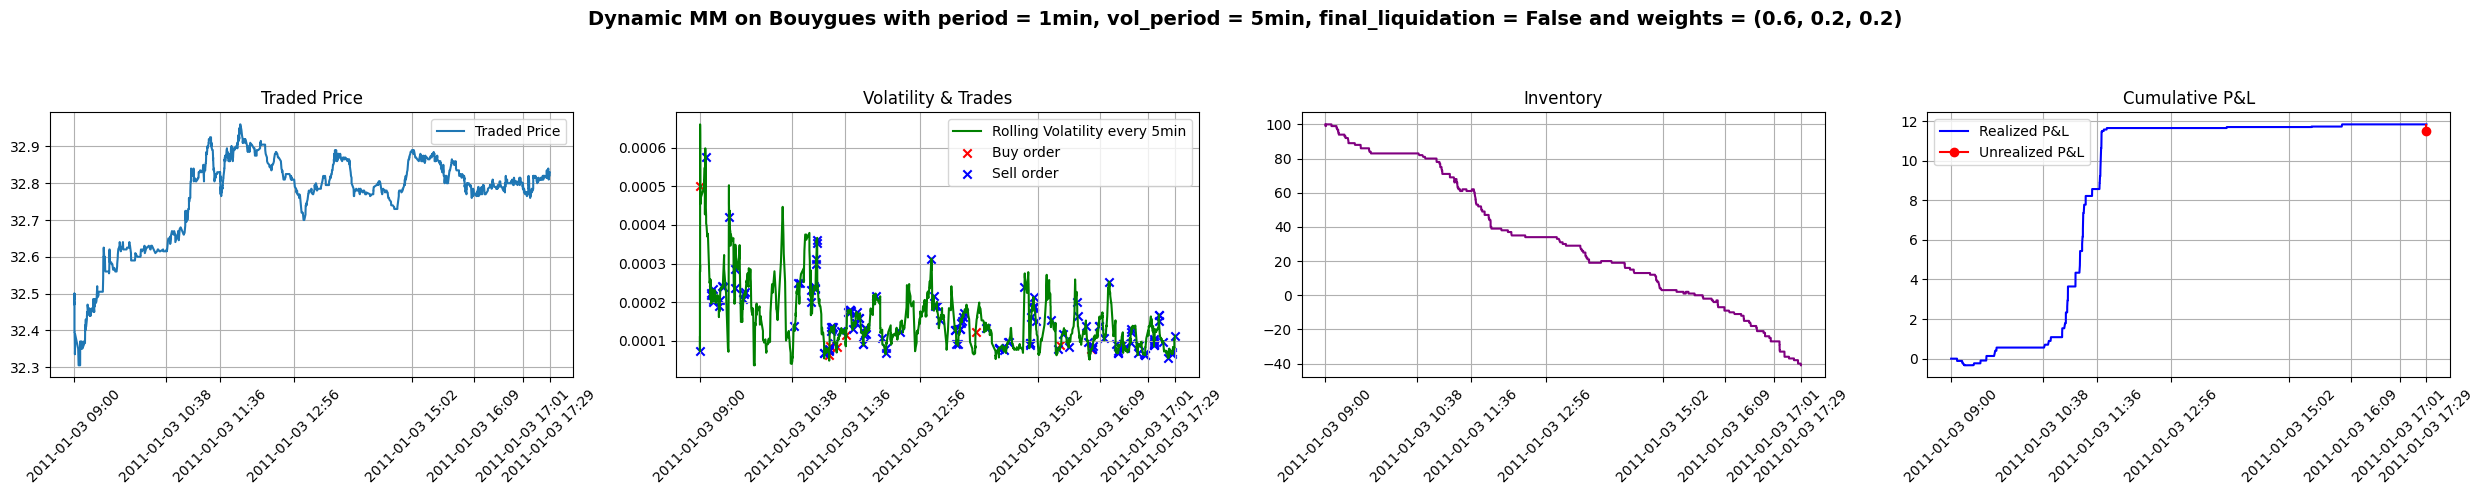


--- Vol_assessed with V0 = 50, period = 1min, vol_period = 5min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Bouygues dynamic MM,0.005,8.714,1.000,,,11.83,-41.00,-1346.03,-0.31,31.55,40.12,100,-41,2.06%


Vol Assessed Grid Eval Bouygues: 100%|███████████████████████████████████████████████| 225/225 [03:05<00:00,  1.21it/s]


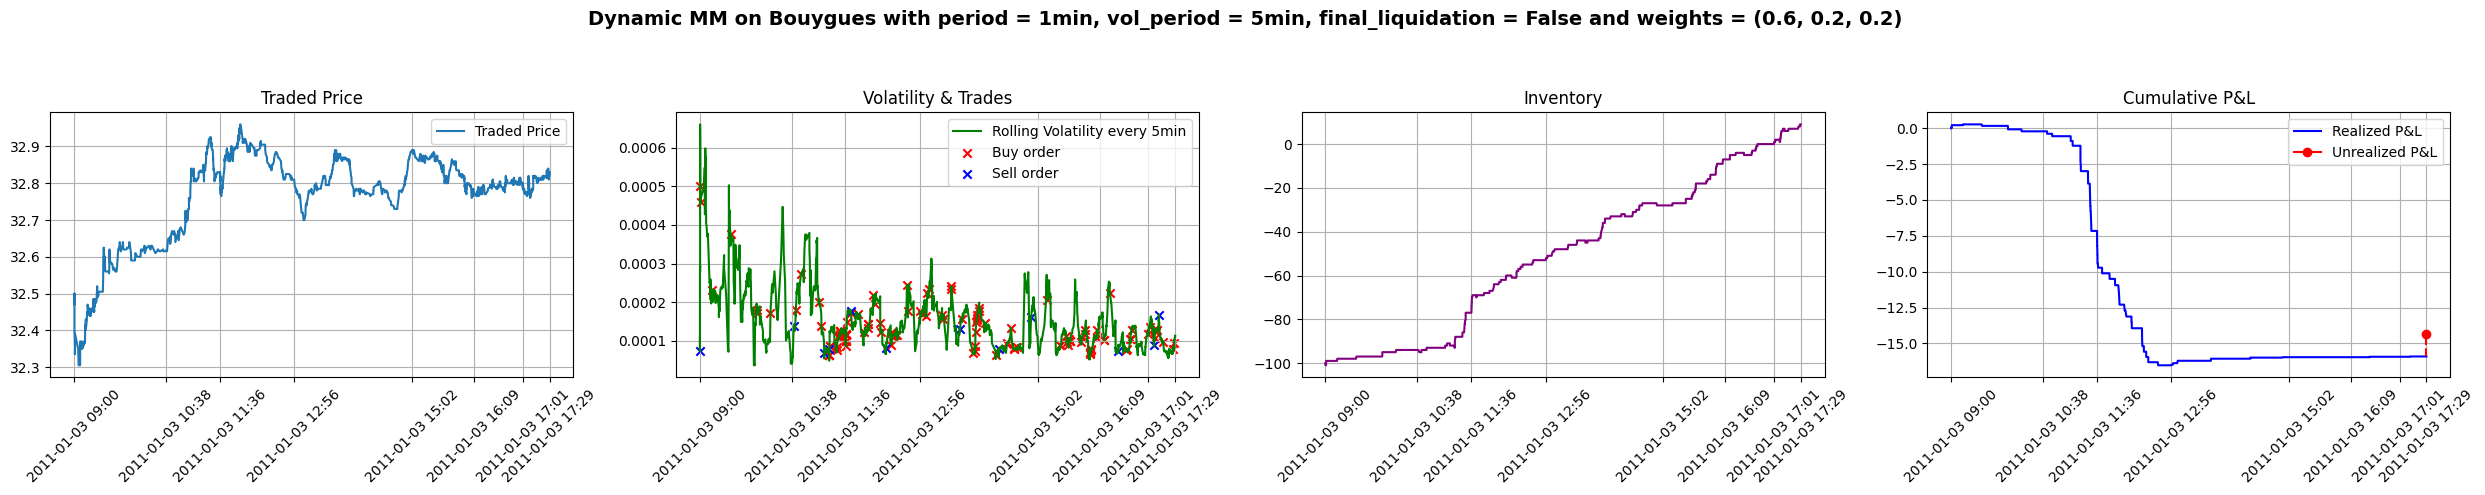


--- Vol_assessed with V0 = -50, period = 1min, vol_period = 5min, final_liquidation = False and weights = (0.6, 0.2, 0.2) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Bouygues dynamic MM,0.005,1.643,7.429,,,-15.91,9.00,295.47,1.58,-49.64,50.39,9,-99,3.67%


In [8]:
compute_strategies (['Bouygues'],[bouygues],start_date,end_date,"1min","5min",V0=100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=True)
compute_strategies (['Bouygues'],[bouygues],start_date,end_date,"1min","5min",V0=-100,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (15,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=True)

#### Comments:

The strategy plots strongly support the initial analysis. In bullish markets with a positive initial inventory, the strategy aims to efficiently liquidate these positions, generating solid performance. This is particularly true for the balanced strategy. However, this forced liquidation—driven by EOP inventory and end inventory parameters—ultimately limits execution efficiency. While the strategy may exploit market dips effectively, the obligation to continue placing orders afterward compromises its overall effectiveness.

Regarding the aggressive profile, the strategy no longer necessarily seeks to liquidate inventory but rather aims to capitalize on price fluctuations. This tends to drive P&L upward but results in large open positions remaining in the portfolio. The P&L constraint clearly outweighs that of the end inventory, allowing the algorithm to disregard inventory considerations if doing so increases P&L—unless liquidation is itself profitable.

Finally, looking at the cautious profile, it seeks to liquidate almost linearly, even at the expense of P&L. Once again, the EOP inventory constraint proves to be inadequate. A more asymmetric strategy would be more appropriate in this case.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">3.4 Other parameters</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

As mentioned in the previous comments, many other parameters could be considered to make the strategy more relevant. For instance, imbalance parameters could be introduced to avoid holding positions that are prone to arbitrage, and instead allow the strategy to follow the market trend. This would also make the strategy more asymmetric, enabling it to be exposed only to the bid or ask side depending on the direction.

We could also look at trade volume parameters over the course of the day, which could help extract directional price signals—particularly useful for less liquid stocks, where such indicators tend to be more revealing.

More broadly, the strategy should be allowed to operate asymmetrically, i.e., to take current inventory into account when placing limit orders and possibly only place limit orders in one direction. Finally, it’s clear that having deeper access to the order book would be highly beneficial, as it would allow us to test a wider range of strategies.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">4. P&L </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

### 4. P&L

**Implementation**

For the same market maker, we consider that the remaining stocks at the end of the day have to be traded at the close (the last price of the day) to get a zero final inventory. 

a. Plot and compare the P&L of the optimal strategies obtained in the previous section (for fixed $d_b$ and $d_a$ and as functions of intraday volatility). Add on the graphs the price, the inventory and the volatility. 

b. Do you think that it is always possible to liquidate an inventory at the closing price ?

c. Study the dependence of the P&L to the inventory. If the posting distance depends on both inventory and volatility $d_t=f(V_t,\sigma_t)$, what could be the shape of $f$ to optimize the closing P&L ?

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">4.1 Results of the two profiles </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

#### We do only two profile : one full PnL oriented and one equilibrated between PnL and eop (because end inv does not count as liquidated even if irrealistic)

# Full aggressive - (1,0,0)

In [11]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8, minutes=30)

compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"30min","30min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"5min","5min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"1min","1min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0), plot=False)

Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [03:32<00:00,  1.75s/it]



--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 30min, vol_period = 30min, final_liquidation = True and weights = (1, 0, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.00,10.00,,,15.40,0.00,0.00,,43.18,43.29,76,-1,5.88%
1,Total static MM,0.005,,,- 0 ticks,+ 10 ticks,21.66,0.00,0.00,,66.06,66.18,122,-1,5.88%
2,LVMH dynamic MM,0.010,10.00,1.64,,,28.48,0.00,0.00,,-20.65,20.65,0,-37,5.88%
3,LVMH static MM,0.010,,,- 10 ticks,+ 5 ticks,28.95,0.00,0.00,,-17.24,17.24,0,-33,5.88%
4,Bouygues dynamic MM,0.005,1.00,9.36,,,2.93,0.00,0.00,,17.41,17.41,42,0,11.76%
5,Bouygues static MM,0.005,,,- 0 ticks,+ 10 ticks,3.87,0.00,0.00,,25.76,25.76,60,0,5.88%
6,Sanofi dynamic MM,0.005,1.00,10.00,,,17.60,0.00,0.00,,20.65,20.88,45,-2,11.76%
7,Sanofi static MM,0.005,,,- 0 ticks,+ 10 ticks,27.97,0.00,0.00,,33.00,33.00,67,0,5.88%
8,Google dynamic MM,0.005,2.29,8.07,,,-16.84,0.00,0.00,,-15.77,16.08,2,-32,7.69%
9,Google static MM,0.005,,,- 2 ticks,+ 10 ticks,-21.62,0.00,0.00,,-17.00,17.15,1,-33,7.69%


Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [03:38<00:00,  1.81s/it]



--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 15min, vol_period = 15min, final_liquidation = True and weights = (1, 0, 0) ---



...


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 5min, vol_period = 5min, final_liquidation = True and weights = (1, 0, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.00,10.00,,,35.17,0.00,0.00,,104.18,104.22,211,-1,0.98%
1,Total static MM,0.005,,,- 0 ticks,+ 10 ticks,54.57,0.00,0.00,,172.53,172.53,340,0,2.94%
2,LVMH dynamic MM,0.010,10.00,2.93,,,43.37,0.00,0.00,,-33.86,33.86,0,-54,1.98%
3,LVMH static MM,0.010,,,- 10 ticks,+ 5 ticks,45.25,0.00,0.00,,-30.18,30.18,0,-50,1.98%
4,Bouygues dynamic MM,0.005,1.00,9.36,,,3.56,0.00,0.00,,49.83,49.83,110,0,0.98%
5,Bouygues static MM,0.005,,,- 0 ticks,+ 10 ticks,4.88,0.00,0.00,,70.21,70.21,150,0,0.98%
6,Sanofi dynamic MM,0.005,1.00,10.00,,,39.40,0.00,0.00,,49.91,49.91,99,0,0.98%
7,Sanofi static MM,0.005,,,- 0 ticks,+ 10 ticks,57.97,0.00,0.00,,74.57,74.57,150,0,0.98%
8,Google dynamic MM,0.005,1.00,10.00,,,46.57,0.00,0.00,,15.72,21.05,50,-24,1.28%
9,Google static MM,0.005,,,- 2 ticks,+ 10 ticks,38.51,0.00,0.00,,13.55,20.04,52,-27,2.56%


Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [05:15<00:00,  2.61s/it]



--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 1min, vol_period = 1min, final_liquidation = True and weights = (1, 0, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.00,10.00,,,49.80,0.00,0.00,,176.62,176.62,366,-1,0.60%
1,Total static MM,0.005,,,- 0 ticks,+ 10 ticks,74.65,0.00,0.00,,267.42,267.42,531,-1,0.60%
2,LVMH dynamic MM,0.010,10.00,1.00,,,44.36,0.00,0.00,,-43.11,43.11,0,-72,0.49%
3,LVMH static MM,0.010,,,- 10 ticks,+ 5 ticks,54.50,0.00,0.00,,-45.71,45.71,0,-81,0.49%
4,Bouygues dynamic MM,0.005,1.00,8.71,,,4.07,0.00,0.00,,56.81,56.81,119,0,0.23%
5,Bouygues static MM,0.005,,,- 0 ticks,+ 10 ticks,6.98,0.00,0.00,,92.00,92.00,190,0,0.23%
6,Sanofi dynamic MM,0.005,1.00,10.00,,,68.62,0.00,0.00,,90.95,90.95,204,0,0.21%
7,Sanofi static MM,0.005,,,- 0 ticks,+ 10 ticks,108.66,0.00,0.00,,146.40,146.40,306,0,0.21%
8,Google dynamic MM,0.005,1.00,10.00,,,82.86,0.00,0.00,,44.05,49.35,110,-26,0.54%
9,Google static MM,0.005,,,- 2 ticks,+ 10 ticks,71.79,0.00,0.00,,43.23,50.47,117,-33,0.27%


#### Comments:

Under the full P&L-oriented strategy (weights = 1, 0, 0), the algorithm’s behavior is entirely driven by profit maximization, without any penalty on inventory levels or the frequency of inventory neutralization. As a result, the strategy freely accumulates directional positions throughout the trading session, unconstrained by risk considerations. This effect is amplified by the modeling assumption that the entire portfolio is liquidated at the end of the period at the last available price. Because this liquidation is treated as frictionless, it artificially boosts the profitability of holding large, one-sided positions until the end.

This behavior is observable across all assets and execution frequencies. Inventories reach extreme levels, especially for liquid US stocks such as Apple and Amazon, where the maximum end-of-period inventories exceed 400 shares. The tick values optimized under this profile also reflect the strategy’s directional intent. The bid ticks are often very low or zero, while the ask ticks are pushed to the upper bound of the grid, typically +10. This configuration prioritizes the accumulation of a position on one side of the book rather than facilitating two-way liquidity provision. The strategy essentially abandons market making logic and behaves like a speculative trader attempting to profit from anticipated price moves.

The percentage of end-of-period intervals with zero inventory is negligible in all cases, often below 1%. This confirms that the strategy rarely, if ever, attempts to maintain a neutral inventory during the session. All inventory is instead left to be unwound during the artificial end-of-day liquidation, which severely undermines the realism of the setup. While this approach may deliver high P&L on some stocks in trending conditions, it completely disregards execution costs, risk exposure, and the operational limits of actual trading systems.

Overall, the results highlight the structural flaws of a strategy driven solely by end-period profit and relying on final price liquidation. The behavior observed is inconsistent with realistic trading constraints, and the performance should be interpreted with caution. Without mechanisms to control inventory buildup or penalize holding risk, the strategy becomes highly opportunistic and prone to extreme, unhedged exposures that would be unacceptable in practice.

# Balanced - (0.5,0,0.5)

In [12]:
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"30min","30min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0,0.5), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"15min","15min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0,0.5), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"5min","5min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0,0.5), plot=False)
compute_strategies (list_FR_US_name,list_FR_US,start_date,end_date,"1min","1min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0,0.5), plot=False)

Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [03:39<00:00,  1.82s/it]



--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 30min, vol_period = 30min, final_liquidation = True and weights = (0.5, 0, 0.5) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.64,7.43,,,12.34,0.00,0.00,,33.53,34.24,62,-5,17.65%
1,Total static MM,0.005,,,- 2 ticks,+ 7 ticks,9.65,0.00,0.00,,23.82,24.65,44,-6,17.65%
2,LVMH dynamic MM,0.010,6.79,10.00,,,1.15,0.00,0.00,,3.59,4.06,13,-2,29.41%
3,LVMH static MM,0.010,,,- 10 ticks,+ 10 ticks,8.70,0.00,0.00,,-1.53,2.12,3,-5,17.65%
4,Bouygues dynamic MM,0.005,1.64,2.93,,,1.55,0.00,0.00,,0.47,4.59,13,-12,29.41%
5,Bouygues static MM,0.005,,,- 5 ticks,+ 8 ticks,1.18,0.00,0.00,,-1.71,1.94,2,-7,35.29%
6,Sanofi dynamic MM,0.005,2.93,5.50,,,4.63,0.00,0.00,,2.35,6.24,18,-8,23.53%
7,Sanofi static MM,0.005,,,- 1 ticks,+ 6 ticks,12.71,0.00,0.00,,12.06,13.24,31,-5,23.53%
8,Google dynamic MM,0.005,2.29,9.36,,,-17.61,0.00,0.00,,-16.85,16.85,0,-34,15.38%
9,Google static MM,0.005,,,- 2 ticks,+ 10 ticks,-21.62,0.00,0.00,,-17.00,17.15,1,-33,7.69%


Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [04:09<00:00,  2.07s/it]



--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 15min, vol_period = 15min, final_liquidation = True and weights = (0.5, 0, 0.5) ---



...


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 5min, vol_period = 5min, final_liquidation = True and weights = (0.5, 0, 0.5) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,10.00,10.00,,,1.43,0.00,0.00,,-3.72,4.01,2,-11,15.69%
1,Total static MM,0.005,,,- 9 ticks,+ 10 ticks,0.73,0.00,0.00,,-0.91,1.64,3,-5,25.49%
2,LVMH dynamic MM,0.010,6.79,6.14,,,10.91,0.00,0.00,,-3.98,4.71,6,-13,13.86%
3,LVMH static MM,0.010,,,- 5 ticks,+ 5 ticks,8.60,0.00,0.00,,3.98,6.79,20,-13,8.91%
4,Bouygues dynamic MM,0.005,10.00,10.00,,,-0.18,0.00,0.00,,-0.41,0.96,2,-3,32.35%
5,Bouygues static MM,0.005,,,- 8 ticks,+ 10 ticks,0.81,0.00,0.00,,-0.21,0.66,2,-2,43.14%
6,Sanofi dynamic MM,0.005,4.21,8.71,,,5.28,0.00,0.00,,3.97,5.46,16,-6,15.69%
7,Sanofi static MM,0.005,,,- 5 ticks,+ 8 ticks,-0.38,0.00,0.00,,-4.30,4.60,4,-14,8.82%
8,Google dynamic MM,0.005,6.79,8.07,,,4.96,0.00,0.00,,-2.05,8.90,22,-27,12.82%
9,Google static MM,0.005,,,- 4 ticks,+ 8 ticks,6.65,0.00,0.00,,-1.83,9.50,25,-29,7.69%


Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [06:12<00:00,  3.08s/it]



--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 1min, vol_period = 1min, final_liquidation = True and weights = (0.5, 0, 0.5) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,9.36,10.00,,,0.68,0.00,0.00,,-2.39,3.00,4,-8,16.27%
1,Total static MM,0.005,,,- 9 ticks,+ 10 ticks,0.79,0.00,0.00,,-1.74,1.77,1,-5,24.80%
2,LVMH dynamic MM,0.010,8.71,9.36,,,0.88,0.00,0.00,,-1.94,2.64,6,-9,26.17%
3,LVMH static MM,0.010,,,- 10 ticks,+ 5 ticks,54.50,0.00,0.00,,-45.71,45.71,0,-81,0.49%
4,Bouygues dynamic MM,0.005,7.43,8.71,,,-0.27,0.00,0.00,,0.81,1.16,4,-2,32.34%
5,Bouygues static MM,0.005,,,- 10 ticks,+ 9 ticks,0.46,0.00,0.00,,0.23,0.23,1,0,77.06%
6,Sanofi dynamic MM,0.005,6.14,10.00,,,0.29,0.00,0.00,,-0.91,2.19,11,-7,17.40%
7,Sanofi static MM,0.005,,,- 5 ticks,+ 7 ticks,2.85,0.00,0.00,,-0.55,1.56,4,-5,29.56%
8,Google dynamic MM,0.005,4.86,4.86,,,-6.67,0.00,0.00,,-0.61,11.80,32,-39,7.05%
9,Google static MM,0.005,,,- 8 ticks,+ 10 ticks,-5.40,0.00,0.00,,1.84,13.40,34,-36,5.69%


#### Comments:

The balanced strategy (weights = 0.5, 0, 0.5) aims to find a middle ground between P&L maximization and minimizing inventory at the end of each execution period. While final liquidation at the last price is still applied, the model is now explicitly penalized when it ends sub-periods with non-zero inventory. This changes the strategy's behavior significantly compared to the pure P&L profile.

The most visible impact is a clear reduction in exposure. Absolute average and maximum inventories are often cut in half or more. For example, Apple’s maximum inventory at the end of sub-periods drops to 68 in the dynamic version (down from over 400 in the full P&L case), and the percentage of EOPs with zero inventory rises to values between 3% and 16% depending on the time granularity—compared to <1% under the aggressive setup. In some cases, like Bouygues at 1-minute frequency, the static strategy even achieves 77% of flat intervals, reflecting strong inventory discipline.

This comes at a cost in terms of P&L. Profit levels are generally lower and sometimes negative—especially at higher frequencies on volatile assets like Amazon or Apple. This shows the inherent difficulty in balancing regular liquidation with economic performance. Ticks are also less extreme (e.g. -4/+6 or -5/+8), enabling more realistic order placement and reducing the speculative nature observed in the aggressive profile.

The strategy also becomes structurally more neutral. It alternates between buying and selling more consistently and avoids the purely directional positioning seen in the P&L-driven case. As a result, P&L is less volatile, and exposure is better controlled. On names like Sanofi or LVMH, this translates into stable dynamics, centered ticks, and a good balance between objectives.

However, the strategy can underperform in strongly trending markets. On stocks like Google or Amazon, both dynamic and static variants yield poor or even negative P&L, despite maintaining good EOP flatness ratios. This highlights the trade-off between following price trends and adhering to position discipline. Additionally, since final inventory is still liquidated fictitiously, the benefits of disciplined intra-day risk reduction are somewhat diminished at the session close.

In summary, the balanced profile enforces more realistic and controlled inventory management at the expense of lower profitability. It avoids the extremes of the aggressive strategy and is better suited to neutral or sideways markets. However, it remains constrained by the assumption of costless final liquidation and may struggle to capture directional opportunities when they arise.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">4.2 Few plot as before - fully aggressive and equilibrated</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Tick Grid Eval Total: 100%|██████████████████████████████████████████████████████████| 121/121 [01:40<00:00,  1.21it/s]


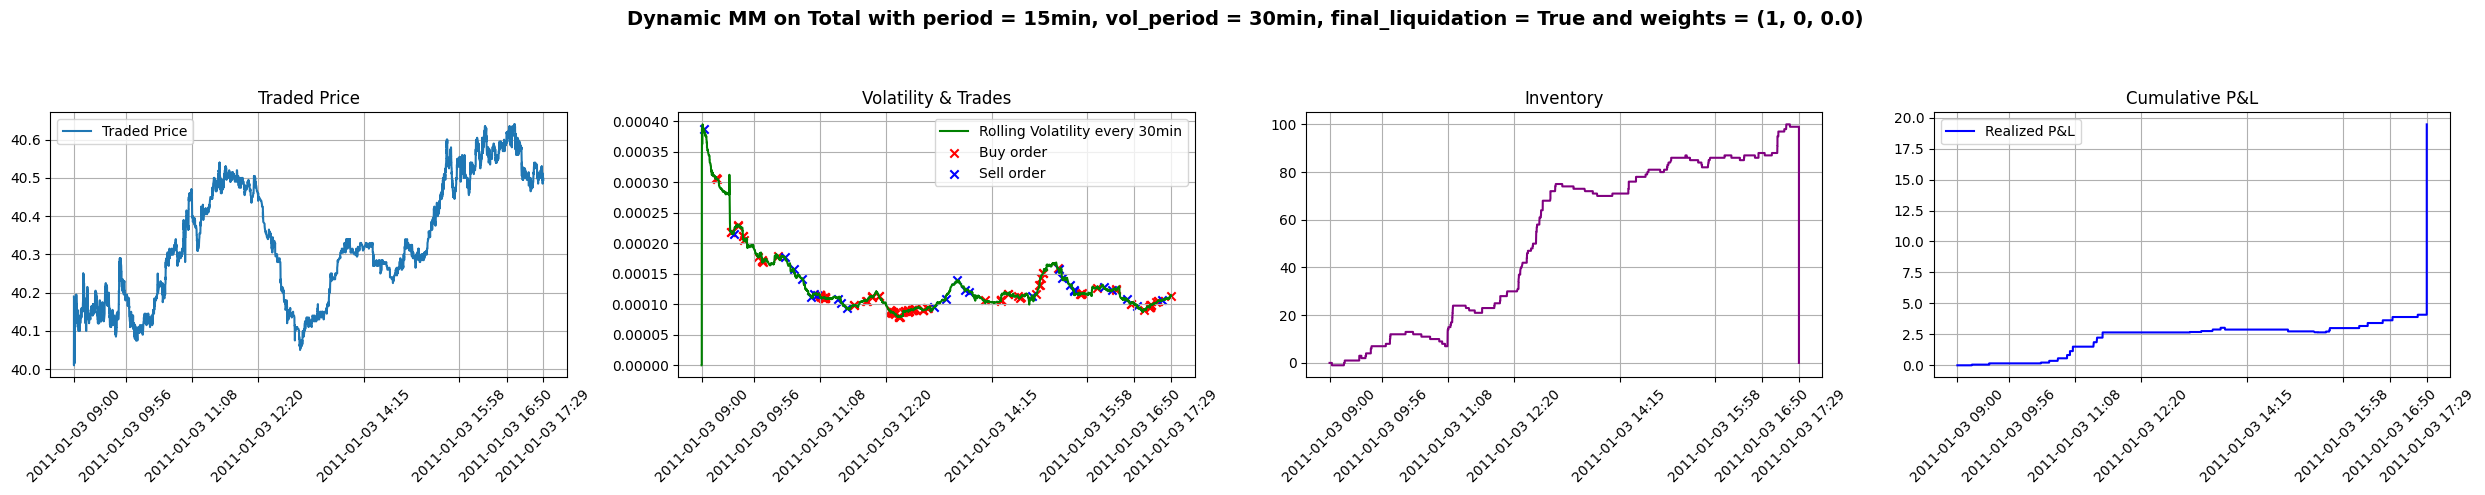

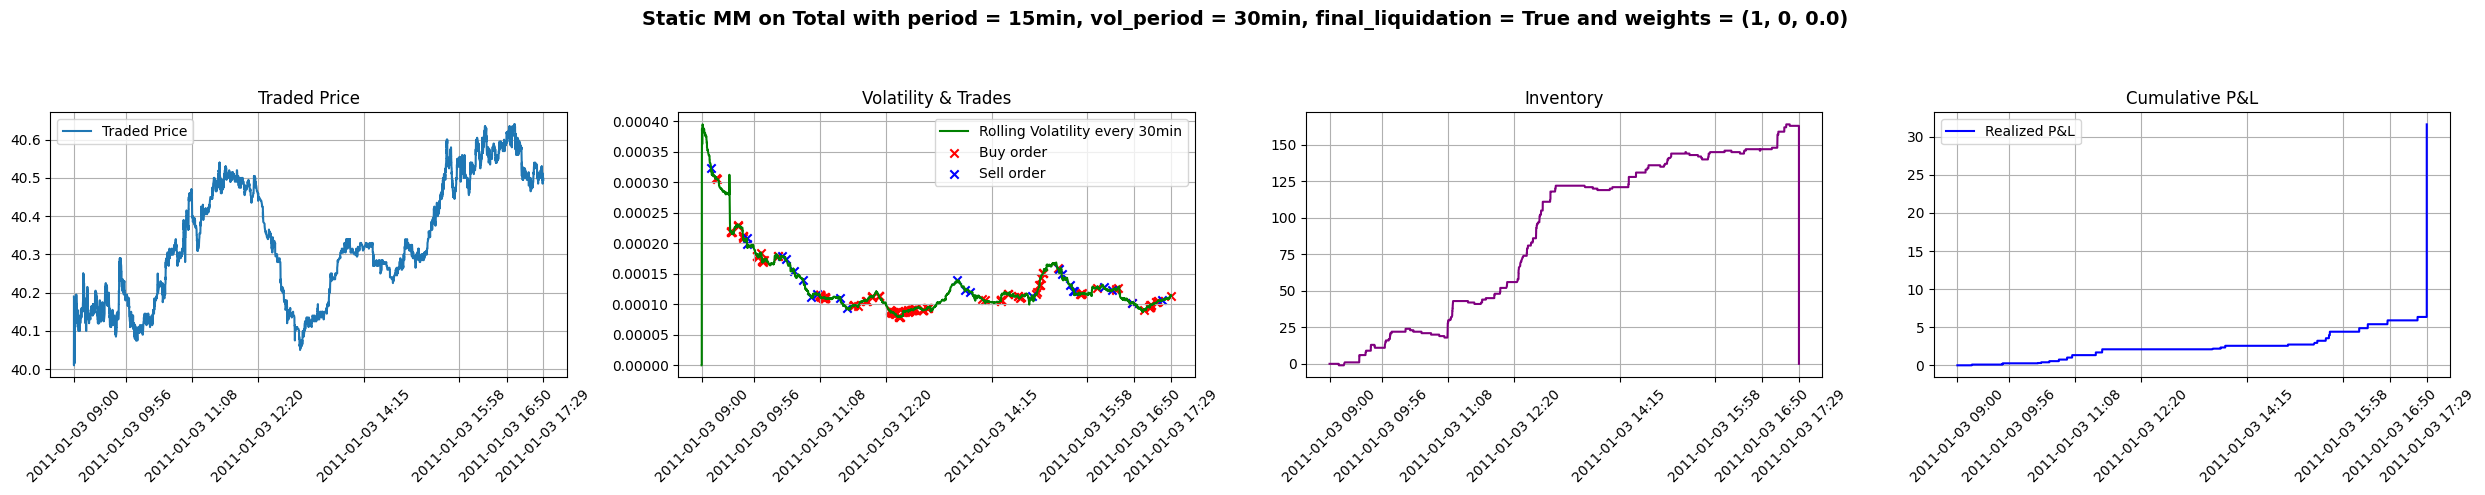


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 15min, vol_period = 30min, final_liquidation = True and weights = (1, 0, 0.0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.00,10.00,,,19.46,0.00,0.00,,50.74,50.79,98,-1,2.94%
1,Total static MM,0.005,,,- 0 ticks,+ 10 ticks,31.63,0.00,0.00,,86.44,86.50,162,-1,2.94%


Tick Grid Eval Total: 100%|██████████████████████████████████████████████████████████| 121/121 [01:36<00:00,  1.25it/s]


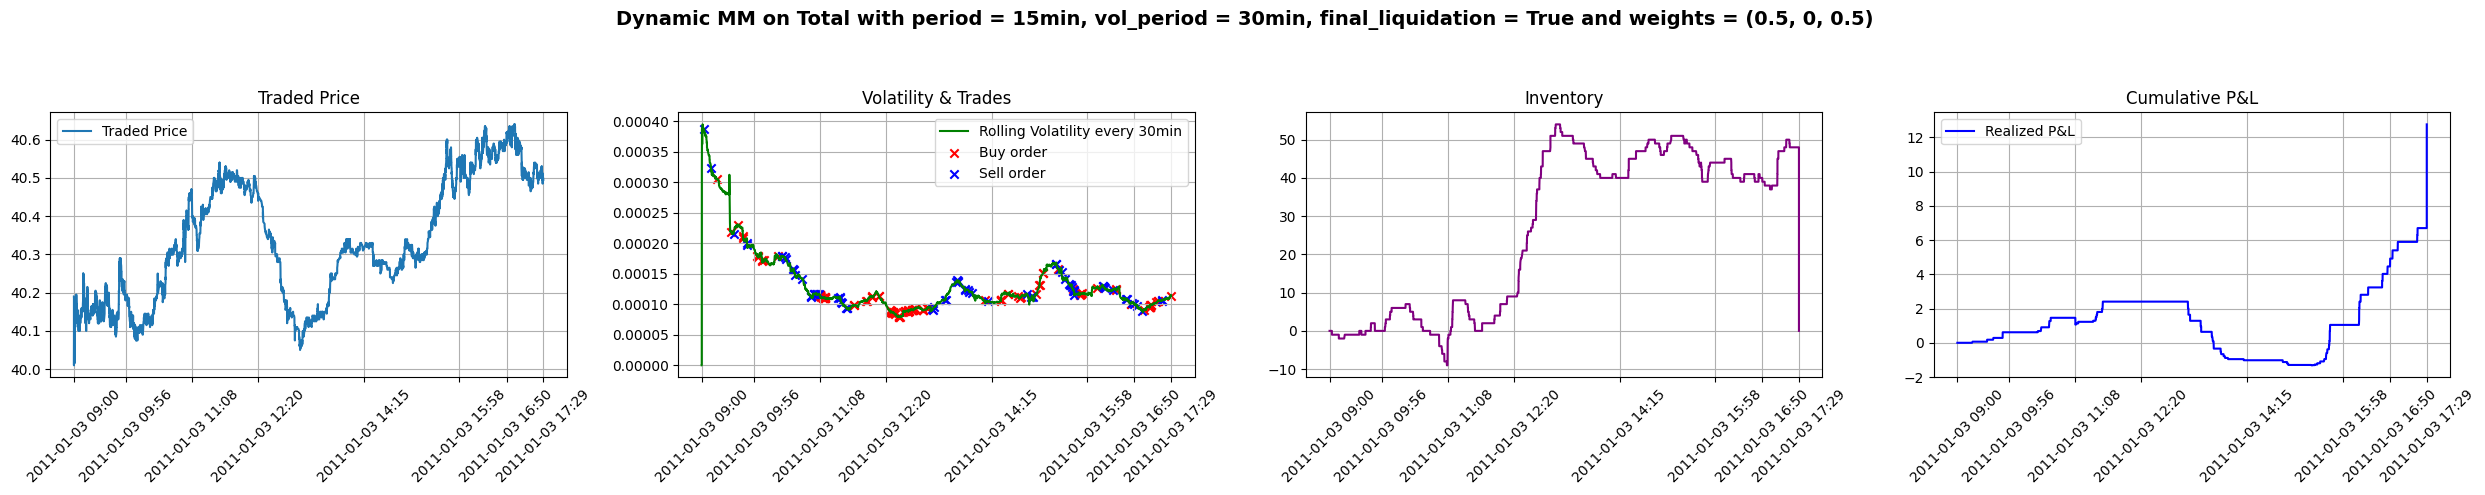

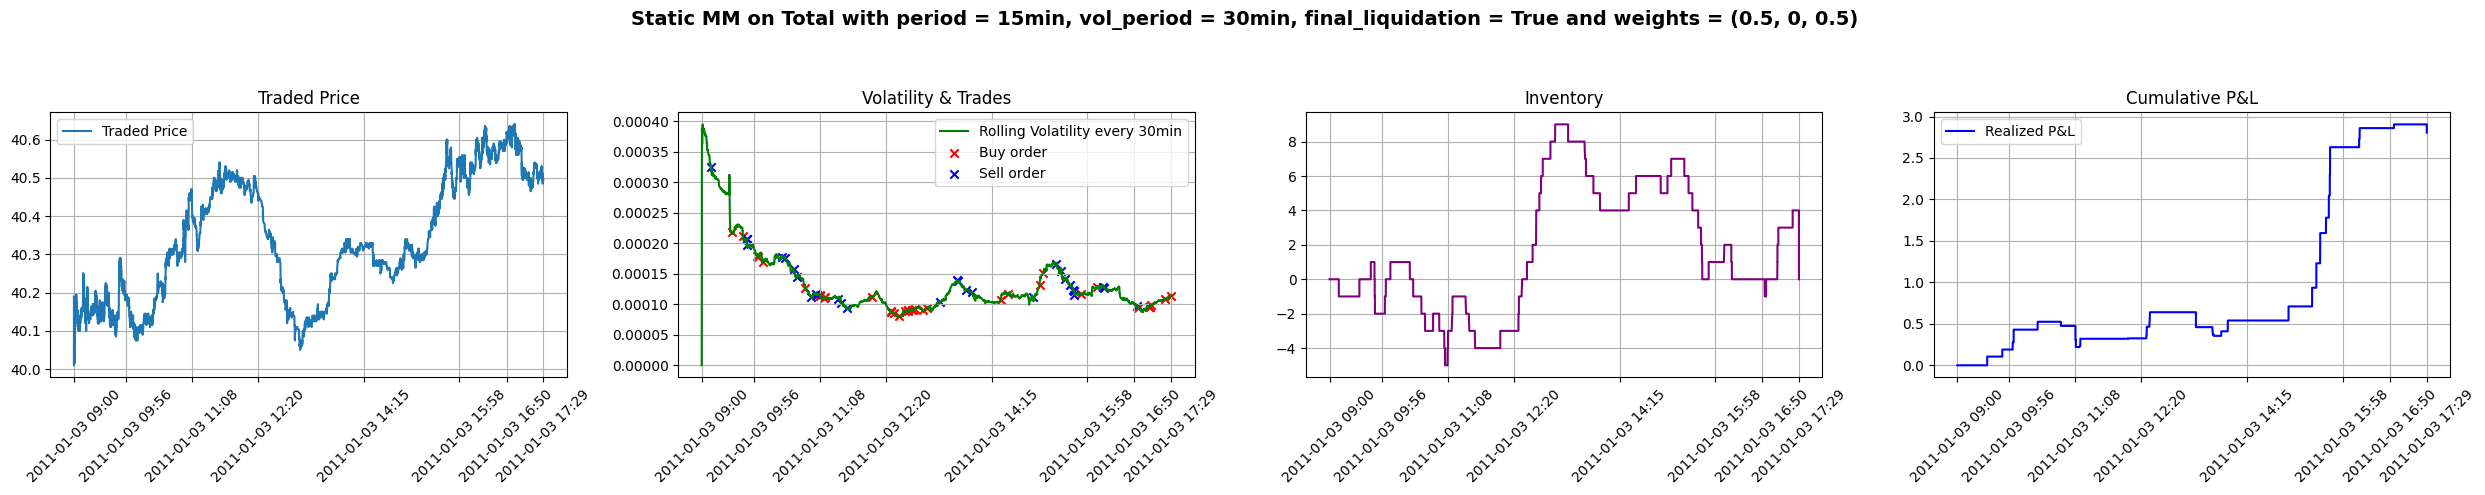


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 15min, vol_period = 30min, final_liquidation = True and weights = (0.5, 0, 0.5) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Total dynamic MM,0.005,1.64,3.57,,,12.76,0.00,0.00,,26.21,26.62,51,-4,11.76%
1,Total static MM,0.005,,,- 6 ticks,+ 8 ticks,2.81,0.00,0.00,,1.62,3.03,9,-4,20.59%


In [20]:
compute_strategies (['Total'],[total],start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0.), plot=True)
compute_strategies (['Total'],[total],start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0,0.5), plot=True)

### Comments:

In the pure PnL case, the strategy has almost pure directional exposure and is setting ask prices such that they are almost never executed, and only build up a bigger long position. This reveals a tendency to select based on price trends, which is unrealistic in practice.

Here, in the balanced weights case, the static MM strategy offers an inventory profile with stronger mean revertion than the dynamic case.

We observe that the inventory curves in the pure PnL and balanced weights scenarios converge towards a same curve for the static and dynamic strategies up to scaling.

Tick Grid Eval LVMH: 100%|███████████████████████████████████████████████████████████| 121/121 [00:44<00:00,  2.71it/s]


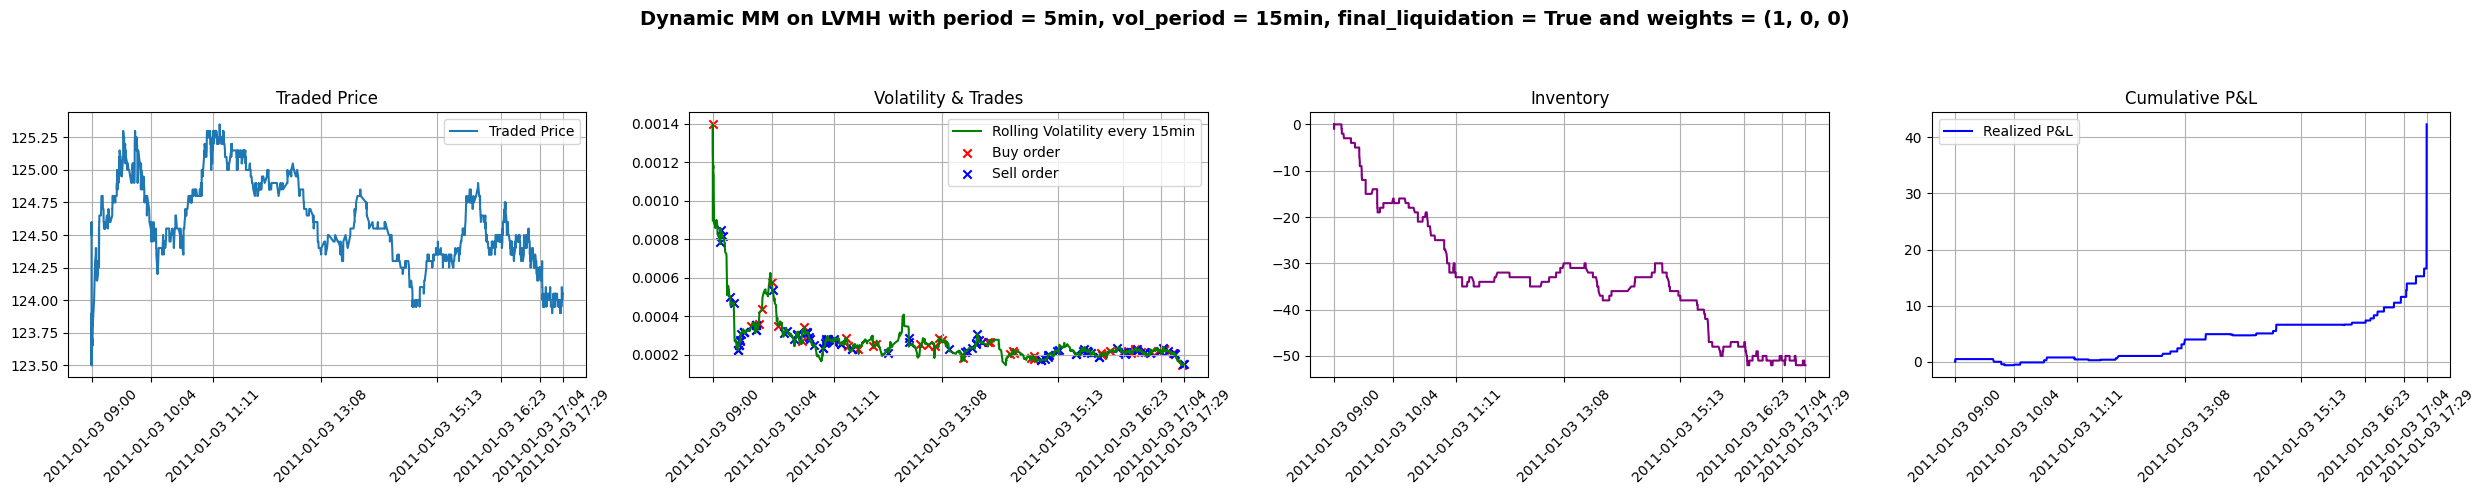

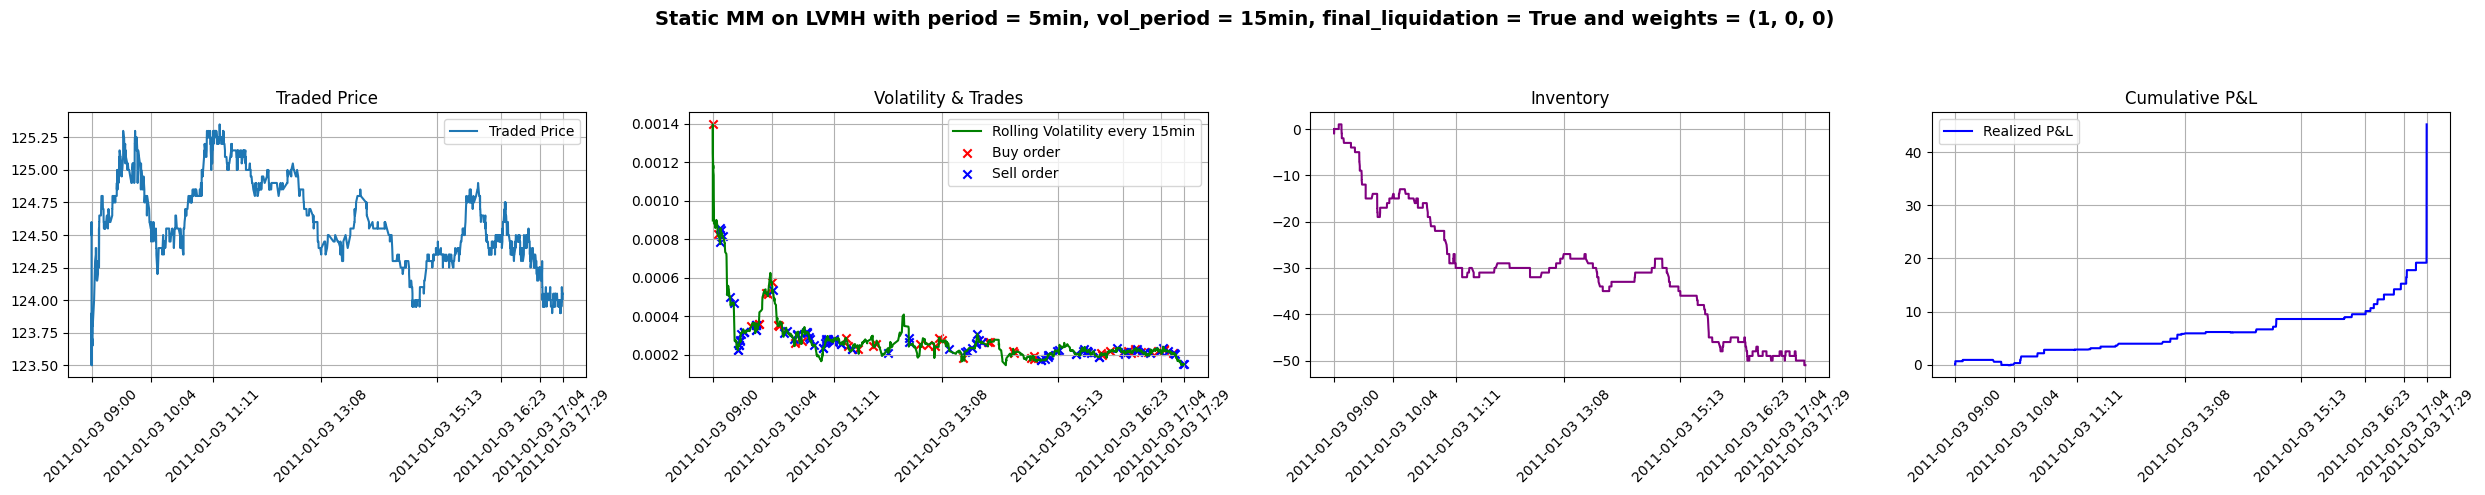


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 5min, vol_period = 15min, final_liquidation = True and weights = (1, 0, 0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,LVMH dynamic MM,0.010,8.71,2.29,,,42.30,0.00,0.00,,-32.46,32.46,0,-52,1.98%
1,LVMH static MM,0.010,,,- 10 ticks,+ 5 ticks,45.25,0.00,0.00,,-30.18,30.18,0,-50,1.98%


Tick Grid Eval LVMH: 100%|███████████████████████████████████████████████████████████| 121/121 [00:49<00:00,  2.47it/s]


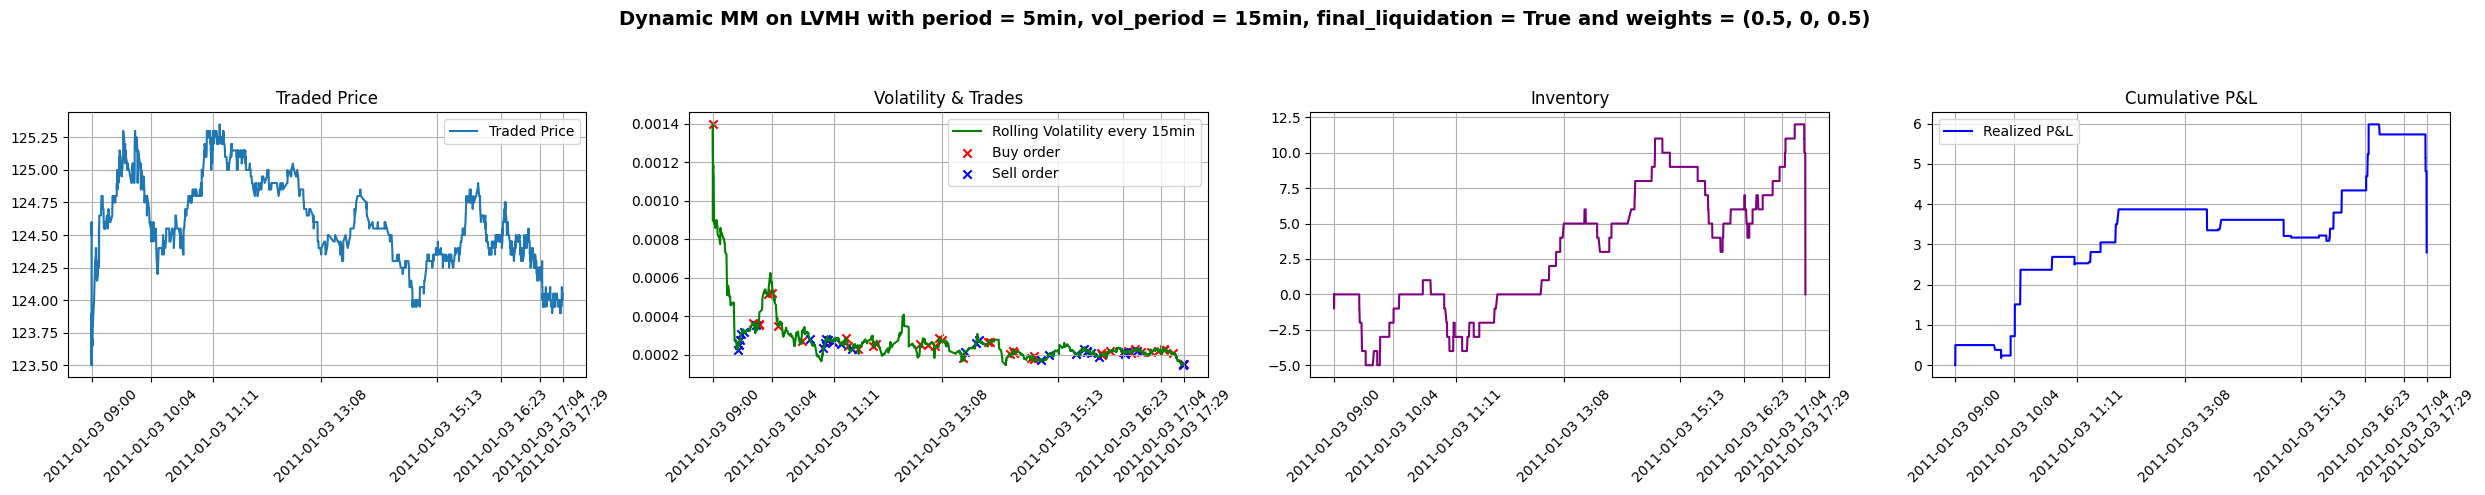

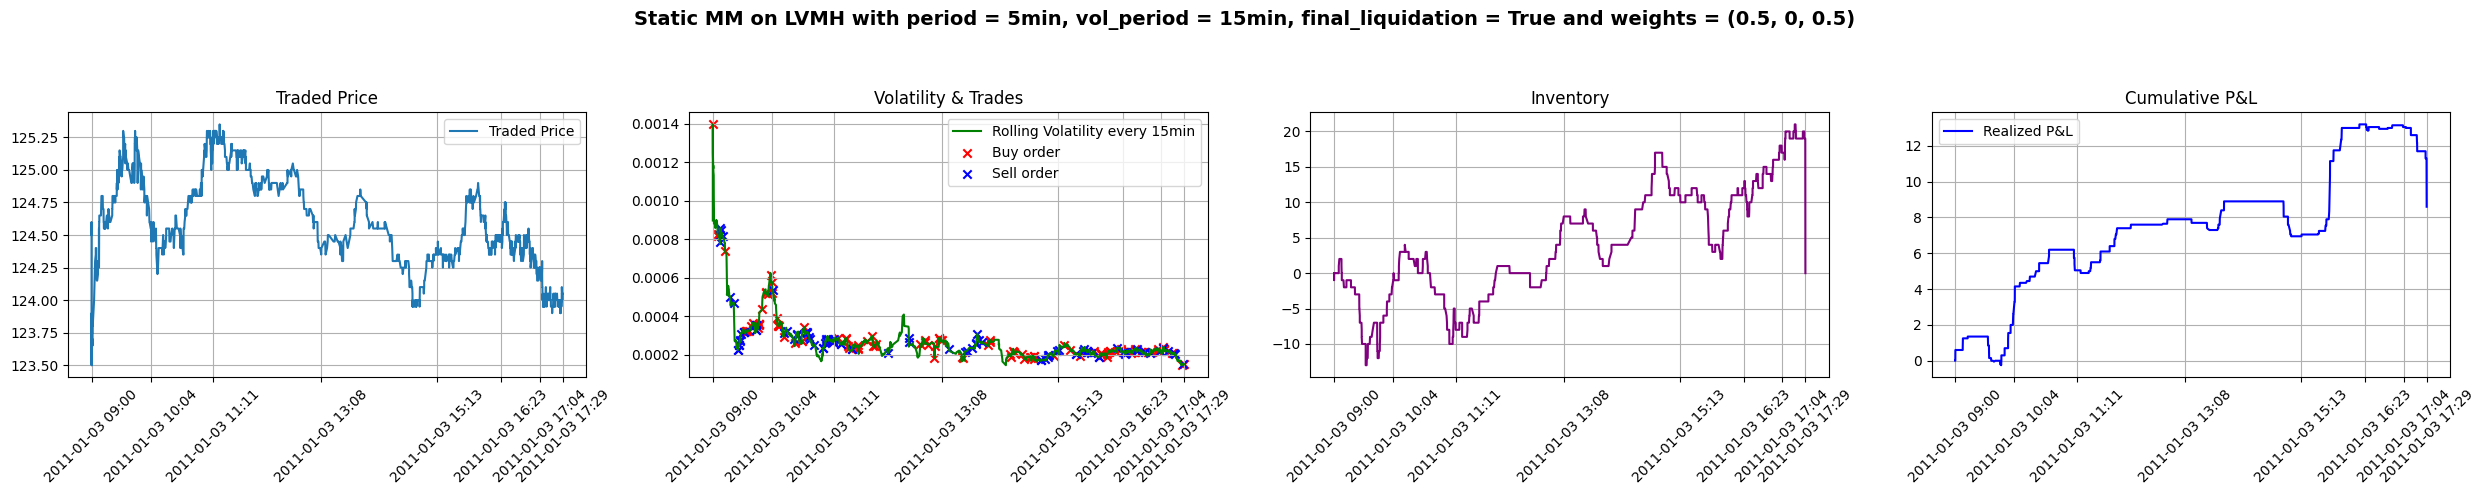


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 5min, vol_period = 15min, final_liquidation = True and weights = (0.5, 0, 0.5) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,LVMH dynamic MM,0.010,10.00,10.00,,,2.80,0.00,0.00,,3.10,4.21,12,-5,21.78%
1,LVMH static MM,0.010,,,- 5 ticks,+ 5 ticks,8.60,0.00,0.00,,3.98,6.79,20,-13,8.91%


In [21]:
compute_strategies (['LVMH'],[lvmh],start_date,end_date,"5min","15min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0), plot=True)
compute_strategies (['LVMH'],[lvmh],start_date,end_date,"5min","15min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0,0.5), plot=True)

### Comments:

In the pure PnL case, the strategy has almost pure directional exposure and is setting bid prices such that they are almost never executed. This reveals a tendency to select based on price trends, which is unrealistic in practice.

Although the PnL in the balanced weights case is lower than the pure PnL scenario, we start observing an inventory curve closer to our expectations with strong mean revertion around zero to limit the accumulation of directional exposure.

We observe again that the inventory curves in the pure PnL and balanced weights scenarios converge towards a same curve for the static and dynamic strategies up to a constant factor.

Tick Grid Eval Bouygues: 100%|███████████████████████████████████████████████████████| 121/121 [01:49<00:00,  1.10it/s]


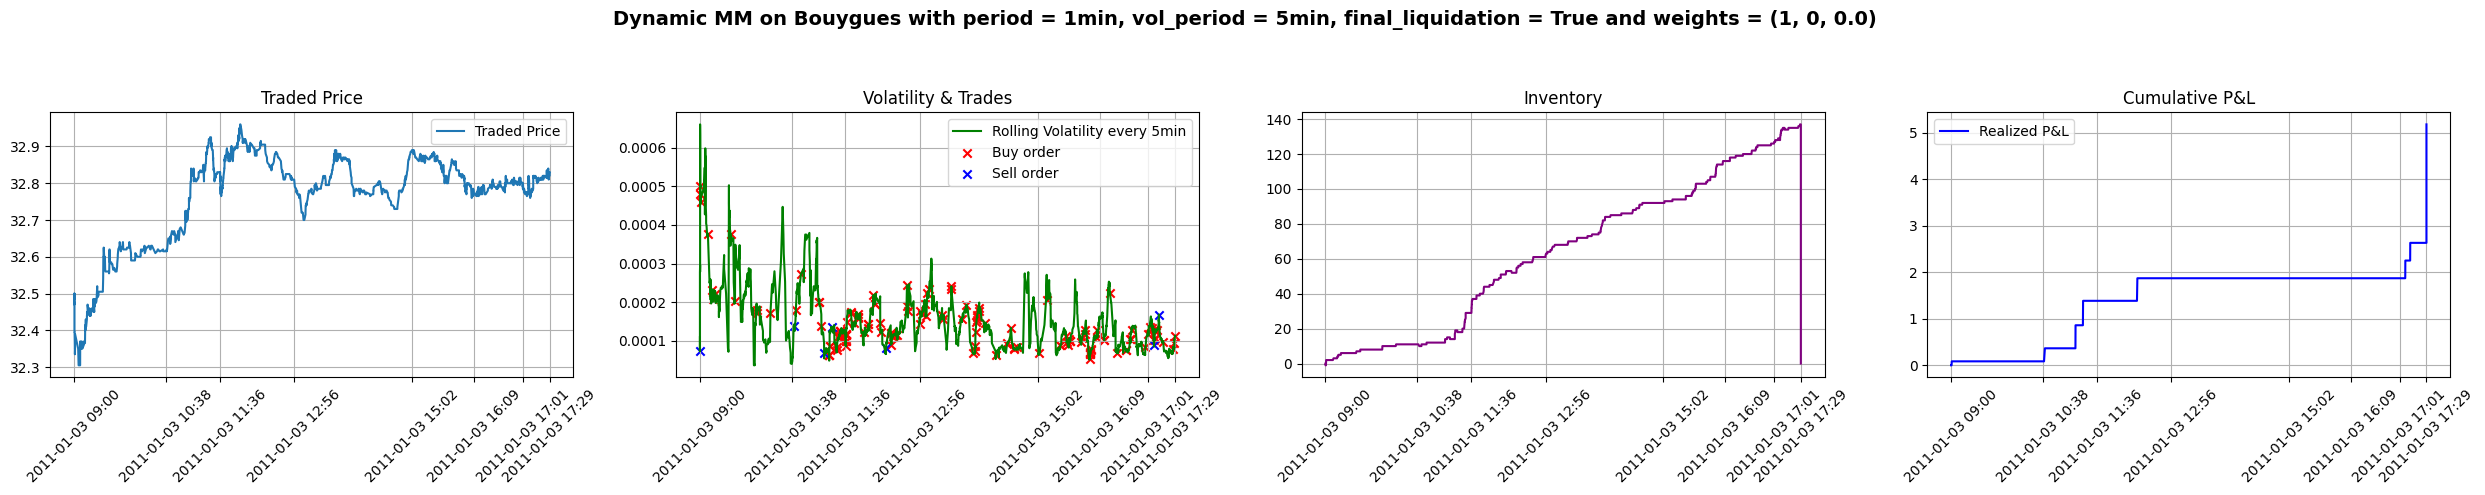

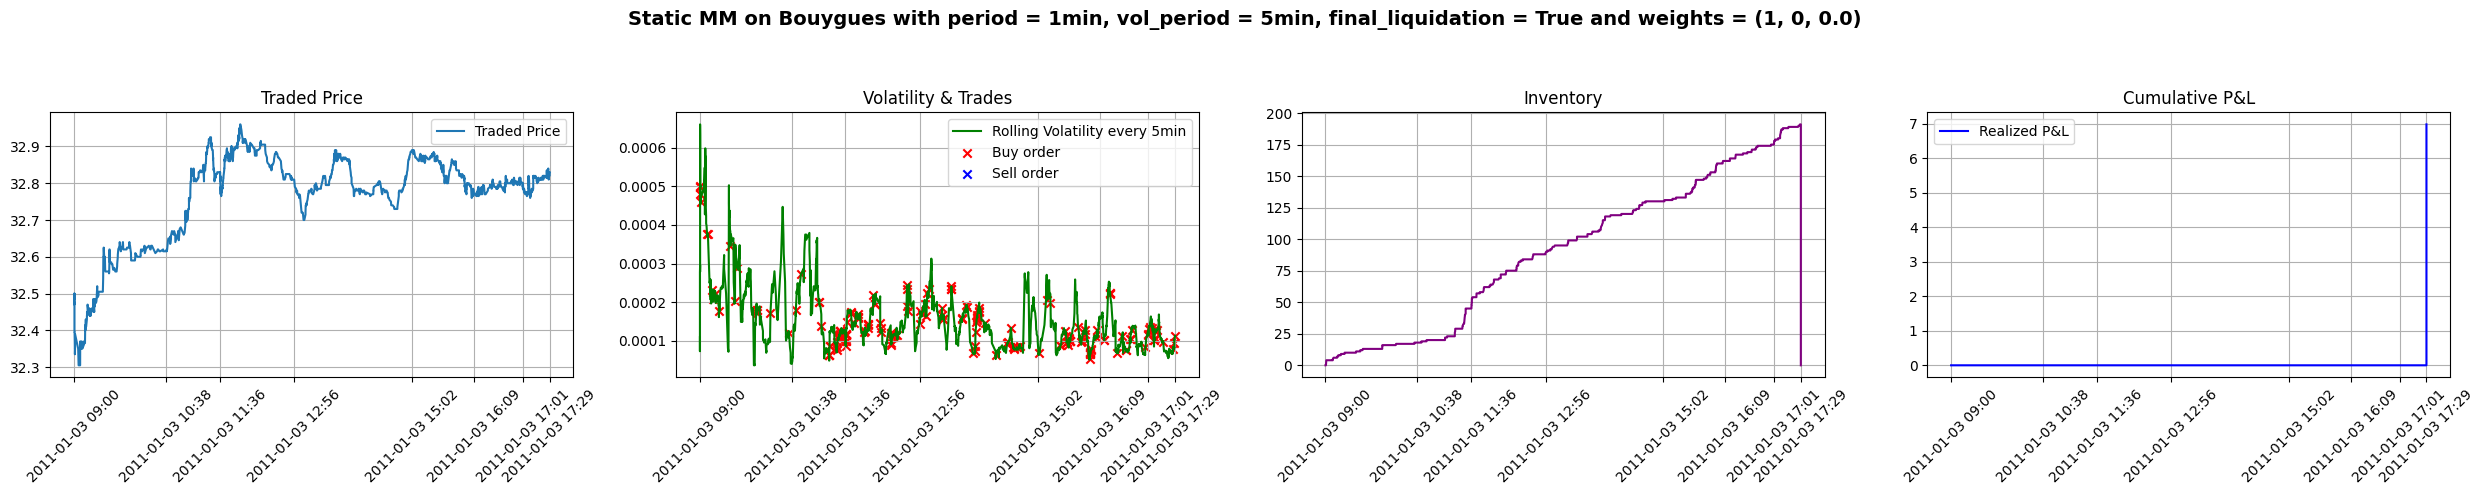


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 1min, vol_period = 5min, final_liquidation = True and weights = (1, 0, 0.0) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Bouygues dynamic MM,0.005,1.00,8.07,,,5.18,0.00,0.00,,64.77,64.77,136,0,0.23%
1,Bouygues static MM,0.005,,,- 0 ticks,+ 10 ticks,6.98,0.00,0.00,,92.00,92.00,190,0,0.23%


Tick Grid Eval Bouygues: 100%|███████████████████████████████████████████████████████| 121/121 [01:27<00:00,  1.39it/s]


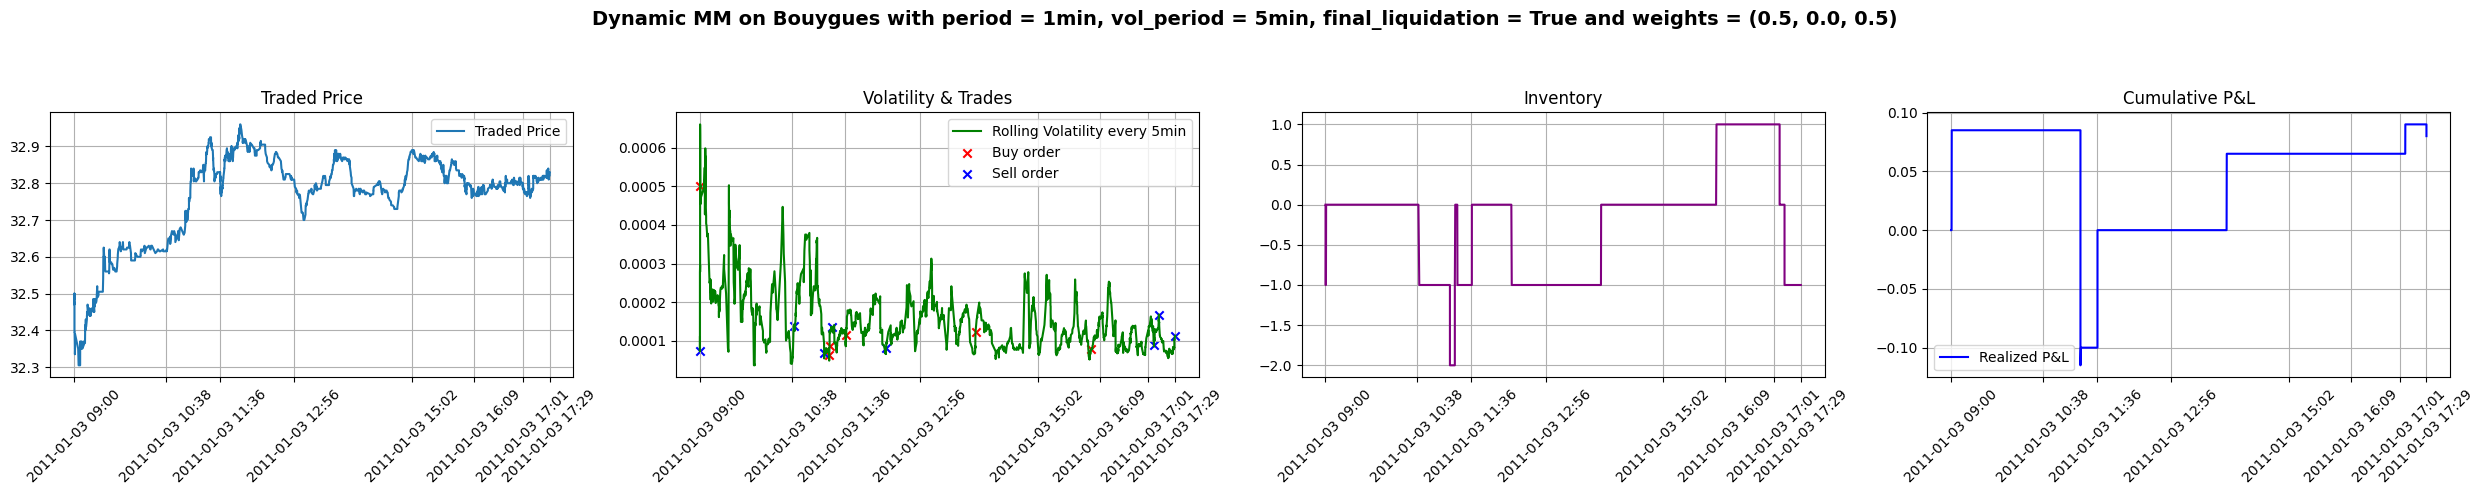

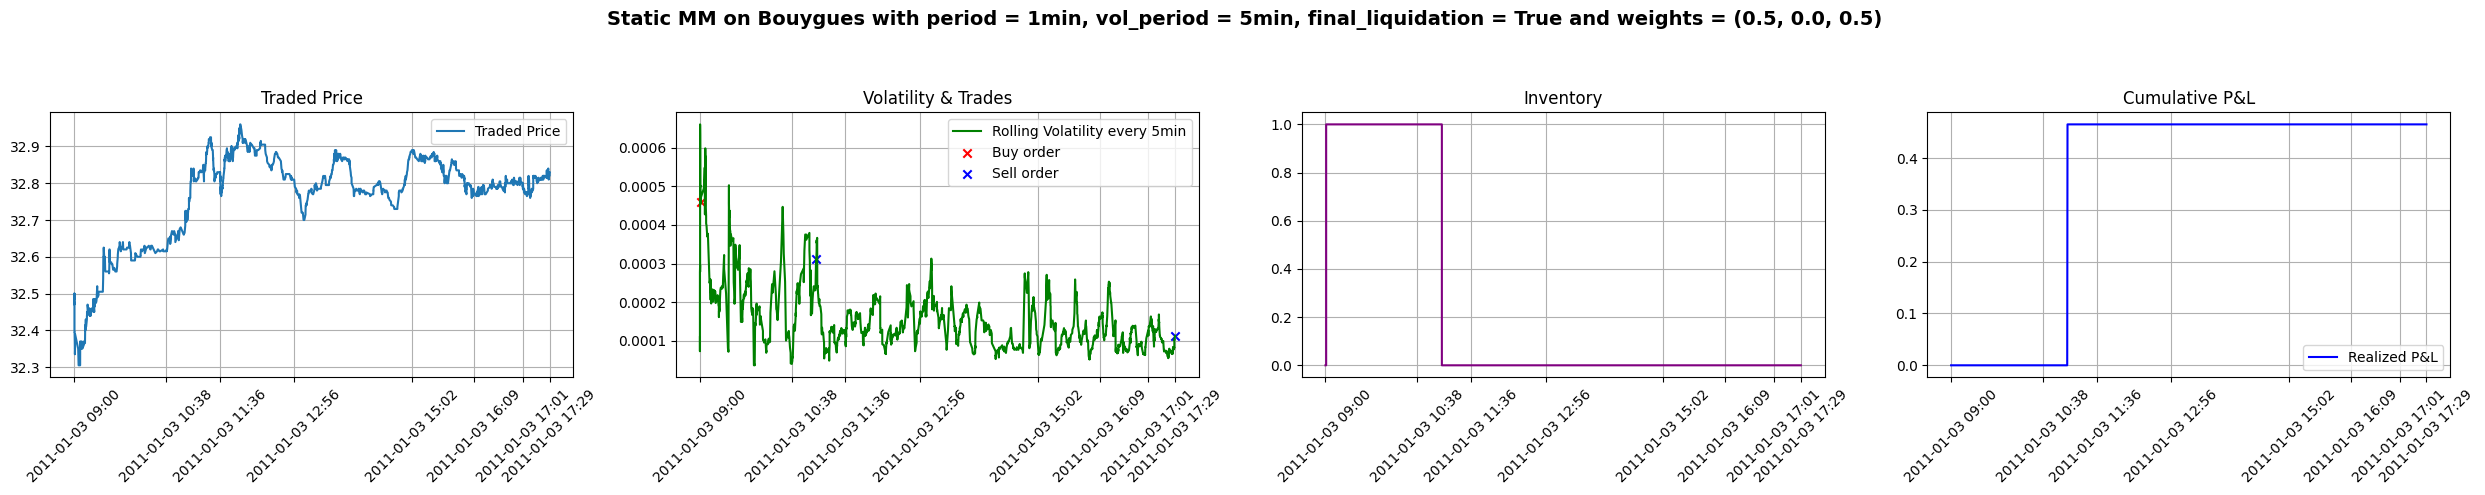


--- Comparaison vol_assessed and static MM strategy with V0 = 0, period = 1min, vol_period = 5min, final_liquidation = True and weights = (0.5, 0.0, 0.5) ---



,Security,Tick value,cb_opti,ca_opti,TickBid Opti,TickAsk Opti,P&L,End Inv,MtM End Inv,Unrealized P&L,Average Inv,Average Absolute Inv,Max Inv Eop,Min Inv Eop,% Eop with Null Inv
0,Bouygues dynamic MM,0.005,10.00,8.07,,,0.08,0.00,0.00,,-0.20,0.48,1,-2,53.21%
1,Bouygues static MM,0.005,,,- 10 ticks,+ 9 ticks,0.46,0.00,0.00,,0.23,0.23,1,0,77.06%


In [24]:
compute_strategies (['Bouygues'],[bouygues],start_date,end_date,"1min","5min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(1,0,0.), plot=True)
compute_strategies (['Bouygues'],[bouygues],start_date,end_date,"1min","5min",V0=0,liquidation_at_the_end=True, what_to_evaluate="Both", nb_points = (15,11),search_vol = 10, weights=(0.5,0.,0.5), plot=True)

### Comments:

This final security is looked at for the 1 minute period where we end up with an optimal order placement for the static and dynamic strategies exhibiting a similar intended behaviour: with a $(c_{b}, c_{a})$ of $(10, 8)$ in the balanced case and of $(1, 8)$ in the pure PnL case, it is avoiding to at all in the first scenario while the pure PnL case tries to avoid getting executed on a sell order. Meanwhile, the optimal ticks in the static strategy tell the same exact story for optimal order placement.

We observe again that the inventory curves in the pure PnL and balanced weights scenarios converge towards a same curve for the static and dynamic strategies up to a constant factor, with a closer correspondance in the pure PnL case with the directional exposure and the lack of positioning in both cases for the balanced scenario.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">4.3 Hypothesis about the liquidation hypothesis </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Assuming that end-of-day inventory is liquidated at the last trade price is a simplifying assumption that raises several realism issues in a market-making context. In practice, this assumption implies perfect liquidity at the close, which is rarely the case—especially for less liquid stocks or at the end of the trading session when spreads widen and volumes shrink.

It completely ignores market impact: liquidating a significant position cannot be done instantly at the last price without causing the price to move against the trader. In reality, a quick liquidation would induce significant slippage, particularly if the position is large relative to the depth of the order book.

Furthermore, this assumption masks the true risk associated with directional exposure. A market maker should not be speculating on price direction, but rather aim to stay neutral or minimize residual exposure at the end of the day. By assuming costless and immediate liquidation, the inventory risk is artificially underestimated, encouraging strategies that benefit from price trends rather than those that leverage market microstructure.

In short, this assumption distorts strategy evaluation by presenting an overly optimistic view of performance, while reducing the relevance of risk allocation decisions in a realistic operational framework.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">4.4 PnL & Inventory </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

We plot the evolution of the realized P&L against the inventory observed at each executed order timestamp. Each point represents the current inventory and the cumulative P&L at a given moment in time during the trading session. A linear regression is added to visualize any trend or dependency. 

In [5]:
def get_list_data_for_regression(name_list,data_list,start_date,end_date,period,period_vol,V0,liquidation_at_the_end, what_to_evaluate,nb_points,search_vol, weights, plot=False, give_data=True): 

    """
    Prepares the PnL and inventory time series for multiple assets to be used in a regression analysis.

    Parameters
    ----------
    name_list: list
               List of asset names.
    data_list: list
               Corresponding list of historical data DataFrames.
    start_date: datetime
                Start date for analysis.
    end_date: datetime
              End date for analysis.
    period: str
            Resampling period for prices.
    period_vol: str
                Period to compute volatility.
    V0: int
        Initial inventory.
    liquidation_at_the_end: bool
                            Whether to liquidate the inventory at the final price.
    what_to_evaluate: str
                      Which strategy to evaluate.
    nb_points: int
               Number of interpolation points.
    search_vol: bool
                Whether to dynamically search optimal volatility.
    weights: dict
             Dictionary of weight parameters for the strategy.
    plot: bool, optional
          Whether to plot during strategy computation.
    give_data: bool, optional
               Whether to return raw data.

    Returns
    -------
    values: dict
        Dictionary mapping asset names to (PnL series, inventory series).
    period: str
        Resampling period used.
    period_vol: str
        Volatility period used.
    strat_type: str
        Strategy type used.
    liquidation_at_the_end: bool
        Confirmation of liquidation mode.
    """
    
    values = {}
    for name, data_bis in zip(name_list, data_list): 

         # Compute strategy outputs for one asset
        (df,period, period_vol, inv, price_queue_bid,price_queue_ask, name, strat_type,weights,liquidation_at_the_end) = compute_strategies ([name],[data_bis],start_date,end_date,period,period_vol,V0,liquidation_at_the_end, what_to_evaluate,nb_points,search_vol, weights, plot=False, give_data=True) 

        # Aggregate buy and sell orders sorted by timestamp
        total_queue = sorted(list(price_queue_bid) + list(price_queue_ask), key=lambda x: x[1]) 
        
        last_prices = deque() # Stores unmatched buy/sell orders
        pnl_values = [] # PnL time series
        timestamps = [] # Associated timestamps
        PnL=0
        inv = V0
        inv_values = [] # Inventory evolution

        # Process each matched/unmatched trade
        for price, ts in total_queue:
            if price > 0 : # Buy
                if last_prices and last_prices[0] < 0 : # Match against a pending sell 
                    entry_price = - last_prices.popleft()
                    PnL+= entry_price - price
                else : 
                    last_prices.append(price)
                inv+=1
            else : 
                 if last_prices and last_prices[0] > 0: # Match against pending buy
                    entry_price = last_prices.popleft()
                    PnL += -price - entry_price
                 else:
                    last_prices.append(price)
                 inv-=1
            timestamps.append(ts)
            pnl_values.append(PnL)
            inv_values.append(inv)

        # Compute latent PnL if liquidation is needed
        latent_PnL = 0 
        final_price = df['TradedPrice'].iloc[-1]
        for price in last_prices:
            if price > 0:
                # On vend au dernier prix
                latent_PnL += final_price - price # Selling remaining buys
            else:
                # On rachète au dernier prix
                latent_PnL += -price - final_price # Buying back remaining sells
    
        # Adjust final realized PnL
        if liquidation_at_the_end : 
            pnl_series.iloc[-1] +=latent_PnL

        values[name] = (pnl_values, inv_values)
    return values, period,period_vol, strat_type, liquidation_at_the_end

def plot_pnl_vs_inventory_with_details(name_list, data_list, start_date, end_date, period, 
                                      period_vol, V0, liquidation_at_the_end, 
                                      what_to_evaluate, nb_points, search_vol, weights, 
                                      plot=False, give_data=True):
    """
    Plots PnL versus inventory scatter plots along with best-fit regression lines for different assets.

    Parameters
    ----------
    Same as for get_list_data_for_regression.

    Returns
    -------
    values: dict
            Dictionary mapping asset names to (PnL series, inventory series).
    period: str
            Resampling period used.
    period_vol: str
                Volatility period used.
    strat_type: str
                Strategy type.
    liquidation_at_the_end: bool
                            Whether liquidation was applied at final price.
    """
    
    # Get PnL and inventory time series
    values, period, period_vol, strat_type, liquidation = get_list_data_for_regression(
        name_list, data_list, start_date, end_date, period, period_vol, V0,
        liquidation_at_the_end, what_to_evaluate, nb_points, search_vol, weights,
        plot=plot, give_data=give_data
    )
    
    # Determine layout
    num_plots = len(values)
    num_rows = (num_plots + 2) // 3  # 3 columns per row layout
    
    # Create figure with appropriate size
    fig, axes = plt.subplots(num_rows, 3, figsize=(18, 5*num_rows))
    if num_plots == 1:  # Handle single plot case
        axes = np.array([[axes]]) # Force 2D array if single plot
    elif num_rows == 1:  # Handle single row case
        axes = axes.reshape(1, -1)
    
    # Flatten axes array for easy iteration
    axes_flat = axes.flatten()
    
    # Add liquidation status to title
    liquidation_status = "with liquidation at end" if liquidation else "without liquidation at end"

    # Loop through each asset and plot PnL vs Inventory
    for idx, (key, (i, p)) in enumerate(values.items()):
        ax = axes_flat[idx]
        
        # Scatter plot
        ax.scatter(i, p, alpha=0.5, label='Data points') # Scatter plot of (inventory, PnL)
        
        # Calculate and plot best-fit line
        if len(i) > 1:  # Need at least 2 points for regression
            coeffs = np.polyfit(i, p, 1)
            best_fit = np.poly1d(coeffs)
            x_range = np.linspace(min(i), max(i), 100)
            ax.plot(x_range, best_fit(x_range), 'r-', label='Best fit line')
        
        # Enhanced title with all parameters
        title = (f"{strat_type} - {key}\n"
                f"Period: {period}, Vol period: {period_vol}\n"
                f"{liquidation_status}\n"
                f"weights = {weights}")
        
        ax.set_title(title)
        ax.set_xlabel("Inventory")
        ax.set_ylabel("PnL")
        ax.legend()
        ax.grid(True)
    
    # Hide any unused axes
    for j in range(num_plots, len(axes_flat)):
        axes_flat[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return values, period, period_vol, strat_type, liquidation

Tick Grid Eval Sanofi: 100%|█████████████████████████████████████████████████████████| 121/121 [01:27<00:00,  1.38it/s]


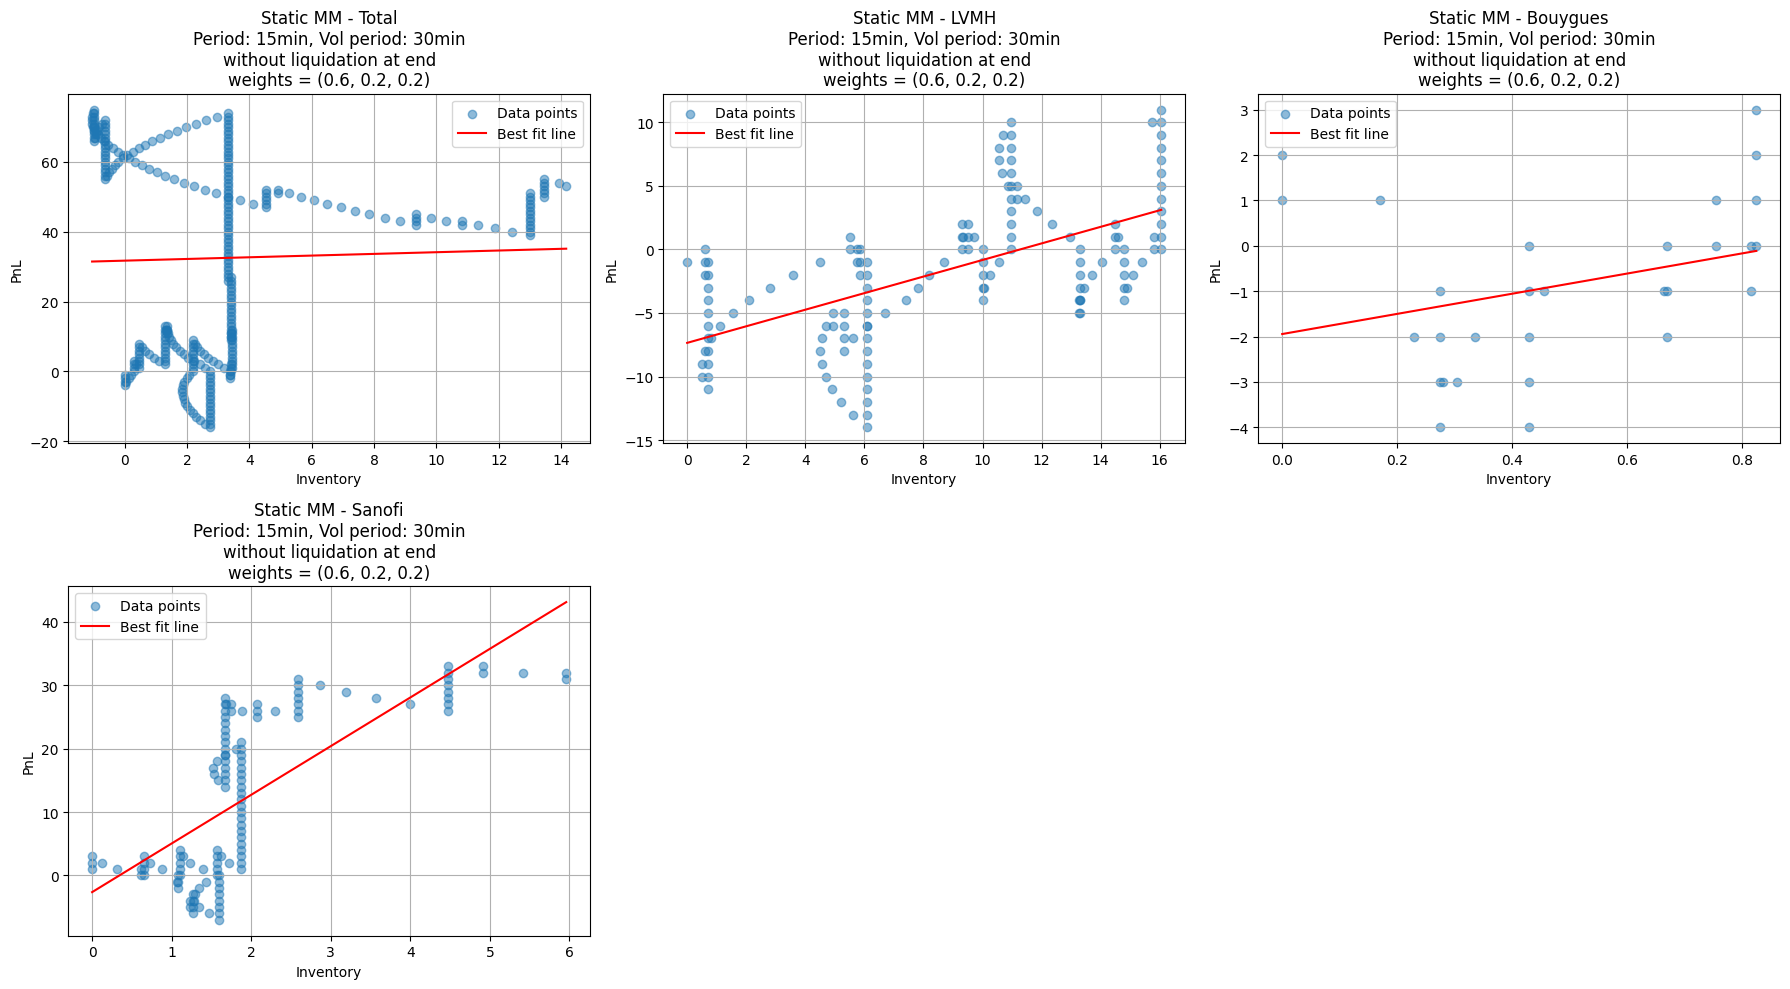

Tick Grid Eval Apple: 100%|██████████████████████████████████████████████████████████| 121/121 [05:33<00:00,  2.76s/it]


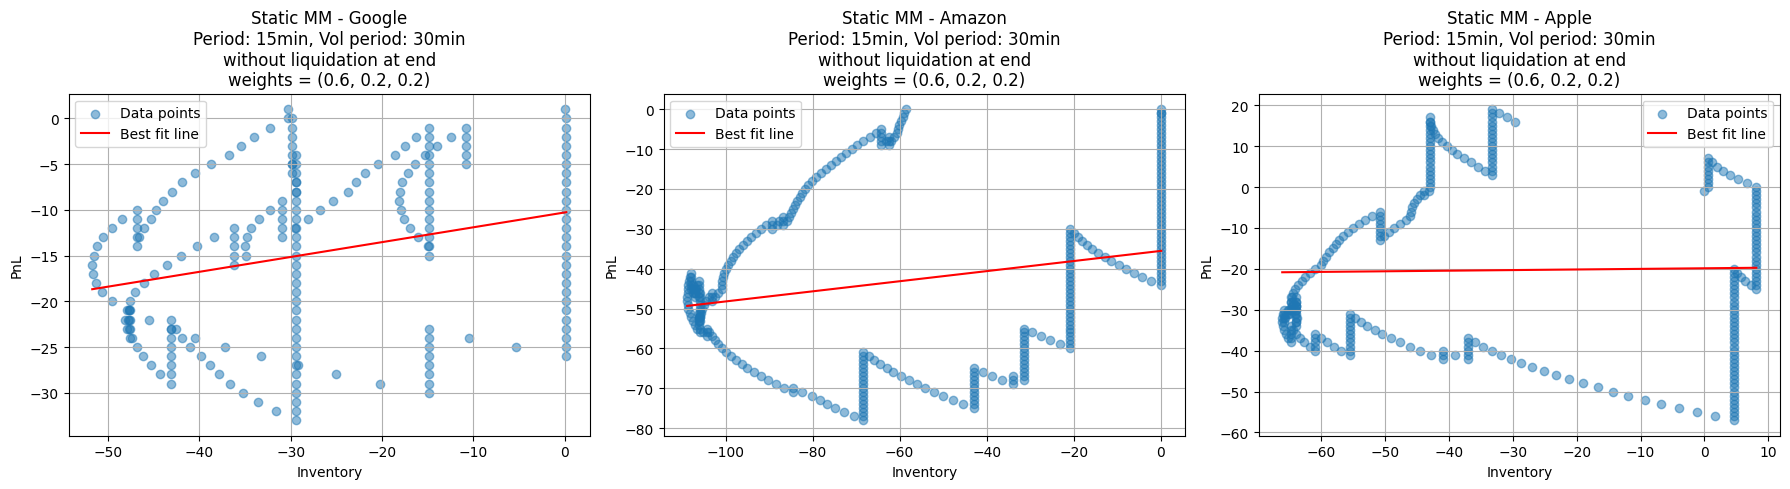

Vol Assessed Grid Eval Sanofi: 100%|█████████████████████████████████████████████████| 121/121 [01:50<00:00,  1.09it/s]


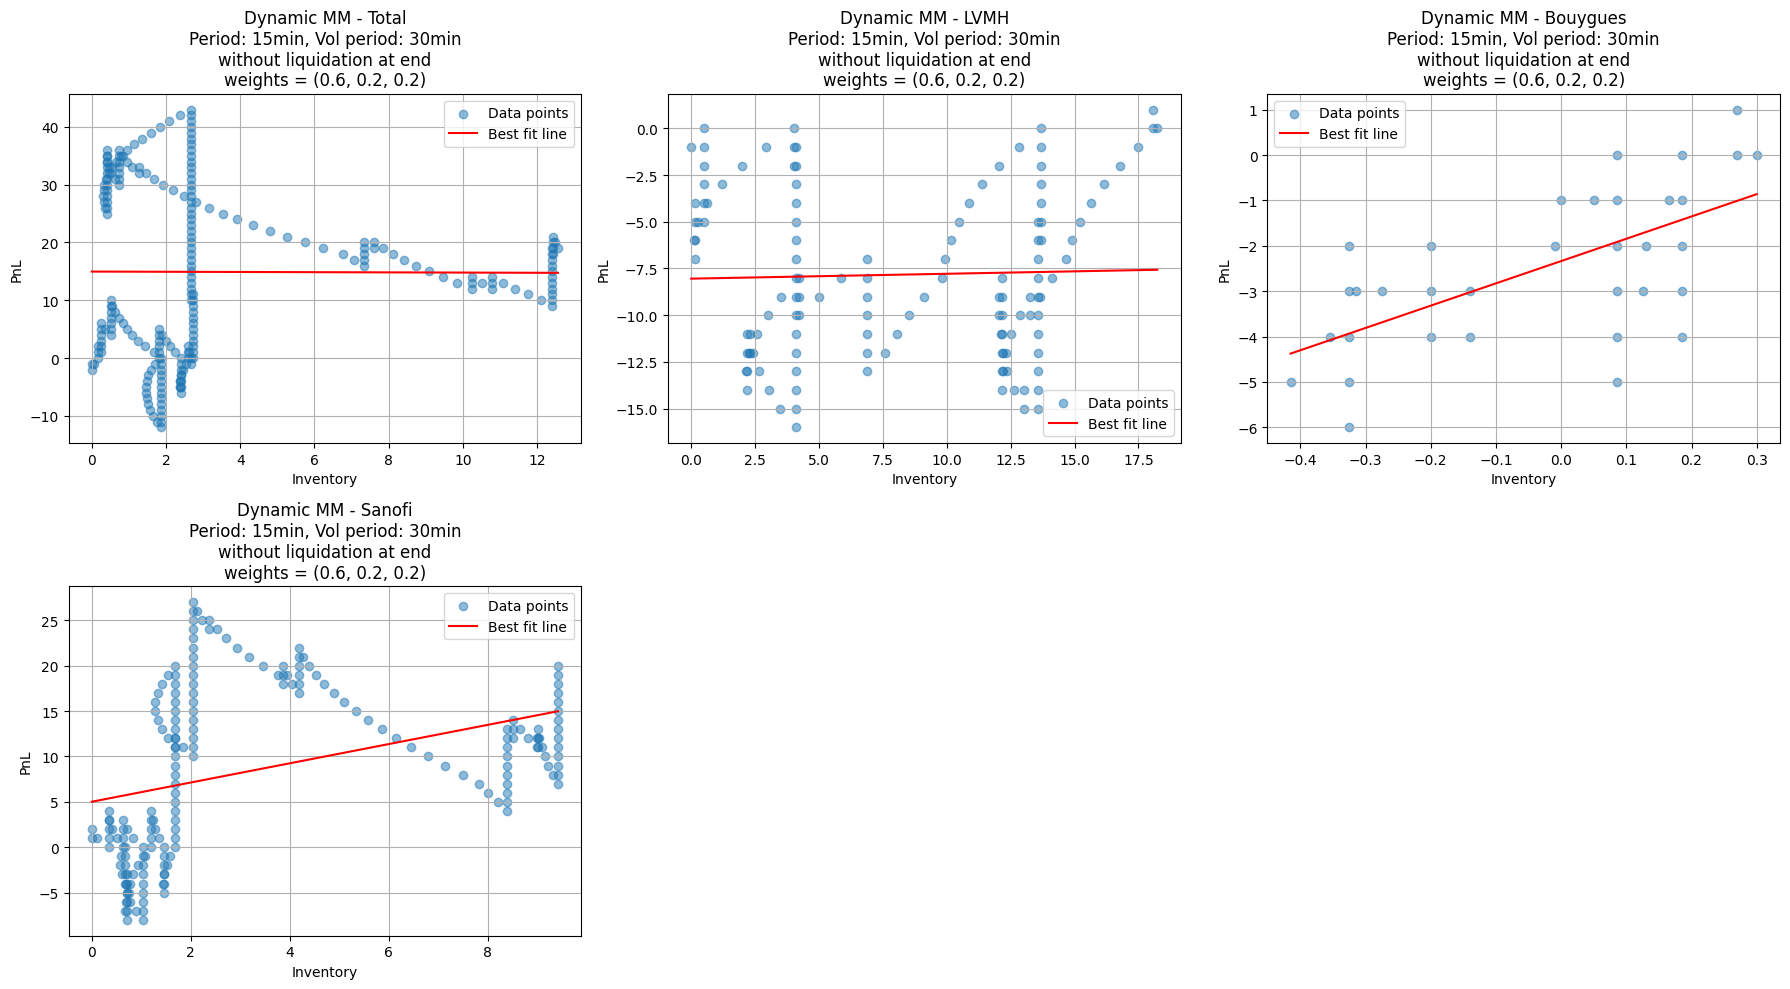

Vol Assessed Grid Eval Apple: 100%|██████████████████████████████████████████████████| 121/121 [04:52<00:00,  2.42s/it]


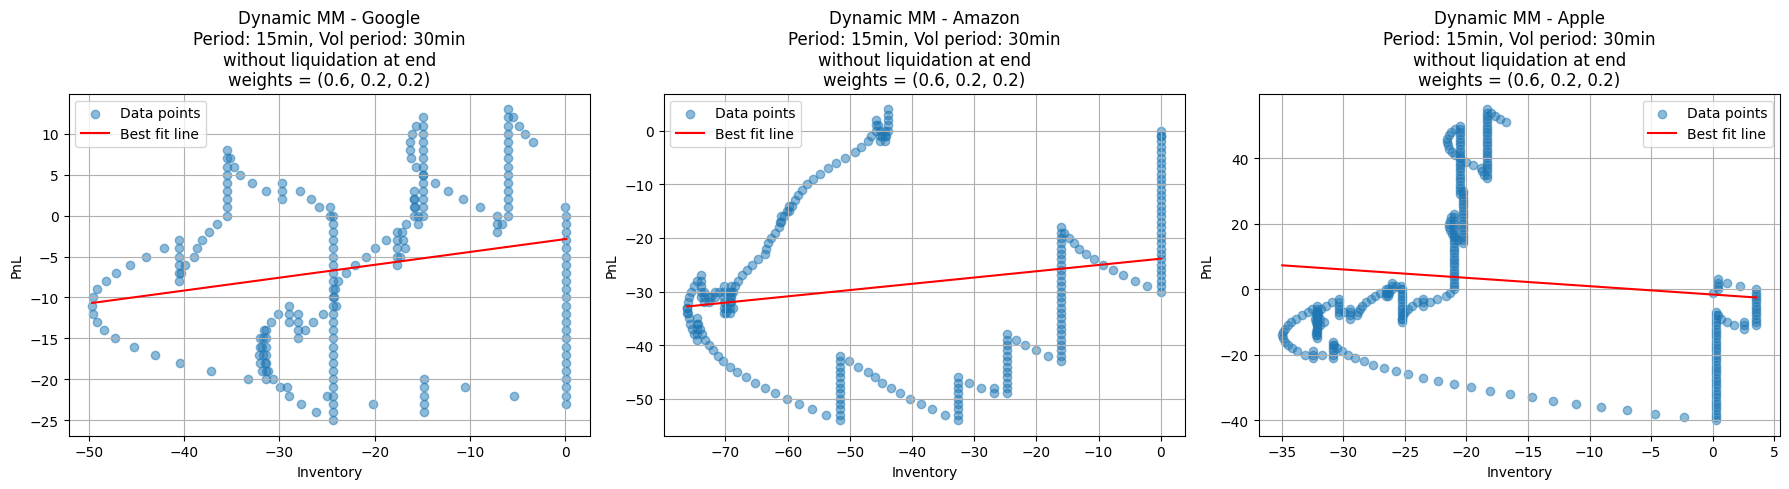

In [7]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(hours=8, minutes=30)

values, period, period_vol, strat_type, liquidation = plot_pnl_vs_inventory_with_details(list_FR_name , list_FR ,start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Static_MM", nb_points = (1,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False, give_data=True)
values, period, period_vol, strat_type, liquidation = plot_pnl_vs_inventory_with_details(list_US_name , list_US ,start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Static_MM", nb_points = (1,11),search_vol = 10, weights=(0.6,0.2,0.2), plot=False, give_data=True)
values, period, period_vol, strat_type, liquidation = plot_pnl_vs_inventory_with_details(list_FR_name , list_FR ,start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (11,1),search_vol = 10, weights=(0.6,0.2,0.2), plot=False, give_data=True)
values, period, period_vol, strat_type, liquidation = plot_pnl_vs_inventory_with_details(list_US_name , list_US ,start_date,end_date,"15min","30min",V0=0,liquidation_at_the_end=False, what_to_evaluate="Vol_assessed", nb_points = (11,1),search_vol = 10, weights=(0.6,0.2,0.2), plot=False, give_data=True)

**Comments:**


We plot the realized PnL as a function of the live inventory observed at each execution timestamp, with a linear regression fit overlaid. This aims to evaluate whether the inventory path has any direct explanatory power over the profit evolution throughout the session. Importantly, this analysis is performed without end-of-period liquidation, so any residual inventory remains unadjusted and may bias the outcome.

The scatter plots reveal no robust linear relationship between inventory and PnL. In most cases, the regression line is nearly flat, and the dispersion of points is high, with no coherent trend. Large variations in PnL appear even at constant inventory levels, suggesting that other variables—such as local volatility, execution timing, or market drift—play a much more dominant role. This is consistent with what is expected in a passive quoting framework where quotes are fixed and not actively steered based on position.

Dynamic strategies show slightly more structure, with inventory sometimes drifting in alignment with PnL. However, this apparent correlation often reflects latent directional exposure, rather than a genuine causal link between inventory and profitability. In these cases, high inventory coincides with favorable market moves, but the strategy itself is not designed to capture them deliberately.

Overall, linear regression appears ill-suited to capture the true dynamics at play. The relationship between inventory and PnL, if it exists, is likely nonlinear, time-dependent, and mediated by other latent variables. To better characterize this link, one would need to consider higher-order features such as inventory momentum, holding duration, or inventory-volatility interactions. In the current setting, inventory alone remains a poor predictor of performance.

**Question: Study the dependence of the P&L to the inventory. If the posting distance depends on both inventory and volatility $d_t=f(V_t,\sigma_t)$, what could be the shape of $f$ to optimize the closing P&L ?**

The closing P&L of a market making strategy depends not only on the spread captured through passive orders but also on the ability to manage and reduce risk related to inventory exposure. In this context, if the posting distance $d_t$ is made to depend on both the current inventory $V_t$ and the market volatility $\sigma_t$, the functional form of $f(V_t, \sigma_t)$ must be designed to dynamically balance trade execution aggressiveness and risk control throughout the session.

Intuitively, inventory $V_t$ plays a central role in the risk profile of the strategy. When the absolute inventory $|V_t|$ is large, the agent is exposed to potentially adverse price moves. In such cases, to reduce this risk and converge toward a neutral position, the market maker should quote more aggressively — i.e., reduce the posting distance — to increase the likelihood of being executed. Hence, the posting distance should decrease with $|V_t|$.

Volatility $\sigma_t$ reflects the speed and amplitude of price changes. In high-volatility environments, the risk of holding inventory increases, and the spread becomes more unstable. Just like with large inventories, the strategy should react by quoting more aggressively, again favoring a decrease of $d_t$ with $\sigma_t$. However, unlike inventory, volatility also presents an opportunity: a wider spread during high-volatility periods might allow the market maker to capture more profit per trade — suggesting that the relationship might not be purely monotonic.

To capture this dual behavior — risk mitigation and profit opportunity — a simple yet flexible form for $f$ can be proposed:

$d_t = \frac{k}{1 + \alpha |V_t| + \beta \sigma_t}$

where:

$k$ is a maximum posting distance (e.g. in ticks),

$\alpha > 0$ reflects the sensitivity to inventory,

$\beta > 0$ reflects the sensitivity to volatility.

This formulation ensures that:

When both inventory and volatility are low, the posting distance is large, allowing the strategy to quote far from the mid-price and aim for higher spread capture.

When inventory or volatility increases, the posting distance shrinks, pushing the quotes closer to the market and favoring faster execution to reduce exposure and limit risk.

This approach balances P&L optimization and exposure control. By adapting dynamically to current market and portfolio conditions, it prevents the accumulation of large unhedged positions while still allowing for spread capture when risk is low. It also avoids the pathological behaviors observed in P&L-only strategies, where the absence of inventory control leads to extreme and unrealistic directional positions, only liquidated fictitiously at the end.

Further refinements to $f$ could include asymmetry in the reaction to positive or negative inventory (e.g., more aggressive when holding a short position), or the introduction of nonlinear terms to accelerate execution urgency near thresholds.